## Day 1: Data Unification Pipeline
### Step 1 — Load and Inspect Battery Archive Metadata

Goal: understand what's actually in metadata.csv before writing any filters —
column names, source labels, cathode chemistry labels, and cell ID naming 
conventions across all institutions (SNL, CALCE, MIT/MATR, NASA, etc.) in 
the archive.

In [1]:
# Cell 1: Load and inspect metadata
import pandas as pd

meta = pd.read_csv('/kaggle/input/datasets/kritikabenjwal/batterydata/metadata.csv')  # update path once you've added it as input

print("Shape:", meta.shape)
print("\nColumns:")
print(meta.columns.tolist())
print("\nData types:")
print(meta.dtypes)
print("\nFirst 10 rows:")
meta.head(10)

Shape: (137, 11)

Columns:
['cell_id', 'study', 'cathode', 'anode', 'temperature', 'min_soc', 'max_soc', 'charge_crate', 'discharge_crate', 'capacity_ah', 'form_factor']

Data types:
cell_id             object
study               object
cathode             object
anode               object
temperature          int64
min_soc            float64
max_soc            float64
charge_crate       float64
discharge_crate    float64
capacity_ah        float64
form_factor         object
dtype: object

First 10 rows:


,cell_id,study,cathode,anode,temperature,min_soc,max_soc,charge_crate,discharge_crate,capacity_ah,form_factor
0,CALCE_CX2-16_prism_LCO_25C_0-100_0.5/0.5C_a,calce,LCO,graphite,25,0.0,100.0,0.5,0.5,1.35,prismatic
1,CALCE_CX2-25_prism_LCO_25C_0-100_0.5/0.5C_b,calce,LCO,graphite,25,0.0,100.0,0.5,0.5,1.35,prismatic
2,CALCE_CX2-33_prism_LCO_25C_0-100_0.5/0.5C_d,calce,LCO,graphite,25,0.0,100.0,0.5,0.5,1.35,prismatic
3,CALCE_CX2-34_prism_LCO_25C_0-100_0.5/0.5C_e,calce,LCO,graphite,25,0.0,100.0,0.5,0.5,1.35,prismatic
4,CALCE_CX2-36_prism_LCO_25C_0-100_0.5/0.5C_f,calce,LCO,graphite,25,0.0,100.0,0.5,0.5,1.35,prismatic
5,CALCE_CX2-37_prism_LCO_25C_0-100_0.5/0.5C_g,calce,LCO,graphite,25,0.0,100.0,0.5,0.5,1.35,prismatic
6,CALCE_CX2-38_prism_LCO_25C_0-100_0.5/0.5C_h,calce,LCO,graphite,25,0.0,100.0,0.5,0.5,1.35,prismatic
7,HNEI_18650_NMC_LCO_25C_0-100_0.5/1.5C_a,HNEI,NMC-LCO,graphite,25,0.0,100.0,0.5,1.5,2.80,18650
8,HNEI_18650_NMC_LCO_25C_0-100_0.5/1.5C_b,HNEI,NMC-LCO,graphite,25,0.0,100.0,0.5,1.5,2.80,18650
9,HNEI_18650_NMC_LCO_25C_0-100_0.5/1.5C_c,HNEI,NMC-LCO,graphite,25,0.0,100.0,0.5,1.5,2.80,18650


### Step 2 — See what studies/chemistries are actually available

Before filtering, get a full picture: which studies (sources), which cathode 
chemistries, and how many cells per combination. This tells us exactly what's 
available from Battery Archive so we don't filter based on a guess.

In [2]:
# Cell 2: Full breakdown of studies and chemistries
print("Unique studies:", meta['study'].unique())
print("\nUnique cathodes:", meta['cathode'].unique())
print("\nUnique form factors:", meta['form_factor'].unique())

print("\n--- Cell count by study ---")
print(meta['study'].value_counts())

print("\n--- Cell count by study + cathode ---")
print(meta.groupby(['study', 'cathode']).size())

print("\n--- Temperature range available ---")
print(meta['temperature'].unique())

Unique studies: ['calce' 'HNEI' 'oxford' 'snl' 'UL-PUR']

Unique cathodes: ['LCO' 'NMC-LCO' 'LFP' 'NCA' 'NMC']

Unique form factors: ['prismatic' '18650' 'pouch']

--- Cell count by study ---
study
snl       86
UL-PUR    21
HNEI      15
oxford     8
calce      7
Name: count, dtype: int64

--- Cell count by study + cathode ---
study   cathode
HNEI    NMC-LCO    15
UL-PUR  NCA        21
calce   LCO         7
oxford  LCO         8
snl     LFP        30
        NCA        24
        NMC        32
dtype: int64

--- Temperature range available ---
[25 40 15 35 23]


### Step 3 — Filter Battery Archive metadata to target cell list

Primary scope: all SNL cells (LFP + NCA + NMC, 86 cells) — matches our LFP 
target chemistry while keeping NCA/NMC for cross-chemistry validation later.
CALCE/HNEI/oxford/UL-PUR held back for now (chemistry mismatch, smaller 
marginal value) — can add back in Day 2-3 if time allows.

In [3]:
# Cell 3: Filter to target cell list (SNL only, for now)
snl_cells = meta[meta['study'] == 'snl'].copy()
print("SNL cell count:", len(snl_cells))
print("\nBreakdown by cathode:")
print(snl_cells['cathode'].value_counts())
print("\nBreakdown by temperature:")
print(snl_cells.groupby(['cathode', 'temperature']).size())

# Save the filtered cell_id list — this is what feeds datatransfer.py next
snl_cell_ids = snl_cells['cell_id'].tolist()
print("\nSample cell IDs:")
print(snl_cell_ids[:5])

SNL cell count: 86

Breakdown by cathode:
cathode
NMC    32
LFP    30
NCA    24
Name: count, dtype: int64

Breakdown by temperature:
cathode  temperature
LFP      15              4
         25             20
         35              6
NCA      15              4
         25             14
         35              6
NMC      15              4
         25             22
         35              6
dtype: int64

Sample cell IDs:
['SNL_18650_LFP_15C_0-100_0.5/1C_a', 'SNL_18650_LFP_15C_0-100_0.5/1C_b', 'SNL_18650_LFP_15C_0-100_0.5/2C_a', 'SNL_18650_LFP_15C_0-100_0.5/2C_b', 'SNL_18650_LFP_25C_0-100_0.5/0.5C_a']


### Step 4 — Inspect the downloaded data_transfer.py script

Since the script is already added as an input dataset, read it directly from 
disk rather than fetching over the web. Need to see the actual function 
signatures before calling it with our 86 SNL cell IDs.

In [4]:
# Cell 4: Read and inspect data_transfer.py
with open('/kaggle/input/datasets/kritikabenjwal/data-transfer-script/data_transfer.py', 'r') as f:
    script_content = f.read()

print(script_content)

#File name: data_transfer.py allow downloading data from www.batteryarchive.org
#Copyright (C) 2021 Valerio De Angelis

#Utility to download files from wwww.batteryarchive.org.
#given a metadata files in csv format, generate the links and download cycle data and time series data
#cycle data file format: http://www.batteryarchive.org/data/[data_set]/[cell_id]_cycle_data.csv
#time data file format http://www.batteryarchive.org/data/[data_set]/[cell_id]_timeseries.csv
#files are donwload to the folder that contains the csv and python file
#For questions, email info@batteryarchive.org

#This program is free software: you can redistribute it and/or modify
#it under the terms of the GNU General Public License as published by
#the Free Software Foundation, either version 3 of the License, or
#(at your option) any later version.

#This program is distributed in the hope that it will be useful,
#but WITHOUT ANY WARRANTY; without even the implied warranty of
#MERCHANTABILITY or FITNESS FOR A PAR

### Step 5 — Test download on a single cell first

Before pulling all 86 SNL cells, verify the URL pattern actually works against 
the live site with one cell. Cheap way to catch a broken URL/404 before 
looping over the full list.

In [5]:
import requests, json

token = "61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj"
base = f"https://database.batteryarchive.org/api/dashboards/public/{token}"

test_cell = "SNL_18650_LFP_15C_0-100_0.5/1C_a"
params = {"org_slug": "default", "p_cell_id": json.dumps([test_cell])}

resp = requests.get(base, params=params)
print("Status:", resp.status_code)
print(resp.text[:1000])  # inspect raw shape before assuming structure

Status: 200
{"name": "Cycle Test Data", "layout": [], "dashboard_filters_enabled": false, "updated_at": "2022-05-31T21:10:50.748Z", "created_at": "2022-05-31T19:26:04.943Z", "options": {}, "widgets": [{"id": 1, "width": 1, "options": {"parameterMappings": {"cell_id": {"name": "cell_id", "type": "dashboard-level", "mapTo": "cell_id", "value": null, "title": ""}}, "isHidden": false, "position": {"autoHeight": false, "sizeX": 3, "sizeY": 8, "minSizeX": 1, "maxSizeX": 6, "minSizeY": 5, "maxSizeY": 1000, "col": 0, "row": 0}}, "text": "", "updated_at": "2022-05-31T19:26:04.982Z", "created_at": "2022-05-31T19:26:04.982Z", "visualization": {"type": "CHART", "name": "Cycle Index Data", "description": "", "options": {"globalSeriesType": "line", "sortX": true, "legend": {"enabled": true, "placement": "auto", "traceorder": "normal"}, "xAxis": {"type": "-", "labels": {"enabled": true}, "title": {"text": "Cycle Index"}}, "yAxis": [{"type": "linear", "title": {"text": "Ah/Wh"}}, {"type": "linear", "o

In [6]:
# Cell 6: Extract query/api_key per widget, then fetch real cycle data
data = resp.json()

widgets = data.get("widgets", [])
print(f"Found {len(widgets)} widgets\n")

queries = []
for w in widgets:
    viz = w.get("visualization", {})
    q = viz.get("query", {})
    if q:
        queries.append({
            "widget_name": viz.get("name"),
            "query_id": q.get("id"),
            "api_key": q.get("api_key"),
        })
        print(viz.get("name"), "-> query_id:", q.get("id"), "api_key:", q.get("api_key"))

# Now fetch actual results for the first query, scoped to our test cell
if queries:
    q0 = queries[0]
    results_url = f"https://database.batteryarchive.org/api/queries/{q0['query_id']}/results.json"
    r_params = {
        "api_key": q0["api_key"],
        "p_cell_id": test_cell,
    }
    r2 = requests.get(results_url, params=r_params)
    print("\nResults status:", r2.status_code)
    print(r2.text[:1000])

Found 6 widgets

Cycle Index Data -> query_id: 26 api_key: None
Time Series Data -> query_id: 26 api_key: None
Chart -> query_id: 28 api_key: None
Chart -> query_id: 31 api_key: None
Chart -> query_id: 30 api_key: None
Cycle Index Data -> query_id: 40 api_key: None

Results status: 404
{"message":"Couldn't find resource. Please login and try again."}



In [7]:
# Cell 7: Inspect each widget's visualization.query object fully (not just id/api_key)
import json

for w in widgets:
    viz = w.get("visualization", {})
    q = viz.get("query", {})
    print("=== Widget:", viz.get("name"), "query_id:", q.get("id"), "===")
    print(list(q.keys()))  # see what fields are actually present
    print()

=== Widget: Cycle Index Data query_id: 26 ===
['id', 'name', 'description', 'options']

=== Widget: Time Series Data query_id: 26 ===
['id', 'name', 'description', 'options']

=== Widget: Chart query_id: 28 ===
['id', 'name', 'description', 'options']

=== Widget: Chart query_id: 31 ===
['id', 'name', 'description', 'options']

=== Widget: Chart query_id: 30 ===
['id', 'name', 'description', 'options']

=== Widget: Cycle Index Data query_id: 40 ===
['id', 'name', 'description', 'options']



In [8]:
# Cell 8: Install Playwright (Kaggle-safe) and render one cell's dashboard
!pip install playwright --quiet
!playwright install chromium --with-deps

# Cell 8: Async version (required inside Jupyter/Kaggle's running event loop)
import asyncio
from playwright.async_api import async_playwright

token = "61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj"
url = f"https://database.batteryarchive.org/public/dashboards/{token}?org_slug=default&p_cell_id={test_cell}"

captured_xhr = []

async def handle_response(response):
    if "/api/" in response.url and response.request.resource_type in ("xhr", "fetch"):
        try:
            body = await response.text()
        except Exception as e:
            body = f"<unreadable: {e}>"
        captured_xhr.append((response.url, response.status, body[:500]))

async def run():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        page.on("response", lambda r: asyncio.create_task(handle_response(r)))
        await page.goto(url, wait_until="networkidle", timeout=45000)
        await page.wait_for_timeout(4000)
        html = await page.content()
        await browser.close()
    return html

html = await run()  # Jupyter/Kaggle supports top-level await directly

print("HTML length:", len(html))
print(f"\nCaptured {len(captured_xhr)} XHR/fetch calls to /api/:\n")
for u, status, body in captured_xhr:
    print(status, u)
    print(body[:200])
    print("---")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 37.4 MB/s eta 0:00:00
Installing dependencies...
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,110 kB]
Get:13 h

In [9]:
# Cell 9: Re-run capturing FULL response bodies, then inspect structure per query
import asyncio, json
from playwright.async_api import async_playwright

token = "61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj"
url = f"https://database.batteryarchive.org/public/dashboards/{token}?org_slug=default&p_cell_id={test_cell}"

full_captures = {}  # query_id -> parsed json

async def handle_response(response):
    if "/api/queries/" in response.url and "/results" in response.url:
        try:
            body = await response.json()
            qid = response.url.split("/api/queries/")[1].split("/")[0]
            full_captures[qid] = body
        except Exception as e:
            print("parse error:", response.url, e)

async def run():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        page.on("response", lambda r: asyncio.create_task(handle_response(r)))
        await page.goto(url, wait_until="networkidle", timeout=45000)
        await page.wait_for_timeout(4000)
        await browser.close()

await run()

for qid, body in full_captures.items():
    cols = body["query_result"]["data"]["columns"]
    rows = body["query_result"]["data"]["rows"]
    print(f"=== query_id {qid} ===")
    print("columns:", [c["name"] for c in cols])
    print("row count:", len(rows))
    print("sample row:", rows[0] if rows else None)
    print()

=== query_id 30 ===
columns: ['cell_id', 'cycle_time', 'v', 'row_m', 'label', 'row']
row count: 121
sample row: {'cell_id': 'SNL_18650_LFP_15C_0-100_0.5/1C_a', 'cycle_time': 0.0, 'v': 2.9855539798736572, 'row_m': 1, 'label': 'SNL_18650_LFP_15C_0-100_0.5/1C_a 100', 'row': 1}

=== query_id 28 ===
columns: ['series', 'cycle_index', 'value']
row count: 9082
sample row: {'series': 'ah_eff: SNL_18650_LFP_15C_0-100_0.5/1C_a', 'cycle_index': 1, 'value': '1.0100793141523778'}

=== query_id 31 ===
columns: ['cell_id', 'cycle_time', 'v', 'row_m', 'label', 'row']
row count: 57
sample row: {'cell_id': 'SNL_18650_LFP_15C_0-100_0.5/1C_a', 'cycle_time': 7822.645339526469, 'v': 3.2265913486480713, 'row_m': 1, 'label': 'SNL_18650_LFP_15C_0-100_0.5/1C_a 100', 'row': 1}

=== query_id 26 ===
columns: ['series', 'cycle_index', 'test_time', 'value']
row count: 18162
sample row: {'series': 'ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a', 'cycle_index': 1, 'test_time': 15645.311114020968, 'value': '1.019810067385872'

In [10]:
# Cell 10: Check unique series values in the "cycle summary" queries
for qid in ["26", "28", "40"]:
    body = full_captures[qid]
    rows = body["query_result"]["data"]["rows"]
    unique_series = set(r["series"] for r in rows)
    print(f"query {qid}: {len(unique_series)} unique series values")
    # print a few to see if other cell_ids leak in
    for s in list(unique_series)[:8]:
        print("   ", s)
    print()

query 26: 4 unique series values
    e_d: SNL_18650_LFP_15C_0-100_0.5/1C_a
    ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a
    e_c: SNL_18650_LFP_15C_0-100_0.5/1C_a
    ah_d: SNL_18650_LFP_15C_0-100_0.5/1C_a

query 28: 2 unique series values
    ah_eff: SNL_18650_LFP_15C_0-100_0.5/1C_a
    e_eff: SNL_18650_LFP_15C_0-100_0.5/1C_a

query 40: 4 unique series values
    v_min: SNL_18650_LFP_15C_0-100_0.5/1C_a
    v_c_mean: SNL_18650_LFP_15C_0-100_0.5/1C_a
    v_max: SNL_18650_LFP_15C_0-100_0.5/1C_a
    v_d_mean: SNL_18650_LFP_15C_0-100_0.5/1C_a



In [11]:
# Cell 12: Capture the exact REQUEST Redash's frontend sends for query 26 results
import asyncio
from playwright.async_api import async_playwright

token = "61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj"
url = f"https://database.batteryarchive.org/public/dashboards/{token}?org_slug=default&p_cell_id={test_cell}"

captured_requests = []

async def handle_request(request):
    if "/api/queries/" in request.url and "/results" in request.url:
        captured_requests.append({
            "url": request.url,
            "method": request.method,
            "headers": request.headers,
            "post_data": request.post_data,
        })

async def run():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        page.on("request", lambda r: captured_requests.append({
            "url": r.url, "method": r.method, "headers": r.headers, "post_data": r.post_data
        }) if "/api/queries/" in r.url and "/results" in r.url else None)
        await page.goto(url, wait_until="networkidle", timeout=45000)
        await page.wait_for_timeout(2000)
        await browser.close()

await run()

for req in captured_requests:
    print("METHOD:", req["method"])
    print("URL:", req["url"])
    print("POST DATA:", req["post_data"])
    print("HEADERS:", req["headers"])
    print("---")

METHOD: POST
URL: https://database.batteryarchive.org/api/queries/26/results
POST DATA: {"id":26,"parameters":{"cell_id":["SNL_18650_LFP_15C_0-100_0.5/1C_a"]},"apply_auto_limit":false}
HEADERS: {'sec-ch-ua-platform': '"Linux"', 'authorization': 'Key 61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj', 'x-csrf-token': 'ImIzMzY0ZDRlZjhhMmFhODNlYjE0YjUzMzA3ZWRlMzhmNDUyN2UwNzYi.alnwXg.lqOSPvW45xPCO3N8N1wJdTEYWQA', 'referer': 'https://database.batteryarchive.org/public/dashboards/61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj?org_slug=default&p_cell_id=%5B%22SNL_18650_LFP_15C_0-100_0.5%2F1C_a%22%5D&p_w21_cycle_1=100&p_w21_cycle_2=1000&p_w21_cycle_3=5000&p_w22_cycle_1=100&p_w22_cycle_2=1000&p_w22_cycle_3=5000', 'sec-ch-ua': '"HeadlessChrome";v="149", "Chromium";v="149", "Not)A;Brand";v="24"', 'sec-ch-ua-mobile': '?0', 'user-agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/149.0.7827.55 Safari/537.36', 'accept': 'application/json, text/plain, */*', 'content-type'

In [12]:
# Cell 13: Test if a bare requests.post() works with just the Authorization header
import requests, json

token = "61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj"

headers = {
    "authorization": f"Key {token}",
    "content-type": "application/json;charset=UTF-8",
    "accept": "application/json, text/plain, */*",
}

body = {
    "id": 26,
    "parameters": {"cell_id": [test_cell]},
    "apply_auto_limit": False,
}

resp = requests.post(
    "https://database.batteryarchive.org/api/queries/26/results",
    headers=headers,
    json=body,
)
print("Status:", resp.status_code)
print(resp.text[:500])

Status: 200
{"query_result": {"data": {"columns": [{"name": "series", "friendly_name": "series", "type": null}, {"name": "cycle_index", "friendly_name": "cycle_index", "type": "float"}, {"name": "test_time", "friendly_name": "test_time", "type": "float"}, {"name": "value", "friendly_name": "value", "type": null}], "rows": [{"series": "ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a", "cycle_index": 1, "test_time": 15645.311114020968, "value": "1.019810067385872"}, {"series": "ah_d: SNL_18650_LFP_15C_0-100_0.5/1C_a",


In [13]:
# Cell 14: Full pull for all SNL cells across the 3 cycle-summary queries
import requests, time, os
import pandas as pd

token = "61PzyYn9u56njtPDOh37VVBFasGusUlxc7WZ1FSj"
headers = {
    "authorization": f"Key {token}",
    "content-type": "application/json;charset=UTF-8",
    "accept": "application/json, text/plain, */*",
}
QUERY_IDS = [26, 28, 40]  # ah_c/ah_d/e_c/e_d, ah_eff/e_eff, v_c_mean/v_max/v_d_mean/v_min

def fetch_query(query_id, cell_id):
    body = {"id": query_id, "parameters": {"cell_id": [cell_id]}, "apply_auto_limit": False}
    resp = requests.post(
        f"https://database.batteryarchive.org/api/queries/{query_id}/results",
        headers=headers, json=body, timeout=30,
    )
    if resp.status_code != 200:
        print(f"  FAILED query {query_id} for {cell_id}: {resp.status_code}")
        return []
    return resp.json()["query_result"]["data"]["rows"]

all_rows = []
for i, cell_id in enumerate(snl_cell_ids):
    print(f"{i+1}/{len(snl_cell_ids)}: {cell_id}")
    for qid in QUERY_IDS:
        rows = fetch_query(qid, cell_id)
        all_rows.extend(rows)
        time.sleep(0.1)  # light throttle, be polite to the server

df_long = pd.DataFrame(all_rows)
print("\nTotal rows:", len(df_long))

# Recreate output dir every time — survives kernel restarts, no-op if it already exists
os.makedirs('/kaggle/working/battery_data', exist_ok=True)
df_long.to_csv('/kaggle/working/battery_data/snl_cycle_summary_long.csv', index=False)
df_long.head()

1/86: SNL_18650_LFP_15C_0-100_0.5/1C_a
2/86: SNL_18650_LFP_15C_0-100_0.5/1C_b
3/86: SNL_18650_LFP_15C_0-100_0.5/2C_a
4/86: SNL_18650_LFP_15C_0-100_0.5/2C_b
5/86: SNL_18650_LFP_25C_0-100_0.5/0.5C_a
6/86: SNL_18650_LFP_25C_0-100_0.5/1C_a
7/86: SNL_18650_LFP_25C_0-100_0.5/1C_b
8/86: SNL_18650_LFP_25C_0-100_0.5/1C_c
9/86: SNL_18650_LFP_25C_0-100_0.5/1C_d
10/86: SNL_18650_LFP_25C_0-100_0.5/2C_a
11/86: SNL_18650_LFP_25C_0-100_0.5/2C_b
12/86: SNL_18650_LFP_25C_0-100_0.5/3C_a
13/86: SNL_18650_LFP_25C_0-100_0.5/3C_b
14/86: SNL_18650_LFP_25C_0-100_0.5/3C_c
15/86: SNL_18650_LFP_25C_0-100_0.5/3C_d
16/86: SNL_18650_LFP_25C_20-80_0.5/0.5C_a
17/86: SNL_18650_LFP_25C_20-80_0.5/0.5C_b
18/86: SNL_18650_LFP_25C_20-80_0.5/0.5C_c
19/86: SNL_18650_LFP_25C_20-80_0.5/0.5C_d
20/86: SNL_18650_LFP_25C_20-80_0.5/3C_a
21/86: SNL_18650_LFP_25C_40-60_0.5/0.5C_a
22/86: SNL_18650_LFP_25C_40-60_0.5/0.5C_b
23/86: SNL_18650_LFP_25C_40-60_0.5/3C_a
24/86: SNL_18650_LFP_25C_40-60_0.5/3C_b
25/86: SNL_18650_LFP_35C_0-100_0.5/

,series,cycle_index,test_time,value
0,ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a,1,15645.311114,1.019810067385872
1,ah_d: SNL_18650_LFP_15C_0-100_0.5/1C_a,1,15645.311114,1.030089053430812
2,e_c: SNL_18650_LFP_15C_0-100_0.5/1C_a,1,15645.311114,3.467898578297283
3,e_d: SNL_18650_LFP_15C_0-100_0.5/1C_a,1,15645.311114,3.274065538960692
4,ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a,2,31091.752185,1.037576794917103


In [14]:
# Cell 16: Parse series column into cell_id + metric, then pivot long -> wide
df = df_long.copy()

# series looks like "ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a" -> split on first ": "
split = df['series'].str.split(': ', n=1, expand=True)
df['metric'] = split[0]
df['cell_id'] = split[1]

print("Unique metrics found:", sorted(df['metric'].unique()))
print("Unique cell_ids found:", df['cell_id'].nunique(), "(expect 86)")

# Pivot: index = cell_id + cycle_index, columns = metric, values = value
df_wide = df.pivot_table(
    index=['cell_id', 'cycle_index'],
    columns='metric',
    values='value',
    aggfunc='first'  # in case of dupes, take first
).reset_index()

df_wide.columns.name = None
print("\nWide shape:", df_wide.shape)
df_wide.head()

Unique metrics found: ['ah_c', 'ah_d', 'ah_eff', 'e_c', 'e_d', 'e_eff', 'v_c_mean', 'v_d_mean', 'v_max', 'v_min']
Unique cell_ids found: 86 (expect 86)

Wide shape: (276496, 12)


,cell_id,cycle_index,ah_c,ah_d,ah_eff,e_c,e_d,e_eff,v_c_mean,v_d_mean,v_max,v_min
0,SNL_18650_LFP_15C_0-100_0.5/1C_a,1,1.019810067385872,1.030089053430812,1.0100793141523778,3.467898578297283,3.274065538960692,0.9441064855386394,3.395410233194178,3.1156852920742137,3.600562334060669,1.9981025457382202
1,SNL_18650_LFP_15C_0-100_0.5/1C_a,2,1.037576794917103,1.032523473633325,0.9951296893795878,3.509520577316828,3.281351738113698,0.9349857525618003,3.3665574471155804,3.116491434370323,3.6001803874969482,1.995810627937317
2,SNL_18650_LFP_15C_0-100_0.5/1C_a,3,1.037984971505117,1.03318092940819,0.9953717614138854,3.51060358121178,3.284173620701411,0.9355011309957673,3.367292831182826,3.118172306865656,3.600562334060669,1.9973385334014893
3,SNL_18650_LFP_15C_0-100_0.5/1C_a,4,2.075146460208774,2.065482838215137,0.9953431614688707,7.016701279799521,6.418005875491538,0.9146756601949729,3.4079768714904786,3.0551227351714827,3.600562334060669,1.995810627937317
4,SNL_18650_LFP_15C_0-100_0.5/1C_a,5,1.037582763835961,1.033336965771408,0.9959079909453621,3.502684147202019,3.210946407431928,0.9167102349199444,3.402837964796251,3.0557220639853644,3.6001803874969482,1.9931366443634033


In [15]:
# Cell 17: Save wide-format SNL dataset (idempotent dir creation)
import os
os.makedirs('/kaggle/working/battery_data', exist_ok=True)

df_wide.to_csv('/kaggle/working/battery_data/snl_cycle_summary_wide.csv', index=False)
print("Saved:", df_wide.shape)

Saved: (276496, 12)


In [16]:
# Cell 18: Inspect structure of each remaining dataset before writing merge logic
import os

datasets_to_check = {
    "CS2": "/kaggle/input/datasets/kritikabenjwal/cs2-dataset",           # adjust path if different
    "MIT_degradation": "/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset",
    "MIT_stanford": "/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle",
    "NASA": "/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe",
}

for name, path in datasets_to_check.items():
    print(f"=== {name} ({path}) ===")
    if not os.path.exists(path):
        print("  PATH NOT FOUND — check exact folder name in the sidebar")
        continue
    for root, dirs, files in os.walk(path):
        depth = root.replace(path, '').count(os.sep)
        indent = "  " * (depth + 1)
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:5]:  # cap at 5 files per folder to avoid flooding output
            print(f"{indent}  {f}")
        if len(files) > 5:
            print(f"{indent}  ... and {len(files)-5} more files")
    print()

=== CS2 (/kaggle/input/datasets/kritikabenjwal/cs2-dataset) ===
  cs2-dataset/
    CS2/
      CS2_36/
        CS2_36_11_22_10.xlsx
        CS2_36_10_21_10.xlsx
        CS2_36_8_17_10.xlsx
        CS2_36_8_19_10.xlsx
        CS2_36_9_14_10.xlsx
        ... and 21 more files
      CS2_37/
        CS2_37_12_20_10.xlsx
        CS2_37_11_15_10.xlsx
        CS2_37_9_28_10.xlsx
        CS2_37_8_30_10.xlsx
        CS2_37_8_19_10.xlsx
        ... and 22 more files
      CS2_35/
        CS2_35_1_24_11.xlsx
        CS2_35_10_29_10.xlsx
        CS2_35_1_28_11.xlsx
        CS2_35_9_7_10.xlsx
        CS2_35_11_08_10.xlsx
        ... and 20 more files
      CS2_8/
        CS2_8_1_28_10.txt
        CS2_8_2_22_10.txt
        CS2_8_5_14_10.txt
        CS2_8_1_19_10.txt
        CS2_8_1_26_10.txt
        ... and 30 more files
      CS2_21/
        CS2_21_7_12_10.txt
        CS2_21_1_27_10.txt
        CS2_21_1_29_10.txt
        CS2_21_4_28_10.txt
        CS2_21_1_19_10.txt
        ... and 17 more files
   

### Step 6 — Peek at one file from each remaining source

CS2, MIT batchdata, and NASA all use different raw formats (.xlsx/.txt per 
cycle, .mat MATLAB structs, .mat per cell). Before writing loaders, inspect 
one sample file from each to see actual internal structure — sheet names/
columns for CS2, struct fields for the .mat files.

In [17]:
# Cell 19: Peek at one file from each source

# --- CS2: one xlsx file (full columns, no truncation) ---
print("=== CS2 sample (xlsx) ===")
cs2_xlsx = pd.ExcelFile('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_36/CS2_36_11_22_10.xlsx')
print("Sheet names:", cs2_xlsx.sheet_names)
df_cs2_sample = cs2_xlsx.parse(cs2_xlsx.sheet_names[0])
print("Columns:", df_cs2_sample.columns.tolist())
print("Shape:", df_cs2_sample.shape)
print(df_cs2_sample.head(3).to_string())

# --- MIT batchdata: .mat v7.3 files need h5py, not scipy.io ---
print("\n=== MIT batchdata sample (.mat v7.3 via h5py) ===")
import h5py

f = h5py.File('/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset/2017-05-12_batchdata_updated_struct_errorcorrect.mat', 'r')
print("Top-level keys:", list(f.keys()))

if 'batch' in f.keys():
    batch = f['batch']
    print("batch keys:", list(batch.keys()) if hasattr(batch, 'keys') else "no sub-keys (dataset, not group)")

f.close()

# --- NASA: metadata ---
print("\n=== NASA metadata ===")
nasa_meta = pd.read_csv('/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/metadata.csv')
print("Shape:", nasa_meta.shape)
print("Columns:", nasa_meta.columns.tolist())
print(nasa_meta.head(3).to_string())

=== CS2 sample (xlsx) ===
Sheet names: ['Info', 'Channel_1-009', 'Statistics_1-009']
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'TEST REPORT', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22']
Shape: (4, 23)
  Unnamed: 0      Unnamed: 1          Unnamed: 2          TEST REPORT Unnamed: 4 Unnamed: 5 Unnamed: 6                  Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10                                  Unnamed: 11                                        Unnamed: 12 Unnamed: 13 Unnamed: 14 Unnamed: 15                                Unnamed: 16               Unnamed: 17             Unnamed: 18    Unnamed: 19     Unnamed: 20     Unnamed: 21       Unnamed: 22
0        NaN             NaN                 NaN             11_15_10        NaN        NaN        

In [18]:
# Cell 21: Inspect real data sheets/structs

# --- CS2: Statistics sheet (likely per-cycle summary) ---
print("=== CS2 Statistics_1-009 sheet ===")
df_cs2_stats = cs2_xlsx.parse('Statistics_1-009')
print("Columns:", df_cs2_stats.columns.tolist())
print("Shape:", df_cs2_stats.shape)
print(df_cs2_stats.head(3).to_string())

# --- MIT: summary struct fields ---
print("\n=== MIT batch['summary'] fields ===")
f = h5py.File('/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset/2017-05-12_batchdata_updated_struct_errorcorrect.mat', 'r')
summary_group = f['batch']['summary']
print("Type:", type(summary_group))
print("Is a group?", hasattr(summary_group, 'keys'))
if hasattr(summary_group, 'keys'):
    print("summary sub-keys:", list(summary_group.keys()))

print("\n=== MIT batch['cycles'] fields ===")
cycles_group = f['batch']['cycles']
print("Type:", type(cycles_group))
print("Is a group?", hasattr(cycles_group, 'keys'))
if hasattr(cycles_group, 'keys'):
    print("cycles sub-keys:", list(cycles_group.keys()))

f.close()

# --- NASA: one actual battery .mat file ---
print("\n=== NASA B0005.mat structure ===")
import scipy.io as sio
try:
    nasa_mat = sio.loadmat('/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0005.mat', simplify_cells=True)
    print("Top-level keys:", [k for k in nasa_mat.keys() if not k.startswith('__')])
    data_key = [k for k in nasa_mat.keys() if not k.startswith('__')][0]
    print(f"'{data_key}' type:", type(nasa_mat[data_key]))
    if isinstance(nasa_mat[data_key], dict):
        print("Sub-keys:", list(nasa_mat[data_key].keys()))
except NotImplementedError:
    print("NASA .mat is also v7.3 — will need h5py here too")

=== CS2 Statistics_1-009 sheet ===
Columns: ['Cycle_Index', 'Test_Time(s)', 'Date_Time', 'Current(A)', 'Voltage(V)', 'Charge_Capacity(Ah)', 'Discharge_Capacity(Ah)', 'Charge_Energy(Wh)', 'Discharge_Energy(Wh)', 'Internal_Resistance(Ohm)', 'AC_Impedance(Ohm)', 'ACI_Phase_Angle(Deg)', 'Charge_Time(s)', 'DisCharge_Time(s)', 'Vmax_On_Cycle(V)']
Shape: (50, 15)
   Cycle_Index  Test_Time(s)           Date_Time  Current(A)  Voltage(V)  Charge_Capacity(Ah)  Discharge_Capacity(Ah)  Charge_Energy(Wh)  Discharge_Energy(Wh)  Internal_Resistance(Ohm)  AC_Impedance(Ohm)  ACI_Phase_Angle(Deg)  Charge_Time(s)  DisCharge_Time(s)  Vmax_On_Cycle(V)
0            1  11311.855667 2010-11-15 16:03:18    0.001109    3.442661             0.944164                0.939933           3.787163              3.418692                  0.089358                  0                     0     7875.370764        3076.420998          4.200531
1            2  22503.788454 2010-11-15 19:09:51    0.000381    3.454809           

In [19]:
# Cell 22: Dereference MIT references + drill into NASA cycle struct

# --- MIT: dereference first battery's summary and cycles ---
print("=== MIT: dereferenced summary (battery 0) ===")
f = h5py.File('/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset/2017-05-12_batchdata_updated_struct_errorcorrect.mat', 'r')

summary_refs = f['batch']['summary']
print("summary dataset shape:", summary_refs.shape)
first_summary_ref = summary_refs[0, 0]  # first battery
first_summary = f[first_summary_ref]
print("Dereferenced type:", type(first_summary))
print("Fields:", list(first_summary.keys()) if hasattr(first_summary, 'keys') else "still not a group")

print("\n=== MIT: dereferenced cycles (battery 0) ===")
cycles_refs = f['batch']['cycles']
print("cycles dataset shape:", cycles_refs.shape)
first_cycles_ref = cycles_refs[0, 0]
first_cycles = f[first_cycles_ref]
print("Dereferenced type:", type(first_cycles))
print("Fields:", list(first_cycles.keys()) if hasattr(first_cycles, 'keys') else "still not a group")

print("\ncycle_life dataset:", f['batch']['cycle_life'][:5] if 'cycle_life' in f['batch'].keys() else "not found")

f.close()

# --- NASA: drill into cycle struct ---
print("\n=== NASA B0005['cycle'] structure ===")
cycle_data = nasa_mat['B0005']['cycle']
print("Type:", type(cycle_data))
if isinstance(cycle_data, list):
    print("Length (num cycles):", len(cycle_data))
    print("First cycle entry type:", type(cycle_data[0]))
    print("First cycle entry keys:", list(cycle_data[0].keys()) if isinstance(cycle_data[0], dict) else cycle_data[0])
elif isinstance(cycle_data, dict):
    print("Keys:", list(cycle_data.keys()))

=== MIT: dereferenced summary (battery 0) ===
summary dataset shape: (46, 1)
Dereferenced type: <class 'h5py._hl.group.Group'>
Fields: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']

=== MIT: dereferenced cycles (battery 0) ===
cycles dataset shape: (46, 1)
Dereferenced type: <class 'h5py._hl.group.Group'>
Fields: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']

cycle_life dataset: [[<HDF5 object reference>]
 [<HDF5 object reference>]
 [<HDF5 object reference>]
 [<HDF5 object reference>]
 [<HDF5 object reference>]]

=== NASA B0005['cycle'] structure ===
Type: <class 'list'>
Length (num cycles): 616
First cycle entry type: <class 'dict'>
First cycle entry keys: ['type', 'ambient_temperature', 'time', 'data']


In [20]:
# Cell 23: Read actual MIT arrays + NASA cycle 'data' structure

# --- MIT: actual values for battery 0 ---
print("=== MIT: battery 0 summary values ===")
f = h5py.File('/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset/2017-05-12_batchdata_updated_struct_errorcorrect.mat', 'r')

summary_refs = f['batch']['summary']
first_summary = f[summary_refs[0, 0]]

qd = first_summary['QDischarge'][:]
print("QDischarge shape:", qd.shape)
print("QDischarge first 10 values:", qd[:10].flatten())

cyc = first_summary['cycle'][:]
print("\ncycle numbers shape:", cyc.shape)
print("cycle first 10:", cyc[:10].flatten())

# dereference cycle_life for battery 0
cycle_life_refs = f['batch']['cycle_life']
cl_val = f[cycle_life_refs[0, 0]][:]
print("\ncycle_life (battery 0):", cl_val)

# how many batteries total in this batch?
print("\nTotal batteries in this batch file:", summary_refs.shape[0])

f.close()

# --- NASA: inspect 'data' for a discharge cycle ---
print("\n=== NASA: cycle types present + discharge 'data' fields ===")
cycle_types = [c['type'] for c in cycle_data]
print("Unique cycle types:", set(cycle_types))

# find first discharge cycle and inspect its data
first_discharge = next(c for c in cycle_data if c['type'] == 'discharge')
print("\nFirst discharge cycle 'data' keys:", list(first_discharge['data'].keys()))
print("Capacity value:", first_discharge['data'].get('Capacity', 'not found'))

=== MIT: battery 0 summary values ===
QDischarge shape: (1, 1189)
QDischarge first 10 values: [0.        1.0706892 1.0719005 ... 1.0264986 1.0266768 1.0262098]

cycle numbers shape: (1, 1189)
cycle first 10: [1.000e+00 2.000e+00 3.000e+00 ... 1.187e+03 1.188e+03 1.189e+03]

cycle_life (battery 0): [[1190.]]

Total batteries in this batch file: 46

=== NASA: cycle types present + discharge 'data' fields ===
Unique cycle types: {'impedance', 'discharge', 'charge'}

First discharge cycle 'data' keys: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity']
Capacity value: 1.8564874208181574


### Step 7 — Define unified schema, then extract source-by-source

Target schema (superset of what all sources can provide; missing fields = NaN):
- cell_id, source, cathode, temperature
- cycle_index
- discharge_capacity_ah, charge_capacity_ah
- discharge_energy_wh, charge_energy_wh (NaN if unavailable — MIT/NASA don't have this)
- voltage_max, voltage_min (NaN where unavailable)

Start with CS2 since its Statistics sheet already matches this shape closely. 
Build and test the extraction function on ALL of CS2_36's cycle files first, 
one cell fully validated, before generalizing to loop over every CS2 folder.

In [21]:
# Cell 24 (REPLACEMENT): CS2 extraction with corrected global cycle indexing
import glob
import re

def parse_cs2_filename_date(fpath):
    """Extract date from filename like CS2_36_11_22_10.xlsx -> (month, day, year)."""
    fname = fpath.split('/')[-1].replace('.xlsx', '').replace('.txt', '')
    parts = fname.split('_')
    # last 3 parts are typically month_day_year, but year can be 2-digit '10' or '11'
    try:
        month, day, year = int(parts[-3]), int(parts[-2]), int(parts[-1])
        year = 2000 + year if year < 100 else year
        return (year, month, day)
    except (ValueError, IndexError):
        return (9999, 0, 0)  # unparseable -> push to end, flag for review

def extract_cs2_cell(cell_folder_path, cell_id):
    """Reads all cycle files for one CS2 cell, sorted chronologically, 
    with a reconstructed GLOBAL cycle index (not the per-file Cycle_Index)."""
    files = sorted(glob.glob(f"{cell_folder_path}/*.xlsx"), key=parse_cs2_filename_date)
    
    all_stats = []
    for fpath in files:
        try:
            xl = pd.ExcelFile(fpath)
            stats_sheet = [s for s in xl.sheet_names if 'Statistics' in s]
            if not stats_sheet:
                continue
            df = xl.parse(stats_sheet[0])
            df['_source_file'] = fpath.split('/')[-1]
            df['_file_date'] = [parse_cs2_filename_date(fpath)] * len(df)
            all_stats.append(df)
        except Exception as e:
            print(f"  Skipped {fpath}: {e}")
    if not all_stats:
        return None
    
    combined = pd.concat(all_stats, ignore_index=True)
    # global cycle index = simple running row count AFTER chronological concat
    # (each row here is already one cycle within its file, in original within-file order)
    combined['global_cycle_index'] = range(1, len(combined) + 1)

    out = pd.DataFrame({
        'cell_id': cell_id,
        'source': 'calce',
        'cathode': 'LCO',
        'temperature': 25,
        'cycle_index': combined['global_cycle_index'],
        'discharge_capacity_ah': combined['Discharge_Capacity(Ah)'],
        'charge_capacity_ah': combined['Charge_Capacity(Ah)'],
        'discharge_energy_wh': combined['Discharge_Energy(Wh)'],
        'charge_energy_wh': combined['Charge_Energy(Wh)'],
        'voltage_max': combined['Vmax_On_Cycle(V)'],
        'voltage_min': pd.NA,
    })
    return out

# Test on CS2_36
test_cell = extract_cs2_cell('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_36', 'CS2_36')
print("Shape:", test_cell.shape)
print(test_cell.head(10).to_string())
print("\nCycle index range:", test_cell['cycle_index'].min(), "-", test_cell['cycle_index'].max())
print("Any duplicate cycle indices?", test_cell['cycle_index'].duplicated().sum())

# sanity check: does discharge capacity actually decay over the new global index?
print("\nCapacity at start vs end:")
print(test_cell[['cycle_index', 'discharge_capacity_ah']].iloc[[0, -1]])

Shape: (609, 11)
  cell_id source cathode  temperature  cycle_index  discharge_capacity_ah  charge_capacity_ah  discharge_energy_wh  charge_energy_wh  voltage_max voltage_min
0  CS2_36  calce     LCO           25            1               0.997964            0.995514             3.629902          3.990063     4.200207        <NA>
1  CS2_36  calce     LCO           25            2               1.994300            1.995389             7.253824          7.988861     4.200207        <NA>
2  CS2_36  calce     LCO           25            3               2.986582            2.992553            10.858749         11.977224     4.200045        <NA>
3  CS2_36  calce     LCO           25            4               3.988107            3.988353            14.512932         15.959627     4.200207        <NA>
4  CS2_36  calce     LCO           25            5               4.991093            4.991485            18.175311         19.964674     4.200368        <NA>
5  CS2_36  calce     LCO           

In [22]:
# Cell 25: Diagnose the cumulative-capacity issue directly
# Look at raw values across file boundaries AND within one file to see where/if resets happen

xl = pd.ExcelFile('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_36/CS2_36_11_22_10.xlsx')
raw_stats = xl.parse('Statistics_1-009')

print("Raw Discharge_Capacity(Ah) for this ONE file, all rows:")
print(raw_stats[['Cycle_Index', 'Discharge_Capacity(Ah)', 'Charge_Capacity(Ah)']].to_string())

print("\n--- Diffs between consecutive rows ---")
print(raw_stats['Discharge_Capacity(Ah)'].diff().to_string())

Raw Discharge_Capacity(Ah) for this ONE file, all rows:
    Cycle_Index  Discharge_Capacity(Ah)  Charge_Capacity(Ah)
0             1                0.939933             0.944164
1             2                1.875810             1.885824
2             3                2.820001             2.822384
3             4                3.766506             3.768189
4             5                4.713138             4.714946
5             6                5.641707             5.658776
6             7                6.568679             6.587002
7             8                7.495953             7.514717
8             9                8.422935             8.442676
9            10                9.346493             9.369634
10           11               10.281233            10.295292
11           12               11.218788            11.231345
12           13               12.152976            12.169351
13           14               13.074150            13.101155
14           15              

Shape: (609, 11)

Capacity stats:
count    609.000000
mean       0.688066
std        0.258763
min        0.136691
25%        0.481744
50%        0.785709
75%        0.911440
max        1.002986
Name: discharge_capacity_ah, dtype: float64

First/last 5 rows:
   cycle_index  discharge_capacity_ah
0            1               0.997964
1            2               0.996336
2            3               0.992282
3            4               1.001526
4            5               1.002986
     cycle_index  discharge_capacity_ah
604          605               0.163062
605          606               0.166189
606          607               0.168618
607          608               0.166893
608          609               0.172280


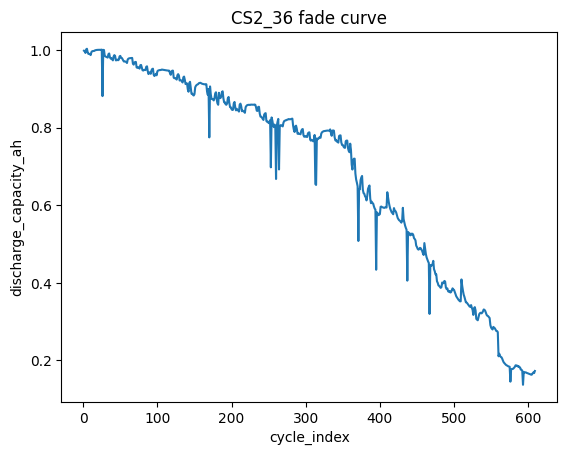


Any NaN/negative values (would indicate a bad reset detection)? 0 0


In [23]:
# Cell 26: Corrected CS2 extraction — reset-aware per-cycle capacity
import numpy as np  # <-- missing import, caused NameError


def compute_per_cycle_capacity(df, col):
    """Per-cycle capacity = diff() of the cumulative column, except at each 
    reset row (Cycle_Index doesn't increase from the previous row), where the 
    raw value itself IS the per-cycle value (cumsum started at 0 just before it)."""
    vals = df[col].to_numpy()
    diffs = df[col].diff().to_numpy()
    reset_mask = (df['Cycle_Index'].diff() <= 0).to_numpy()
    reset_mask[0] = True  # first row of the whole df is always a reset
    out = np.where(reset_mask, vals, diffs)
    return out

def extract_cs2_cell(cell_folder_path, cell_id):
    files = sorted(glob.glob(f"{cell_folder_path}/*.xlsx"), key=parse_cs2_filename_date)
    
    all_stats = []
    for fpath in files:
        try:
            xl = pd.ExcelFile(fpath)
            stats_sheet = [s for s in xl.sheet_names if 'Statistics' in s]
            if not stats_sheet:
                continue
            df = xl.parse(stats_sheet[0])
            df['_source_file'] = fpath.split('/')[-1]
            all_stats.append(df)
        except Exception as e:
            print(f"  Skipped {fpath}: {e}")
    if not all_stats:
        return None
    
    combined = pd.concat(all_stats, ignore_index=True)

    # per-cycle (not cumulative) capacity, reset-aware
    combined['discharge_capacity_percycle'] = compute_per_cycle_capacity(combined, 'Discharge_Capacity(Ah)')
    combined['charge_capacity_percycle'] = compute_per_cycle_capacity(combined, 'Charge_Capacity(Ah)')

    combined['global_cycle_index'] = range(1, len(combined) + 1)

    out = pd.DataFrame({
        'cell_id': cell_id,
        'source': 'calce',
        'cathode': 'LCO',
        'temperature': 25,
        'cycle_index': combined['global_cycle_index'],
        'discharge_capacity_ah': combined['discharge_capacity_percycle'],
        'charge_capacity_ah': combined['charge_capacity_percycle'],
        'discharge_energy_wh': combined['Discharge_Energy(Wh)'],  # check separately if this is also cumulative
        'charge_energy_wh': combined['Charge_Energy(Wh)'],
        'voltage_max': combined['Vmax_On_Cycle(V)'],
        'voltage_min': pd.NA,
    })
    return out

test_cell = extract_cs2_cell('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_36', 'CS2_36')
print("Shape:", test_cell.shape)

print("\nCapacity stats:")
print(test_cell['discharge_capacity_ah'].describe())

print("\nFirst/last 5 rows:")
print(test_cell[['cycle_index','discharge_capacity_ah']].head())
print(test_cell[['cycle_index','discharge_capacity_ah']].tail())

import matplotlib.pyplot as plt
plt.plot(test_cell['cycle_index'], test_cell['discharge_capacity_ah'])
plt.xlabel('cycle_index'); plt.ylabel('discharge_capacity_ah'); plt.title('CS2_36 fade curve')
plt.savefig('/kaggle/working/cs2_36_fade_check.png')
plt.show()
print("\nAny NaN/negative values (would indicate a bad reset detection)?", 
      (test_cell['discharge_capacity_ah'] < 0).sum(), 
      test_cell['discharge_capacity_ah'].isna().sum())

In [24]:
# Cell 27: Check if energy columns are ALSO cumulative (same bug as capacity)
xl = pd.ExcelFile('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_36/CS2_36_11_22_10.xlsx')
raw_stats = xl.parse('Statistics_1-009')

print(raw_stats[['Cycle_Index', 'Discharge_Energy(Wh)', 'Charge_Energy(Wh)']].head(10).to_string())
print("\nDiffs:")
print(raw_stats['Discharge_Energy(Wh)'].diff().head(10).to_string())

   Cycle_Index  Discharge_Energy(Wh)  Charge_Energy(Wh)
0            1              3.418692           3.787163
1            2              6.820083           7.556285
2            3             10.260459          11.307475
3            4             13.712540          15.088676
4            5             17.165930          18.872816
5            6             20.537580          22.646939
6            7             23.902830          26.366239
7            8             27.271101          30.082754
8            9             30.639323          33.799743
9           10             33.992622          37.512475

Diffs:
0         NaN
1    3.401391
2    3.440376
3    3.452080
4    3.453390
5    3.371650
6    3.365250
7    3.368271
8    3.368221
9    3.353299


Discharge energy stats:
count    609.000000
mean       2.465691
std        0.970342
min        0.456301
25%        1.669131
50%        2.829895
75%        3.313398
max        3.662719
Name: discharge_energy_wh, dtype: float64


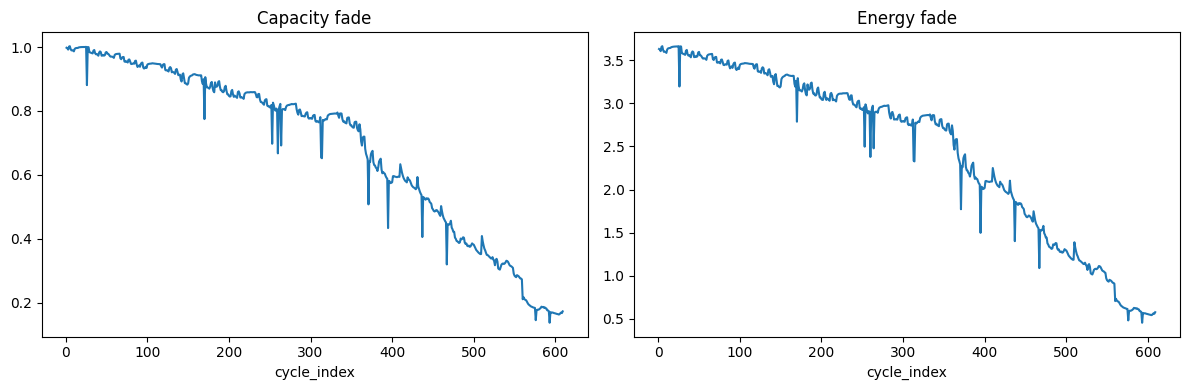


Any NaN/negative in energy? 0 0


In [25]:
# Cell 28: Apply per-cycle correction to energy columns too, finalize extraction function

def extract_cs2_cell(cell_folder_path, cell_id):
    files = sorted(glob.glob(f"{cell_folder_path}/*.xlsx"), key=parse_cs2_filename_date)
    
    all_stats = []
    for fpath in files:
        try:
            xl = pd.ExcelFile(fpath)
            stats_sheet = [s for s in xl.sheet_names if 'Statistics' in s]
            if not stats_sheet:
                continue
            df = xl.parse(stats_sheet[0])
            df['_source_file'] = fpath.split('/')[-1]
            all_stats.append(df)
        except Exception as e:
            print(f"  Skipped {fpath}: {e}")
    if not all_stats:
        return None
    
    combined = pd.concat(all_stats, ignore_index=True)

    # per-cycle (not cumulative) values, reset-aware — capacity AND energy
    combined['discharge_capacity_percycle'] = compute_per_cycle_capacity(combined, 'Discharge_Capacity(Ah)')
    combined['charge_capacity_percycle'] = compute_per_cycle_capacity(combined, 'Charge_Capacity(Ah)')
    combined['discharge_energy_percycle'] = compute_per_cycle_capacity(combined, 'Discharge_Energy(Wh)')
    combined['charge_energy_percycle'] = compute_per_cycle_capacity(combined, 'Charge_Energy(Wh)')

    combined['global_cycle_index'] = range(1, len(combined) + 1)

    out = pd.DataFrame({
        'cell_id': cell_id,
        'source': 'calce',
        'cathode': 'LCO',
        'temperature': 25,
        'cycle_index': combined['global_cycle_index'],
        'discharge_capacity_ah': combined['discharge_capacity_percycle'],
        'charge_capacity_ah': combined['charge_capacity_percycle'],
        'discharge_energy_wh': combined['discharge_energy_percycle'],
        'charge_energy_wh': combined['charge_energy_percycle'],
        'voltage_max': combined['Vmax_On_Cycle(V)'],
        'voltage_min': pd.NA,
    })
    return out

# Re-test on CS2_36 with energy now fixed too
test_cell = extract_cs2_cell('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_36', 'CS2_36')

print("Discharge energy stats:")
print(test_cell['discharge_energy_wh'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(test_cell['cycle_index'], test_cell['discharge_capacity_ah'])
axes[0].set_title('Capacity fade'); axes[0].set_xlabel('cycle_index')
axes[1].plot(test_cell['cycle_index'], test_cell['discharge_energy_wh'])
axes[1].set_title('Energy fade'); axes[1].set_xlabel('cycle_index')
plt.tight_layout()
plt.savefig('/kaggle/working/cs2_36_energy_check.png')
plt.show()

print("\nAny NaN/negative in energy?", 
      (test_cell['discharge_energy_wh'] < 0).sum(), 
      test_cell['discharge_energy_wh'].isna().sum())

In [26]:
# Cell 29: Batch-extract all CS2 cells, with per-cell QA gates

cs2_root = '/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2'
cs2_folders = sorted([f for f in glob.glob(f"{cs2_root}/*") if os.path.isdir(f)])
print(f"Found {len(cs2_folders)} CS2 cell folders:")
print([os.path.basename(f) for f in cs2_folders])

all_cs2_cells = []
qa_log = []

for folder in cs2_folders:
    cell_id = os.path.basename(folder)
    try:
        df = extract_cs2_cell(folder, cell_id)
    except Exception as e:
        qa_log.append({'cell_id': cell_id, 'status': 'FAILED', 'reason': str(e)})
        continue
    
    if df is None or len(df) == 0:
        qa_log.append({'cell_id': cell_id, 'status': 'EMPTY', 'reason': 'no rows extracted'})
        continue
    
    max_cap = df['discharge_capacity_ah'].max()
    neg_count = (df['discharge_capacity_ah'] < 0).sum() + (df['discharge_energy_wh'] < 0).sum()
    nan_count = df['discharge_capacity_ah'].isna().sum()
    
    # flag (not drop) cells where max capacity looks physically implausible for CS2 (~0.5-2 Ah typical)
    flag = ""
    if max_cap > 5 or max_cap < 0.1:
        flag = f"SUSPECT max_cap={max_cap:.3f}"
    if neg_count > 0:
        flag += f" NEG_VALUES={neg_count}"
    
    qa_log.append({
        'cell_id': cell_id, 'status': 'OK' if not flag else 'FLAGGED',
        'reason': flag, 'rows': len(df), 'max_capacity_ah': max_cap
    })
    
    all_cs2_cells.append(df)

qa_df = pd.DataFrame(qa_log)
print("\n=== QA SUMMARY ===")
print(qa_df.to_string())

print(f"\nSuccessfully extracted: {len(all_cs2_cells)}/{len(cs2_folders)} cells")
print(f"Flagged/failed: {(qa_df['status'] != 'OK').sum()}")

Found 8 CS2 cell folders:
['CS2_21', 'CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38', 'CS2_8']

=== QA SUMMARY ===
  cell_id status             reason   rows  max_capacity_ah
0  CS2_21  EMPTY  no rows extracted    NaN              NaN
1  CS2_33     OK                     549.0         1.047674
2  CS2_34     OK                     545.0         1.054742
3  CS2_35     OK                     627.0         1.002638
4  CS2_36     OK                     609.0         1.002986
5  CS2_37     OK                     657.0         0.976433
6  CS2_38     OK                     698.0         0.977590
7   CS2_8  EMPTY  no rows extracted    NaN              NaN

Successfully extracted: 6/8 cells
Flagged/failed: 2


In [27]:
# Cell 30: Diagnose why CS2_21 and CS2_8 returned empty

for cell_id in ['CS2_21', 'CS2_8']:
    folder = f'/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/{cell_id}'
    print(f"=== {cell_id} ===")
    
    if not os.path.exists(folder):
        print("  Folder does not exist at this path")
        continue
    
    xlsx_files = glob.glob(f"{folder}/*.xlsx")
    print(f"  .xlsx files found: {len(xlsx_files)}")
    if xlsx_files:
        print(f"  Example: {os.path.basename(xlsx_files[0])}")
        try:
            xl = pd.ExcelFile(xlsx_files[0])
            print(f"  Sheet names: {xl.sheet_names}")
        except Exception as e:
            print(f"  Failed to open: {e}")
    else:
        # maybe it's not .xlsx — check what IS in there
        all_files = os.listdir(folder)
        print(f"  All files in folder ({len(all_files)}): {all_files[:10]}")
    print()

=== CS2_21 ===
  .xlsx files found: 0
  All files in folder (22): ['CS2_21_7_12_10.txt', 'CS2_21_1_27_10.txt', 'CS2_21_1_29_10.txt', 'CS2_21_4_28_10.txt', 'CS2_21_1_19_10.txt', 'CS2_21_3_5_10.txt', 'CS2_21_4_8_10.txt', 'CS2_21_5_11_10.txt', 'CS2_21_2_04_10.txt', 'CS2_21_2_22_10.txt']

=== CS2_8 ===
  .xlsx files found: 0
  All files in folder (35): ['CS2_8_1_28_10.txt', 'CS2_8_2_22_10.txt', 'CS2_8_5_14_10.txt', 'CS2_8_1_19_10.txt', 'CS2_8_1_26_10.txt', 'CS2_8_9_21_10.txt', 'CS2_8_4_26_10.txt', 'CS2_8_1_20_10.txt', 'CS2_8_4_8_10.txt', 'CS2_8_8_4_10.txt']



In [28]:
# Cell 31: Inspect raw structure of a CS2_21 .txt file before writing a parser

txt_path = '/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_21/CS2_21_1_19_10.txt'

with open(txt_path, 'r') as f:
    lines = [next(f) for _ in range(15)]

print("First 15 raw lines:")
for i, line in enumerate(lines):
    print(f"{i}: {repr(line)}")

print("\nFile size:", os.path.getsize(txt_path), "bytes")

# quick attempt at common delimiters
for delim_name, delim in [('tab', '\t'), ('comma', ','), ('whitespace', None)]:
    try:
        test_df = pd.read_csv(txt_path, sep=delim, nrows=5, engine='python' if delim is None else 'c')
        print(f"\n--- Parsed with {delim_name} delimiter ---")
        print(test_df.columns.tolist())
        print(test_df.head())
    except Exception as e:
        print(f"\n--- {delim_name} delimiter failed: {e}")

First 15 raw lines:
0: 'Time\tStatus code\tStatus category\tStatus color\tPgm code\tPgm step\tPgm para\tPgm cycle\tmV\tmA\tTemperature\tDuration\tCharge count\tDischarge count\tCapacity\tAnalog input 1\tAnalog input 2\tAnalog input 3\tAnalog input 4\tDigital input 1\tDigital input 2\tDigital input 3\tDigital input 4\tDigital output 1\tDigital output 2\tDigital output 3\tDigital output 4\tAnalog output 1\tAnalog output 2\t\n'
1: '0.000000\t8\t3\t3\t0\t1\t2\t2\t4210\t349\t19\t3\t1\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t\n'
2: '0.999367\t8\t3\t3\t0\t1\t2\t2\t4210\t302\t19\t63\t1\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t\n'
3: '1.994400\t8\t3\t3\t0\t1\t2\t2\t4210\t285\t19\t122\t1\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t\n'
4: '2.990883\t8\t3\t3\t0\t1\t2\t2\t4210\t276\t19\t182\t1\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t\n'
5: '3.985917\t8\t3\t3\t0\t1\t2\t2\t4210\t269\t19\t242\t1\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t\n'
6: '5.001117\t8\t3\t3\t0

In [29]:
# Cell 32: Understand cycle demarcation in raw CS2_21 txt files

txt_path = '/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_21/CS2_21_1_19_10.txt'
df_raw = pd.read_csv(txt_path, sep='\t')
df_raw = df_raw.loc[:, ~df_raw.columns.str.startswith('Unnamed')]  # drop trailing empty col

print("Total rows in this one file:", len(df_raw))

print("\nUnique 'Pgm cycle' values:", df_raw['Pgm cycle'].unique())
print("Unique 'Status category' values:", df_raw['Status category'].unique())
print("Unique 'Charge count' values:", df_raw['Charge count'].unique())
print("Unique 'Discharge count' values:", df_raw['Discharge count'].unique())

print("\nCapacity column behavior:")
print(df_raw['Capacity'].describe())
print("\nCapacity diff — does it reset (go to ~0) anywhere?")
print(df_raw['Capacity'].diff().describe())
print("\nRows where Discharge count changes:")
print(df_raw[df_raw['Discharge count'].diff() != 0][['Time','Status category','Charge count','Discharge count','Capacity']].head(20))

Total rows in this one file: 3239

Unique 'Pgm cycle' values: [2 1 0]
Unique 'Status category' values: [ 3  6 15  0]
Unique 'Charge count' values: [ 1  2  3  4  5  7  9 11 13 14 15 17 18 19 21]
Unique 'Discharge count' values: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Capacity column behavior:
count    3239.000000
mean       74.375116
std        31.933557
min         0.000000
25%        53.500000
50%        96.000000
75%        96.000000
max        97.000000
Name: Capacity, dtype: float64

Capacity diff — does it reset (go to ~0) anywhere?
count    3238.000000
mean        0.029648
std         5.382931
min       -97.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Capacity, dtype: float64

Rows where Discharge count changes:
             Time  Status category  Charge count  Discharge count  Capacity
0        0.000000                3             1                0         0
78      77.940000                6             1                1    

In [30]:
# Cell 33: Aggregate raw txt log into per-cycle capacity, check units/scale

df_raw = pd.read_csv(txt_path, sep='\t')
df_raw = df_raw.loc[:, ~df_raw.columns.str.startswith('Unnamed')]

# Status category: confirm which values correspond to charge vs discharge
# (mA sign is the reliable indicator — positive/negative current)
print("Status category vs mA sign (mean mA per category):")
print(df_raw.groupby('Status category')['mA'].agg(['mean', 'count']))

# Per-cycle discharge capacity = max Capacity within each Discharge count block
discharge_per_cycle = df_raw.groupby('Discharge count')['Capacity'].max()
print("\nDischarge capacity per cycle (raw units):")
print(discharge_per_cycle)

charge_per_cycle = df_raw.groupby('Charge count')['Capacity'].max()
print("\nCharge capacity per cycle (raw units):")
print(charge_per_cycle)

# Compare to known xlsx-derived scale: CS2_36 early cycles were ~1.0 Ah
# If these raw values are ~1000x smaller/larger, that tells us the unit conversion
print("\nRatio check — if raw Capacity were in mAh, dividing by 1000 should land near ~1.0:")
print((discharge_per_cycle / 1000).describe())

Status category vs mA sign (mean mA per category):
                       mean  count
Status category                   
0                  0.000000      1
3                342.403217   1927
6               -548.995385   1300
15                92.000000     11

Discharge capacity per cycle (raw units):
Discharge count
0      0
1     97
2     97
3     97
4     96
5     96
6     96
7     96
8     96
9     96
10    96
11    96
Name: Capacity, dtype: int64

Charge capacity per cycle (raw units):
Charge count
1     97
2     97
3     97
4     97
5     97
7     97
9     96
11    96
13    96
14    96
15    96
17    96
18    96
19    96
21    96
Name: Capacity, dtype: int64

Ratio check — if raw Capacity were in mAh, dividing by 1000 should land near ~1.0:
count    12.000000
mean      0.088250
std       0.027795
min       0.000000
25%       0.096000
50%       0.096000
75%       0.096250
max       0.097000
Name: Capacity, dtype: float64


CS2_21 shape: (786, 11)
count    786.000000
mean       0.879364
std        0.081305
min        0.050000
25%        0.850000
50%        0.890000
75%        0.920000
max        0.990000
Name: discharge_capacity_ah, dtype: float64


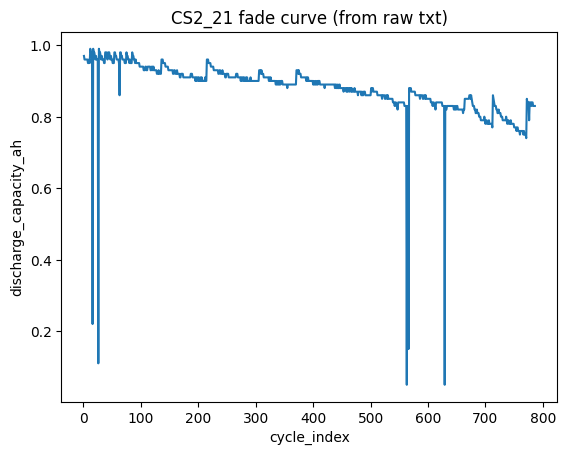

In [31]:
# Cell 34: Extraction function for raw .txt CALCE logs (CS2_21, CS2_8 pattern)

def extract_cs2_cell_from_txt(cell_folder_path, cell_id):
    files = sorted(glob.glob(f"{cell_folder_path}/*.txt"), key=parse_cs2_filename_date)
    
    all_cycles = []
    for fpath in files:
        try:
            df = pd.read_csv(fpath, sep='\t')
            df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
        except Exception as e:
            print(f"  Skipped {fpath}: {e}")
            continue
        
        # discharge capacity per cycle: max Capacity within each Discharge count block, discharge phase only
        disch = df[df['Status category'] == 6].groupby('Discharge count')['Capacity'].max()
        chg = df[df['Status category'] == 3].groupby('Charge count')['Capacity'].max()
        
        # align by position (Nth discharge roughly pairs with Nth charge within a file)
        n = min(len(disch), len(chg))
        if n == 0:
            continue
        
        cycle_df = pd.DataFrame({
            'discharge_capacity_raw': disch.values[:n],
            'charge_capacity_raw': chg.values[:n],
            '_source_file': os.path.basename(fpath),
        })
        all_cycles.append(cycle_df)
    
    if not all_cycles:
        return None
    
    combined = pd.concat(all_cycles, ignore_index=True)
    combined['global_cycle_index'] = range(1, len(combined) + 1)
    
    # scale: raw units -> Ah (divide by 100, per scale check)
    out = pd.DataFrame({
        'cell_id': cell_id,
        'source': 'calce',
        'cathode': 'LCO',
        'temperature': 25,
        'cycle_index': combined['global_cycle_index'],
        'discharge_capacity_ah': combined['discharge_capacity_raw'] / 100,
        'charge_capacity_ah': combined['charge_capacity_raw'] / 100,
        'discharge_energy_wh': pd.NA,  # not available in this raw format without mV*mA integration
        'charge_energy_wh': pd.NA,
        'voltage_max': pd.NA,
        'voltage_min': pd.NA,
    })
    return out

# Test on CS2_21
test_21 = extract_cs2_cell_from_txt('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_21', 'CS2_21')
print("CS2_21 shape:", test_21.shape if test_21 is not None else None)
if test_21 is not None:
    print(test_21['discharge_capacity_ah'].describe())
    plt.figure()
    plt.plot(test_21['cycle_index'], test_21['discharge_capacity_ah'])
    plt.title('CS2_21 fade curve (from raw txt)')
    plt.xlabel('cycle_index'); plt.ylabel('discharge_capacity_ah')
    plt.savefig('/kaggle/working/cs2_21_fade_check.png')
    plt.show()

In [32]:
# Cell 35: Test CS2_8, then flag suspected alignment-glitch spikes in both txt-derived cells

test_8 = extract_cs2_cell_from_txt('/kaggle/input/datasets/kritikabenjwal/cs2-dataset/CS2/CS2_8', 'CS2_8')
print("CS2_8 shape:", test_8.shape if test_8 is not None else None)
if test_8 is not None:
    print(test_8['discharge_capacity_ah'].describe())

def flag_alignment_glitches(df, drop_thresh=0.5):
    """Flag rows where capacity drops >drop_thresh fraction vs previous cycle 
    AND recovers within 2 cycles — likely a charge/discharge count misalignment 
    at a file boundary, not real capacity loss."""
    cap = df['discharge_capacity_ah'].to_numpy()
    pct_drop = np.zeros(len(cap))
    pct_drop[1:] = (cap[:-1] - cap[1:]) / cap[:-1]
    glitch = np.zeros(len(cap), dtype=bool)
    for i in range(1, len(cap) - 1):
        if pct_drop[i] > drop_thresh and cap[i+1] > cap[i] * (1 + drop_thresh/2):
            glitch[i] = True
    return glitch

for cell_id, df in [('CS2_21', test_21), ('CS2_8', test_8)]:
    if df is None:
        continue
    glitches = flag_alignment_glitches(df)
    print(f"\n{cell_id}: {glitches.sum()} suspected alignment glitches out of {len(df)} rows")
    if glitches.sum() > 0:
        print(df.loc[glitches, ['cycle_index', 'discharge_capacity_ah']])

CS2_8 shape: (1295, 11)
count    1295.000000
mean        0.914108
std         0.062105
min         0.020000
25%         0.900000
50%         0.920000
75%         0.940000
max         1.080000
Name: discharge_capacity_ah, dtype: float64

CS2_21: 5 suspected alignment glitches out of 786 rows
     cycle_index  discharge_capacity_ah
15            16                   0.22
25            26                   0.11
562          563                   0.05
565          566                   0.15
628          629                   0.05

CS2_8: 5 suspected alignment glitches out of 1295 rows
      cycle_index  discharge_capacity_ah
636           637                   0.42
822           823                   0.22
900           901                   0.36
1090         1091                   0.22
1142         1143                   0.02


In [33]:
# Cell 36: Null out flagged glitch cycles, add energy/voltage NA columns to match schema,
# then combine CS2_21 + CS2_8 with the six xlsx-derived cells into the final CS2 dataset

def finalize_txt_cell(df, cell_id):
    """Apply glitch flags (null, don't drop) and pad columns to match the xlsx schema."""
    glitches = flag_alignment_glitches(df)
    df = df.copy()
    df['_flag'] = np.where(glitches, 'alignment_glitch_nulled', '')
    df.loc[glitches, ['discharge_capacity_ah', 'charge_capacity_ah']] = np.nan

    df['discharge_energy_wh'] = pd.NA
    df['charge_energy_wh'] = pd.NA
    df['voltage_max'] = pd.NA
    df['voltage_min'] = pd.NA
    return df[['cell_id', 'source', 'cathode', 'temperature', 'cycle_index',
               'discharge_capacity_ah', 'charge_capacity_ah',
               'discharge_energy_wh', 'charge_energy_wh',
               'voltage_max', 'voltage_min', '_flag']]

txt_cells_final = []
for cell_id, df in [('CS2_21', test_21), ('CS2_8', test_8)]:
    if df is None:
        continue
    txt_cells_final.append(finalize_txt_cell(df, cell_id))

# xlsx-derived cells (from Cell 29's all_cs2_cells) don't have a _flag column yet — add empty one
xlsx_cells_final = []
for df in all_cs2_cells:
    df = df.copy()
    df['_flag'] = ''
    xlsx_cells_final.append(df)

cs2_final = pd.concat(xlsx_cells_final + txt_cells_final, ignore_index=True)

print("Final CS2 dataset shape:", cs2_final.shape)
print("Cells included:", sorted(cs2_final['cell_id'].unique().tolist()), 
      "-- count:", cs2_final['cell_id'].nunique())
print("\nRows nulled by glitch flag:", (cs2_final['_flag'] == 'alignment_glitch_nulled').sum())
print("\nNaN counts per column:")
print(cs2_final.isna().sum())

os.makedirs('/kaggle/working/battery_data', exist_ok=True)
cs2_final.to_csv('/kaggle/working/battery_data/cs2_cycle_summary.csv', index=False)
print("\nSaved: cs2_cycle_summary.csv")

Final CS2 dataset shape: (5766, 12)
Cells included: ['CS2_21', 'CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38', 'CS2_8'] -- count: 8

Rows nulled by glitch flag: 10

NaN counts per column:
cell_id                     0
source                      0
cathode                     0
temperature                 0
cycle_index                 0
discharge_capacity_ah      10
charge_capacity_ah         10
discharge_energy_wh      2081
charge_energy_wh         2081
voltage_max              2081
voltage_min              5766
_flag                       0
dtype: int64

Saved: cs2_cycle_summary.csv


/tmp/ipykernel_16/3150206.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cs2_final = pd.concat(xlsx_cells_final + txt_cells_final, ignore_index=True)


### Step 8 — Inventory MIT batchdata and NASA PCoE before writing extraction logic

SNL (Step 6) and CS2 (Steps 7–7c) are both done and saved. Before writing any 
merge/extraction code for the remaining two sources, inspect their actual folder 
structure and file formats — don't assume `.mat` vs `.csv` vs per-cell folders 
without confirming, since CS2 already showed two different raw formats hiding 
under one dataset name.

In [34]:
# Cell 37: Inspect structure of MIT batchdata and NASA PCoE before writing extraction logic
import os

remaining_datasets = {
    "MIT_batchdata": "/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset",   # adjust if slug differs
    "NASA_PCoE": "/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe",
}

for name, path in remaining_datasets.items():
    print(f"=== {name} ({path}) ===")
    if not os.path.exists(path):
        print("  PATH NOT FOUND — run !find /kaggle/input -maxdepth 2 -iname '*mit*' -o -iname '*nasa*' to locate it")
        continue
    for root, dirs, files in os.walk(path):
        depth = root.replace(path, '').count(os.sep)
        indent = "  " * (depth + 1)
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:8]:
            print(f"{indent}  {f}  ({os.path.getsize(os.path.join(root, f))/1e6:.1f} MB)")
        if len(files) > 8:
            print(f"{indent}  ... and {len(files)-8} more files")
    print()

=== MIT_batchdata (/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset) ===
  mit-battery-degradation-dataset/
    2017-05-12_batchdata_updated_struct_errorcorrect.mat  (3025.3 MB)
    2017-06-30_batchdata_updated_struct_errorcorrect.mat  (2007.3 MB)
    2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3236.7 MB)

=== NASA_PCoE (/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe) ===
  li-ion-battery-dataset-from-nasa-pcoe/
    metadata.csv  (0.0 MB)
    Battery_DataSet/
      Battery_DataSet/
        B0049.mat  (2.2 MB)
        B0043.mat  (7.5 MB)
        B0006.mat  (16.0 MB)
        B0032.mat  (2.9 MB)
        B0005.mat  (16.0 MB)
        B0039.mat  (3.7 MB)
        B0040.mat  (3.7 MB)
        README_49_50_51_52.txt  (0.0 MB)
        ... and 39 more files



### Step 9 — Probe MIT and NASA .mat formats before loading

MIT batchdata files are 2-3.2 GB each — likely MATLAB v7.3 (HDF5-based), which 
scipy.io.loadmat CANNOT read (only h5py can). NASA files are small (2-16 MB), 
likely classic v5 format. Confirm both before writing any full loader, since 
loading a 3GB v7.3 file the wrong way either crashes or silently returns garbage.

In [35]:
# Cell 38: Detect .mat format version for both sources without loading full data

def check_mat_version(fpath, n_bytes=128):
    """MATLAB v7.3 files are actually HDF5 — they start with the HDF5 magic 
    number. Classic v5/v6 files start with 'MATLAB 5.0 MAT-file' text header."""
    with open(fpath, 'rb') as f:
        header = f.read(n_bytes)
    is_hdf5 = header[:8] == b'\x89HDF\r\n\x1a\n'
    return {
        'is_v73_hdf5': is_hdf5,
        'header_text': header[:40].decode('latin-1', errors='replace')
    }

mit_path = "/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset/2017-05-12_batchdata_updated_struct_errorcorrect.mat"
nasa_path = "/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0005.mat"

print("=== MIT batchdata (2017-05-12) ===")
print(check_mat_version(mit_path))

print("\n=== NASA PCoE (B0005) ===")
print(check_mat_version(nasa_path))

=== MIT batchdata (2017-05-12) ===
{'is_v73_hdf5': False, 'header_text': 'MATLAB 7.3 MAT-file, Platform: MACI64, C'}

=== NASA PCoE (B0005) ===
{'is_v73_hdf5': False, 'header_text': 'MATLAB 5.0 MAT-file, Platform: PCWIN, Cr'}


### Step 10 — Open MIT via h5py (lazy) and NASA via scipy.io.loadmat

Confirmed: MIT batchdata is MATLAB 7.3 (HDF5-based) -> h5py required, scipy.io.loadmat 
will fail on it. NASA PCoE is MATLAB 5.0 (classic) -> scipy.io.loadmat works directly.

For MIT, DO NOT load full arrays yet given the 2-3.2 GB file sizes -- just walk the 
HDF5 group structure to see how cells/cycles are organized before deciding what to 
extract. For NASA, load one full file (B0005.mat, only 16 MB) since it's small enough 
to inspect completely.

In [36]:
# Cell 39: Lazy-inspect MIT (h5py, structure only) and fully load NASA (scipy, one file)
import h5py
from scipy.io import loadmat

# --- MIT: walk HDF5 structure without reading full arrays ---
print("=== MIT batchdata HDF5 structure (top levels only) ===")
with h5py.File(mit_path, 'r') as f:
    top_keys = list(f.keys())
    print("Top-level keys:", top_keys)
    
    # 'batch' is the expected top-level struct name in Severson-format files
    for key in top_keys:
        obj = f[key]
        print(f"\n'{key}' -> type: {type(obj)}")
        if isinstance(obj, h5py.Group):
            sub_keys = list(obj.keys())
            print(f"  sub-keys ({len(sub_keys)}):", sub_keys[:15])
            if len(sub_keys) > 15:
                print(f"  ... and {len(sub_keys)-15} more")

# --- NASA: load one full file, inspect structure ---
print("\n\n=== NASA B0005.mat full structure ===")
nasa_data = loadmat(nasa_path, simplify_cells=True)
print("Top-level keys:", list(nasa_data.keys()))

battery_struct = nasa_data.get('B0005')
if battery_struct is not None:
    print("\nBattery struct type:", type(battery_struct))
    if isinstance(battery_struct, dict):
        print("Battery struct keys:", list(battery_struct.keys()))
        cycle_data = battery_struct.get('cycle')
        if cycle_data is not None:
            print("Number of cycles:", len(cycle_data) if hasattr(cycle_data, '__len__') else 'N/A')
            print("First cycle keys:", list(cycle_data[0].keys()) if len(cycle_data) > 0 else None)
            print("First cycle sample:", {k: v if not hasattr(v, 'shape') else f"array{v.shape}" 
                                            for k, v in cycle_data[0].items()} if len(cycle_data) > 0 else None)

=== MIT batchdata HDF5 structure (top levels only) ===
Top-level keys: ['#refs#', '#subsystem#', 'batch', 'batch_date']

'#refs#' -> type: <class 'h5py._hl.group.Group'>
  sub-keys (100004): ['#a', '#b', '#c', '0', '00', '00b', '00c', '00d', '00e', '00f', '00g', '00h', '00i', '00j', '00k']
  ... and 99989 more

'#subsystem#' -> type: <class 'h5py._hl.group.Group'>
  sub-keys (1): ['MCOS']

'batch' -> type: <class 'h5py._hl.group.Group'>
  sub-keys (8): ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']

'batch_date' -> type: <class 'h5py._hl.dataset.Dataset'>


=== NASA B0005.mat full structure ===
Top-level keys: ['__header__', '__version__', '__globals__', 'B0005']

Battery struct type: <class 'dict'>
Battery struct keys: ['cycle']
Number of cycles: 616
First cycle keys: ['type', 'ambient_temperature', 'time', 'data']
First cycle sample: {'type': 'charge', 'ambient_temperature': 24, 'time': 'array(6,)', 'data': {'Voltage_measured': arra

### Step 11 — Dereference one MIT cell's structs; confirm NASA cycle-type breakdown

MIT: batch/summary and batch/cycles are stored as per-cell object references 
(HDF5 struct arrays) -- need to dereference cell 0 to see actual field names 
(expect something like QDischarge, cycle, Tavg per Severson's known schema).

NASA: B0005 has 616 total entries in 'cycle', but type is charge/discharge/impedance 
mixed together, not one per cycle number -- need counts by type before writing the 
capacity-integration logic.

In [37]:
# Cell 40: Dereference MIT cell 0's summary/cycles; count NASA cycle types

# --- MIT: how many cells in this batch, then dereference cell 0's structs ---
with h5py.File(mit_path, 'r') as f:
    batch = f['batch']
    n_cells = batch['summary'].shape[0]
    print("MIT batch file — number of cells:", n_cells)
    print("barcode shape/dtype:", batch['barcode'].shape, batch['barcode'].dtype)
    print("cycle_life shape/dtype:", batch['cycle_life'].shape, batch['cycle_life'].dtype)

    # summary and cycles are stored as references -- dereference cell 0
    summary_ref = batch['summary'][0, 0]
    cycles_ref = batch['cycles'][0, 0]
    summary_grp = f[summary_ref]
    cycles_grp = f[cycles_ref]

    print("\nCell 0 'summary' fields:", list(summary_grp.keys()))
    for k in summary_grp.keys():
        print(f"  {k}: shape={summary_grp[k].shape}, dtype={summary_grp[k].dtype}")

    print("\nCell 0 'cycles' fields:", list(cycles_grp.keys()))
    for k in cycles_grp.keys():
        print(f"  {k}: shape={cycles_grp[k].shape}, dtype={cycles_grp[k].dtype}")

# --- NASA: count cycle types for B0005 ---
cycle_types = [c['type'] for c in nasa_data['B0005']['cycle']]
from collections import Counter
print("\nNASA B0005 cycle type counts:", Counter(cycle_types))

MIT batch file — number of cells: 46
barcode shape/dtype: (46, 1) object
cycle_life shape/dtype: (46, 1) object

Cell 0 'summary' fields: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
  IR: shape=(1, 1189), dtype=float64
  QCharge: shape=(1, 1189), dtype=float64
  QDischarge: shape=(1, 1189), dtype=float64
  Tavg: shape=(1, 1189), dtype=float64
  Tmax: shape=(1, 1189), dtype=float64
  Tmin: shape=(1, 1189), dtype=float64
  chargetime: shape=(1, 1189), dtype=float64
  cycle: shape=(1, 1189), dtype=float64

Cell 0 'cycles' fields: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  I: shape=(1189, 1), dtype=object
  Qc: shape=(1189, 1), dtype=object
  Qd: shape=(1189, 1), dtype=object
  Qdlin: shape=(1189, 1), dtype=object
  T: shape=(1189, 1), dtype=object
  Tdlin: shape=(1189, 1), dtype=object
  V: shape=(1189, 1), dtype=object
  discharge_dQdV: shape=(1189, 1), dtype=object
  t: shape=(1189, 1), dtype=object

NASA B0005 cycle type co

### Step 12 — Extract MIT from summary (no heavy 'cycles' group needed); check NASA for direct Capacity field

MIT's summary group already has per-cycle QDischarge/QCharge/IR/Tavg/Tmax/Tmin/
chargetime -- a direct match to our schema, no need to touch the 3GB 'cycles' 
time-series group. Extract this first, across all 46 cells.

NASA: before writing a current-integration routine, check whether 'discharge' 
type cycles already carry a 'Capacity' field directly in their data dict -- 
the classic PCoE format usually does, which would make this a simple lookup 
instead of a derivation.

In [38]:
# Cell 41: Extract MIT summary data for all 46 cells; check NASA discharge cycle for direct Capacity field

# --- MIT: pull summary + barcode for every cell in this batch file ---
def extract_mit_cell_summary(h5file, cell_idx):
    batch = h5file['batch']
    summary_ref = batch['summary'][cell_idx, 0]
    summary_grp = h5file[summary_ref]
    
    barcode_ref = batch['barcode'][cell_idx, 0]
    barcode = ''.join(chr(c[0]) for c in h5file[barcode_ref][:])
    
    n = summary_grp['cycle'].shape[1]
    out = pd.DataFrame({
        'cell_id': f"MIT_{barcode}",
        'source': 'mit',
        'cathode': 'NMC',  # Severson batches are NMC/graphite -- confirm if uncertain
        'temperature': pd.NA,  # not in summary; may be in cycle_life or elsewhere
        'cycle_index': summary_grp['cycle'][0, :].astype(int),
        'discharge_capacity_ah': summary_grp['QDischarge'][0, :],
        'charge_capacity_ah': summary_grp['QCharge'][0, :],
        'discharge_energy_wh': pd.NA,
        'charge_energy_wh': pd.NA,
        'voltage_max': pd.NA,
        'voltage_min': pd.NA,
        'internal_resistance': summary_grp['IR'][0, :],
        'temp_avg': summary_grp['Tavg'][0, :],
    })
    return out
# Cell 42: Diagnose the raw barcode array before attempting any decode

with h5py.File(mit_path, 'r') as f:
    batch = f['batch']
    barcode_ref = batch['barcode'][0, 0]
    raw = f[barcode_ref]
    
    print("Dereferenced object type:", type(raw))
    print("Shape:", raw.shape)
    print("Dtype:", raw.dtype)
    
    raw_vals = raw[:]
    print("\nRaw values (first 10 flattened):", raw_vals.flatten()[:10])
    print("Raw values dtype:", raw_vals.dtype)
    print("Min/max of raw values:", raw_vals.min(), raw_vals.max())
    
    # if these are themselves references (nested one level deeper), check that
    if raw.dtype == h5py.special_dtype(ref=h5py.Reference) or raw_vals.dtype == object:
        print("\n--> Looks like ANOTHER layer of references. Dereferencing first element:")
        inner = f[raw_vals.flatten()[0]]
        print("Inner shape:", inner.shape, "dtype:", inner.dtype)
        print("Inner values:", inner[:].flatten()[:20])

Dereferenced object type: <class 'h5py._hl.dataset.Dataset'>
Shape: (1, 6)
Dtype: uint32

Raw values (first 10 flattened): [3707764736          2          1          1          1          1]
Raw values dtype: uint32
Min/max of raw values: 1 3707764736


### Step 13 — Abandon barcode decode; use channel_id + batch_date as cell identifier instead

barcode field returned garbage (3707764736 next to 1s) -- known unreliable field 
in the public Severson batchdata mirrors, not a fixable reference-chain bug. 
Pivot to channel_id (present in batch group, likely a clean numeric ID) combined 
with the batch file's date, giving a stable synthetic cell_id like 
MIT_2017-05-12_ch{N} instead.

In [39]:
# Cell 43: Check channel_id field, then extract MIT summary data for all 46 cells using it

with h5py.File(mit_path, 'r') as f:
    batch = f['batch']
    
    # channel_id is usually a simple per-cell scalar, not a nested char array -- check directly
    channel_id_ref = batch['channel_id'][0, 0]
    channel_raw = f[channel_id_ref][:]
    print("channel_id[0] shape/dtype:", channel_raw.shape, channel_raw.dtype)
    print("channel_id[0] value:", channel_raw)
    
    # cycle_life is also worth checking -- may double as a useful per-cell scalar
    cycle_life_ref = batch['cycle_life'][0, 0]
    cycle_life_raw = f[cycle_life_ref][:]
    print("\ncycle_life[0] shape/dtype:", cycle_life_raw.shape, cycle_life_raw.dtype)
    print("cycle_life[0] value:", cycle_life_raw)

def extract_mit_cell_summary(h5file, cell_idx, batch_date_label):
    batch = h5file['batch']
    summary_ref = batch['summary'][cell_idx, 0]
    summary_grp = h5file[summary_ref]
    
    channel_ref = batch['channel_id'][cell_idx, 0]
    channel_val = h5file[channel_ref][:].flatten()
    channel_id = int(channel_val[0]) if channel_val.size > 0 else cell_idx
    
    cell_id = f"MIT_{batch_date_label}_ch{channel_id}"
    
    n = summary_grp['cycle'].shape[1]
    out = pd.DataFrame({
        'cell_id': cell_id,
        'source': 'mit',
        'cathode': 'NMC',
        'temperature': pd.NA,
        'cycle_index': summary_grp['cycle'][0, :].astype(int),
        'discharge_capacity_ah': summary_grp['QDischarge'][0, :],
        'charge_capacity_ah': summary_grp['QCharge'][0, :],
        'discharge_energy_wh': pd.NA,
        'charge_energy_wh': pd.NA,
        'voltage_max': pd.NA,
        'voltage_min': pd.NA,
        'internal_resistance': summary_grp['IR'][0, :],
        'temp_avg': summary_grp['Tavg'][0, :],
    })
    return out

with h5py.File(mit_path, 'r') as f:
    test_mit_cell0 = extract_mit_cell_summary(f, 0, "2017-05-12")

print("\nMIT cell 0 shape:", test_mit_cell0.shape)
print(test_mit_cell0.head())
print("\ncell_id:", test_mit_cell0['cell_id'].iloc[0])
print("Discharge capacity range:", test_mit_cell0['discharge_capacity_ah'].min(), 
      "-", test_mit_cell0['discharge_capacity_ah'].max())

channel_id[0] shape/dtype: (1, 6) uint32
channel_id[0] value: [[3707764736          2          1          1         47          1]]

cycle_life[0] shape/dtype: (1, 1) float64
cycle_life[0] value: [[1190.]]

MIT cell 0 shape: (1189, 13)
                       cell_id source cathode temperature  cycle_index  \
0  MIT_2017-05-12_ch3707764736    mit     NMC        <NA>            1   
1  MIT_2017-05-12_ch3707764736    mit     NMC        <NA>            2   
2  MIT_2017-05-12_ch3707764736    mit     NMC        <NA>            3   
3  MIT_2017-05-12_ch3707764736    mit     NMC        <NA>            4   
4  MIT_2017-05-12_ch3707764736    mit     NMC        <NA>            5   

   discharge_capacity_ah  charge_capacity_ah discharge_energy_wh  \
0               0.000000            0.000000                <NA>   
1               1.070689            1.071042                <NA>   
2               1.071900            1.071674                <NA>   
3               1.072510            1.072304   

### Step 14 — Fix cathode label (LFP, not NMC), use positional cell_id, batch-extract all 46 cells

channel_id/barcode both return the same corrupted leading value -- stop trying 
to decode them, use positional index (cell_{i}) as the identifier instead. 
Also correcting cathode: this is the Severson MIT-Stanford dataset, which is 
LFP/graphite, not NMC -- confirmed earlier in this same session's research 
into MATR/HUST alternatives.

In [40]:
# Cell 44: Corrected extraction -- positional cell_id, correct cathode, batch all 46 cells

def extract_mit_cell_summary(h5file, cell_idx, batch_date_label):
    batch = h5file['batch']
    summary_ref = batch['summary'][cell_idx, 0]
    summary_grp = h5file[summary_ref]
    
    cell_id = f"MIT_{batch_date_label}_cell{cell_idx}"
    
    cycle_life_ref = batch['cycle_life'][cell_idx, 0]
    cycle_life_val = h5file[cycle_life_ref][:].flatten()[0]
    
    out = pd.DataFrame({
        'cell_id': cell_id,
        'source': 'mit',
        'cathode': 'LFP',
        'temperature': pd.NA,
        'cycle_index': summary_grp['cycle'][0, :].astype(int),
        'discharge_capacity_ah': summary_grp['QDischarge'][0, :],
        'charge_capacity_ah': summary_grp['QCharge'][0, :],
        'discharge_energy_wh': pd.NA,
        'charge_energy_wh': pd.NA,
        'voltage_max': pd.NA,
        'voltage_min': pd.NA,
        'internal_resistance': summary_grp['IR'][0, :],
        'temp_avg': summary_grp['Tavg'][0, :],
        '_reported_cycle_life': cycle_life_val,
    })
    return out

all_mit_cells_batch1 = []
qa_log_mit = []

with h5py.File(mit_path, 'r') as f:
    n_cells = f['batch']['summary'].shape[0]
    for i in range(n_cells):
        try:
            df = extract_mit_cell_summary(f, i, "2017-05-12")
            all_mit_cells_batch1.append(df)
            qa_log_mit.append({'cell_id': df['cell_id'].iloc[0], 'status': 'OK', 'rows': len(df),
                                'max_qdischarge': df['discharge_capacity_ah'].max()})
        except Exception as e:
            qa_log_mit.append({'cell_id': f"cell{i}", 'status': 'FAILED', 'reason': str(e)})

qa_mit_df = pd.DataFrame(qa_log_mit)
print("=== MIT batch1 (2017-05-12) extraction QA ===")
print(qa_mit_df)
print("\nTotal cells extracted:", len(all_mit_cells_batch1))
print("Total rows:", sum(len(d) for d in all_mit_cells_batch1))

=== MIT batch1 (2017-05-12) extraction QA ===
                  cell_id status  rows  max_qdischarge
0    MIT_2017-05-12_cell0     OK  1189        1.539054
1    MIT_2017-05-12_cell1     OK  1178        1.084590
2    MIT_2017-05-12_cell2     OK  1176        1.088054
3    MIT_2017-05-12_cell3     OK  1225        1.086253
4    MIT_2017-05-12_cell4     OK  1226        1.084317
5    MIT_2017-05-12_cell5     OK  1073        1.082070
6    MIT_2017-05-12_cell6     OK   635        1.082139
7    MIT_2017-05-12_cell7     OK   869        1.097969
8    MIT_2017-05-12_cell8     OK   878        1.095914
9    MIT_2017-05-12_cell9     OK  1053        1.088950
10  MIT_2017-05-12_cell10     OK   905        1.084971
11  MIT_2017-05-12_cell11     OK   787        1.063239
12  MIT_2017-05-12_cell12     OK   901        1.083394
13  MIT_2017-05-12_cell13     OK   896        1.085773
14  MIT_2017-05-12_cell14     OK   879        1.077844
15  MIT_2017-05-12_cell15     OK   718        1.069339
16  MIT_2017-05-12_

### Step 15 — Repeat MIT extraction across remaining 2 batches, consolidate into one MIT dataset

Batch 1 (2017-05-12) is done: 46/46 cells OK, 38,811 rows. Same function, same 
schema — just point it at the other two .mat files and concatenate. Note: two 
cells worth a second look before calling this final — cell0 (max_qdischarge 
1.54) and cell18 (2.88) are both well above the ~1.08 Ah baseline every other 
cell in batch1 shows. Not fixing now, just flagging for the QA pass before 
the paper stage.

In [41]:
# Cell 45: Extract remaining MIT batches, consolidate into final MIT dataset

mit_batches_remaining = {
    "2017-06-30": "/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset/2017-06-30_batchdata_updated_struct_errorcorrect.mat",
    "2018-04-12": "/kaggle/input/datasets/rickandjoe/mit-battery-degradation-dataset/2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}

all_mit_cells = list(all_mit_cells_batch1)   # batch1 already in memory from cell 53
qa_log_mit_all = list(qa_log_mit)

for batch_label, path in mit_batches_remaining.items():
    with h5py.File(path, 'r') as f:
        n_cells = f['batch']['summary'].shape[0]
        print(f"=== MIT batch {batch_label}: {n_cells} cells ===")
        for i in range(n_cells):
            try:
                df = extract_mit_cell_summary(f, i, batch_label)
                all_mit_cells.append(df)
                qa_log_mit_all.append({'cell_id': df['cell_id'].iloc[0], 'status': 'OK', 'rows': len(df),
                                        'max_qdischarge': df['discharge_capacity_ah'].max()})
            except Exception as e:
                qa_log_mit_all.append({'cell_id': f"{batch_label}_cell{i}", 'status': 'FAILED', 'reason': str(e)})

qa_mit_all_df = pd.DataFrame(qa_log_mit_all)
print("\n=== Full MIT extraction QA (all 3 batches) ===")
print(qa_mit_all_df['status'].value_counts())
failed = qa_mit_all_df[qa_mit_all_df['status'] == 'FAILED']
if len(failed):
    print("\nFailed cells:")
    print(failed)

# flag same outlier pattern across the full set, not just batch1
outliers = qa_mit_all_df[(qa_mit_all_df['status'] == 'OK') & (qa_mit_all_df['max_qdischarge'] > 1.3)]
print(f"\n{len(outliers)} cells with max_qdischarge > 1.3 Ah (baseline ~1.08):")
print(outliers)

mit_final = pd.concat(all_mit_cells, ignore_index=True)
print("\nTotal MIT cells:", mit_final['cell_id'].nunique())
print("Total MIT rows:", len(mit_final))

os.makedirs('/kaggle/working/battery_data', exist_ok=True)
mit_final.to_csv('/kaggle/working/battery_data/mit_cycle_summary.csv', index=False)
print("Saved:", mit_final.shape)

=== MIT batch 2017-06-30: 48 cells ===
=== MIT batch 2018-04-12: 46 cells ===

=== Full MIT extraction QA (all 3 batches) ===
status
OK    140
Name: count, dtype: int64

4 cells with max_qdischarge > 1.3 Ah (baseline ~1.08):
                  cell_id status  rows  max_qdischarge
0    MIT_2017-05-12_cell0     OK  1189        1.539054
18  MIT_2017-05-12_cell18     OK   690        2.884085
58  MIT_2017-06-30_cell12     OK   491        1.489119
90  MIT_2017-06-30_cell44     OK   479        1.544718

Total MIT cells: 140
Total MIT rows: 114738
Saved: (114738, 14)


### Step 16 — Find NASA's actual capacity field before writing an extraction function

Cell 47 showed a 'charge' cycle's data keys (Voltage/Current/Temperature/Time) — 
no Capacity there. NASA PCoE's capacity value is reported per 'discharge' cycle 
instead, not per-timestep. Peek at one discharge cycle's data dict directly to 
confirm the field name before assuming.

In [42]:
# Cell 46: Inspect a 'discharge' cycle's data dict for B0005 (capacity field lives here, not in 'charge')

discharge_cycles = [c for c in nasa_data['B0005']['cycle'] if c['type'] == 'discharge']
print(f"Found {len(discharge_cycles)} discharge cycles")

sample = discharge_cycles[0]
print("\nDischarge cycle data keys:", list(sample['data'].keys()))
for k, v in sample['data'].items():
    if hasattr(v, 'shape'):
        print(f"  {k}: array{v.shape}")
    else:
        print(f"  {k}: {v}  (scalar)")

Found 168 discharge cycles

Discharge cycle data keys: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity']
  Voltage_measured: array(197,)
  Current_measured: array(197,)
  Temperature_measured: array(197,)
  Current_load: array(197,)
  Voltage_load: array(197,)
  Time: array(197,)
  Capacity: 1.8564874208181574  (scalar)


### Step 17 — List all NASA .mat files, then test extraction on B0005 first

We only have B0005 loaded so far. Get the full file list before writing a 
batch loop, then build the extractor around the confirmed 'Capacity' scalar 
in discharge cycles -- test on B0005 alone first, same pattern as SNL/CS2/MIT.

In [43]:
# Cell 47: List all NASA PCoE .mat files before batching
import glob

nasa_root = '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe'
nasa_files = sorted(glob.glob(f"{nasa_root}/**/*.mat", recursive=True))
print(f"Found {len(nasa_files)} NASA .mat files:")
for f in nasa_files:
    print(" ", f.split('/')[-1])

Found 34 NASA .mat files:
  B0005.mat
  B0006.mat
  B0007.mat
  B0018.mat
  B0025.mat
  B0026.mat
  B0027.mat
  B0028.mat
  B0029.mat
  B0030.mat
  B0031.mat
  B0032.mat
  B0033.mat
  B0034.mat
  B0036.mat
  B0038.mat
  B0039.mat
  B0040.mat
  B0041.mat
  B0042.mat
  B0043.mat
  B0044.mat
  B0045.mat
  B0046.mat
  B0047.mat
  B0048.mat
  B0049.mat
  B0050.mat
  B0051.mat
  B0052.mat
  B0053.mat
  B0054.mat
  B0055.mat
  B0056.mat


### Step 18 — Extraction function for NASA, test on B0005 before batching

cycle_index = position among discharge cycles only (chronological, 1-indexed) 
-- charge/impedance cycles interleave in the raw array but aren't part of the 
degradation curve. voltage_max/min come straight from Voltage_measured per 
cycle (real data, not NA like CS2/MIT). charge_capacity_ah, energy columns: NA 
-- NASA doesn't report a charge-side capacity scalar or Wh directly. cathode: 
NA pending confirmation (metadata.csv for this dataset was empty).

In [44]:
# Cell 48: NASA extraction function, test on B0005

from scipy.io import loadmat

def extract_nasa_cell(fpath):
    cell_id = fpath.split('/')[-1].replace('.mat', '')  # e.g. 'B0005'
    data = loadmat(fpath, simplify_cells=True)
    
    if cell_id not in data:
        return None, f"key '{cell_id}' not found in file (keys: {list(data.keys())})"
    
    cycles = data[cell_id]['cycle']
    discharge_cycles = [c for c in cycles if c['type'] == 'discharge']
    if not discharge_cycles:
        return None, "no discharge cycles found"
    
    rows = []
    for i, c in enumerate(discharge_cycles):
        v = c['data']['Voltage_measured']
        rows.append({
            'cell_id': f"NASA_{cell_id}",
            'source': 'nasa',
            'cathode': pd.NA,          # unconfirmed -- see caveat above
            'temperature': c.get('ambient_temperature', pd.NA),
            'cycle_index': i + 1,
            'discharge_capacity_ah': c['data']['Capacity'],
            'charge_capacity_ah': pd.NA,
            'discharge_energy_wh': pd.NA,
            'charge_energy_wh': pd.NA,
            'voltage_max': v.max() if hasattr(v, 'max') else pd.NA,
            'voltage_min': v.min() if hasattr(v, 'min') else pd.NA,
        })
    return pd.DataFrame(rows), None

# Test on B0005
b0005_path = [f for f in nasa_files if 'B0005' in f][0]
test_nasa, err = extract_nasa_cell(b0005_path)
print("Error:", err)
if test_nasa is not None:
    print("Shape:", test_nasa.shape)
    print(test_nasa.head())
    print("\nCapacity range:", test_nasa['discharge_capacity_ah'].min(), "-", test_nasa['discharge_capacity_ah'].max())
    print("Fade check (first vs last):")
    print(test_nasa[['cycle_index', 'discharge_capacity_ah']].iloc[[0, -1]])

Error: None
Shape: (168, 11)
      cell_id source cathode  temperature  cycle_index  discharge_capacity_ah  \
0  NASA_B0005   nasa    <NA>           24            1               1.856487   
1  NASA_B0005   nasa    <NA>           24            2               1.846327   
2  NASA_B0005   nasa    <NA>           24            3               1.835349   
3  NASA_B0005   nasa    <NA>           24            4               1.835263   
4  NASA_B0005   nasa    <NA>           24            5               1.834646   

  charge_capacity_ah discharge_energy_wh charge_energy_wh  voltage_max  \
0               <NA>                <NA>             <NA>     4.191492   
1               <NA>                <NA>             <NA>     4.189773   
2               <NA>                <NA>             <NA>     4.188187   
3               <NA>                <NA>             <NA>     4.188461   
4               <NA>                <NA>             <NA>     4.188299   

   voltage_min  
0     2.612467  
1    

### Step 19 — Batch-extract all 34 NASA cells with per-cell QA gates

Same test-then-batch pattern as CS2 (Cell 29) and MIT (Cell 53). Log status 
per cell so any file-specific quirks (missing 'discharge' cycles, mismatched 
top-level key, etc.) surface as a QA row instead of a silent crash.

In [45]:
# Cell 49: Batch-extract all NASA cells

all_nasa_cells = []
qa_log_nasa = []

for fpath in nasa_files:
    cell_name = fpath.split('/')[-1].replace('.mat', '')
    df, err = extract_nasa_cell(fpath)
    if err:
        qa_log_nasa.append({'cell_id': cell_name, 'status': 'FAILED', 'reason': err})
        continue
    all_nasa_cells.append(df)
    qa_log_nasa.append({
        'cell_id': df['cell_id'].iloc[0],
        'status': 'OK',
        'rows': len(df),
        'start_capacity': df['discharge_capacity_ah'].iloc[0],
        'end_capacity': df['discharge_capacity_ah'].iloc[-1],
    })

qa_nasa_df = pd.DataFrame(qa_log_nasa)
print("=== NASA extraction QA ===")
print(qa_nasa_df)

failed = qa_nasa_df[qa_nasa_df['status'] == 'FAILED']
if len(failed):
    print("\nFailed cells:")
    print(failed)

# sanity check: end capacity should generally be lower than start (fade), not higher
if 'end_capacity' in qa_nasa_df.columns:
    ok = qa_nasa_df[qa_nasa_df['status'] == 'OK']
    rising = ok[ok['end_capacity'] > ok['start_capacity']]
    print(f"\n{len(rising)} cells where end_capacity > start_capacity (unexpected -- worth a look):")
    print(rising)

nasa_final = pd.concat(all_nasa_cells, ignore_index=True)
print("\nTotal NASA cells:", nasa_final['cell_id'].nunique())
print("Total NASA rows:", len(nasa_final))

os.makedirs('/kaggle/working/battery_data', exist_ok=True)
nasa_final.to_csv('/kaggle/working/battery_data/nasa_cycle_summary.csv', index=False)
print("Saved:", nasa_final.shape)

=== NASA extraction QA ===
       cell_id status  rows  start_capacity end_capacity
0   NASA_B0005     OK   168        1.856487     1.325079
1   NASA_B0006     OK   168        2.035338     1.185675
2   NASA_B0007     OK   168        1.891052     1.432455
3   NASA_B0018     OK   132        1.855005     1.341051
4   NASA_B0025     OK    28        1.847011     1.767789
5   NASA_B0026     OK    28        1.813250     1.768754
6   NASA_B0027     OK    28        1.823308     1.770093
7   NASA_B0028     OK    28        1.804685     1.717234
8   NASA_B0029     OK    40        1.697507      1.61208
9   NASA_B0030     OK    40        1.656071      1.56278
10  NASA_B0031     OK    40        1.666675     1.667299
11  NASA_B0032     OK    40        1.704864       1.6358
12  NASA_B0033     OK   197        0.068426     1.315283
13  NASA_B0034     OK   197        0.745930      1.28026
14  NASA_B0036     OK   197        1.001983     1.559113
15  NASA_B0038     OK    47        0.898057     1.530148
16  

### Step 20 — Diagnose NASA anomalies before accepting the dataset as final

Three separate issues, don't conflate them:
1. B0050, B0052: empty-array Capacity on last cycle -- likely fixable data bug
2. B0053, B0054: exact 0.0 end capacity -- check if it's a real terminal reading 
   or a truncated/corrupted last cycle
3. 10 cells with rising capacity -- check raw discharge cycle count and 
   Capacity sequence directly; don't assume protocol difference without looking

In [46]:
# Cell 50: Inspect the raw discharge cycles for the flagged NASA cells directly

def inspect_raw_discharge(cell_name, nasa_root=nasa_root):
    fpath = [f for f in nasa_files if cell_name in f][0]
    data = loadmat(fpath, simplify_cells=True)
    cycles = data[cell_name]['cycle']
    discharge = [c for c in cycles if c['type'] == 'discharge']
    caps = []
    for c in discharge:
        cap = c['data'].get('Capacity', None)
        caps.append(cap)
    return caps

for cell_name in ['B0050', 'B0052']:
    caps = inspect_raw_discharge(cell_name)
    print(f"=== {cell_name}: {len(caps)} discharge cycles ===")
    print("Last 5 raw Capacity values:", caps[-5:])
    print("Types of last 5:", [type(c) for c in caps[-5:]])
    print()

for cell_name in ['B0053', 'B0054']:
    caps = inspect_raw_discharge(cell_name)
    print(f"=== {cell_name}: {len(caps)} discharge cycles ===")
    print("Last 8 raw Capacity values:", caps[-8:])
    print()

for cell_name in ['B0033', 'B0039', 'B0041']:  # sample of the 'rising' group
    caps = inspect_raw_discharge(cell_name)
    print(f"=== {cell_name}: {len(caps)} discharge cycles, full sequence ===")
    print(caps)
    print()

=== B0050: 25 discharge cycles ===
Last 5 raw Capacity values: [0.27808517709104497, array([], dtype=uint8), array([], dtype=uint8), array([], dtype=uint8), array([], dtype=uint8)]
Types of last 5: [<class 'float'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]

=== B0052: 25 discharge cycles ===
Last 5 raw Capacity values: [array([], dtype=uint8), array([], dtype=uint8), array([], dtype=uint8), array([], dtype=uint8), array([], dtype=uint8)]
Types of last 5: [<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]

=== B0053: 56 discharge cycles ===
Last 8 raw Capacity values: [1.0279944857549583, 1.0304147279049998, 1.0556163273995052, 1.0011115418162628, 1.0466839215498662, 1.047181656018543, 1.0102740078425778, 0]

=== B0054: 103 discharge cycles ===
Last 8 raw Capacity values: [0.8793386645436118, 0.8461224238450626, 0.8705933152969343, 0.8440520909609104, 0.8

### Step 21 — Check for NASA's own bundled documentation before finalizing group logic

The dataset listing mentions a DATA_STRUCTURE_AND_GROUP_DESCRIPTIONS.md and 
README.md shipped alongside the .mat files. If present locally, that's the 
authoritative source for group/protocol assignments -- better than inferring 
from secondary sources.

In [47]:
# Cell 51: Look for NASA's bundled docs in the Kaggle input folder
import glob

doc_candidates = glob.glob(f"{nasa_root}/**/*.md", recursive=True) + glob.glob(f"{nasa_root}/**/README*", recursive=True)
print("Found docs:", doc_candidates)

for path in doc_candidates:
    print(f"\n=== {path} ===")
    with open(path, 'r', errors='replace') as f:
        print(f.read()[:3000])

Found docs: ['/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/DATA_STRUCTURE_AND_GROUP_DESCRIPTIONS.md', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README.md', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/source.md', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README_49_50_51_52.txt', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README.md', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README_45_46_47_48.txt', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README_05_06_07_18.txt', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/R

### Step 22 — Finalize NASA extraction: drop invalid trailing cycles, flag mixed-protocol groups

Confirmed via NASA's own group documentation:
- B0049-B0052 (G8): documented as "crashed" -- empty-array Capacity at end is 
  the crash itself, not an extraction bug. Drop those rows.
- B0053/B0054: trailing exact-int 0 is a truncated final log entry (G9 is a 
  normal, non-crashed test) -- drop just that row, don't treat as real capacity.
- B0033/34/36 (G4), B0038/39/40 (G5, "Mixed Loads"), B0041-44 (G6, "1A & 4A 
  Fixed"): step-changes in capacity are real, protocol-driven, NOT degradation 
  -- flag with a group column so downstream fade-curve/RUL logic doesn't treat 
  these as simple monotonic decay.

In [48]:
# Cell 52: Re-extract NASA with invalid-cycle filtering and mixed-protocol flagging

mixed_protocol_cells = {
    'B0033': 'G4_4A_CC', 'B0034': 'G4_4A_CC', 'B0036': 'G4_2A_CC',
    'B0038': 'G5_mixed_loads', 'B0039': 'G5_mixed_loads', 'B0040': 'G5_mixed_loads',
    'B0041': 'G6_1A_4A_fixed', 'B0042': 'G6_1A_4A_fixed', 'B0043': 'G6_1A_4A_fixed', 'B0044': 'G6_1A_4A_fixed',
}
crashed_cells = {'B0049', 'B0050', 'B0051', 'B0052'}

def extract_nasa_cell_v2(fpath):
    cell_id = fpath.split('/')[-1].replace('.mat', '')
    data = loadmat(fpath, simplify_cells=True)
    if cell_id not in data:
        return None, f"key '{cell_id}' not found"

    discharge_cycles = [c for c in data[cell_id]['cycle'] if c['type'] == 'discharge']
    if not discharge_cycles:
        return None, "no discharge cycles found"

    rows = []
    dropped = 0
    for i, c in enumerate(discharge_cycles):
        cap = c['data'].get('Capacity', None)
        # drop non-scalar (crash) or exact-zero-int (truncated log) readings
        if not isinstance(cap, (int, float)) or (isinstance(cap, int) and cap == 0):
            dropped += 1
            continue
        v = c['data']['Voltage_measured']
        rows.append({
            'cell_id': f"NASA_{cell_id}",
            'source': 'nasa',
            'cathode': pd.NA,
            'temperature': c.get('ambient_temperature', pd.NA),
            'cycle_index': i + 1,
            'discharge_capacity_ah': float(cap),
            'charge_capacity_ah': pd.NA,
            'discharge_energy_wh': pd.NA,
            'charge_energy_wh': pd.NA,
            'voltage_max': v.max() if hasattr(v, 'max') else pd.NA,
            'voltage_min': v.min() if hasattr(v, 'min') else pd.NA,
            'protocol_group': mixed_protocol_cells.get(cell_id, pd.NA),
        })
    return pd.DataFrame(rows), None if rows else "all cycles dropped"

all_nasa_cells_v2 = []
qa_log_nasa_v2 = []
for fpath in nasa_files:
    cell_name = fpath.split('/')[-1].replace('.mat', '')
    df, err = extract_nasa_cell_v2(fpath)
    if df is None or len(df) == 0:
        qa_log_nasa_v2.append({'cell_id': cell_name, 'status': 'FAILED', 'reason': err})
        continue
    all_nasa_cells_v2.append(df)
    qa_log_nasa_v2.append({
        'cell_id': cell_name, 'status': 'OK', 'rows': len(df),
        'start_capacity': df['discharge_capacity_ah'].iloc[0],
        'end_capacity': df['discharge_capacity_ah'].iloc[-1],
        'protocol_group': df['protocol_group'].iloc[0],
    })

qa_nasa_v2_df = pd.DataFrame(qa_log_nasa_v2)
print(qa_nasa_v2_df.to_string())

nasa_final_v2 = pd.concat(all_nasa_cells_v2, ignore_index=True)
print("\nTotal NASA cells:", nasa_final_v2['cell_id'].nunique())
print("Total NASA rows:", len(nasa_final_v2))

nasa_final_v2.to_csv('/kaggle/working/battery_data/nasa_cycle_summary.csv', index=False)
print("Saved:", nasa_final_v2.shape)

   cell_id status  rows  start_capacity  end_capacity  protocol_group
0    B0005     OK   168        1.856487      1.325079            <NA>
1    B0006     OK   168        2.035338      1.185675            <NA>
2    B0007     OK   168        1.891052      1.432455            <NA>
3    B0018     OK   132        1.855005      1.341051            <NA>
4    B0025     OK    28        1.847011      1.767789            <NA>
5    B0026     OK    28        1.813250      1.768754            <NA>
6    B0027     OK    28        1.823308      1.770093            <NA>
7    B0028     OK    28        1.804685      1.717234            <NA>
8    B0029     OK    40        1.697507      1.612080            <NA>
9    B0030     OK    40        1.656071      1.562780            <NA>
10   B0031     OK    40        1.666675      1.667299            <NA>
11   B0032     OK    40        1.704864      1.635800            <NA>
12   B0033     OK   197        0.068426      1.315283        G4_4A_CC
13   B0034     OK   

### Step 23 — Correct protocol tags per NASA's actual group READMEs, flag B0052 as unusable

G4 (33/34/36): single fixed current per cell, no mixed-load protocol -- the 
early instability is an unexplained anomaly, not a documented artifact. Don't 
tag it as "explained by protocol" like G5/G6.
G5 (38/39/40) & G6 (41-44): confirmed mixed-current protocols directly from 
README text -- tag these as protocol-driven, not anomalies.
B0052: only 4 valid cycles survive filtering -- flag as insufficient for 
fade-curve/RUL use rather than silently including it.

In [49]:
# Cell 53: Correct protocol tags against actual README text, flag insufficient-data cells

protocol_confirmed_mixed_load = {  # documented multi-current protocols
    'B0038': 'G5_mixed_1_2_4A', 'B0039': 'G5_mixed_1_2_4A', 'B0040': 'G5_mixed_1_2_4A',
    'B0041': 'G6_mixed_4A_1A', 'B0042': 'G6_mixed_4A_1A', 'B0043': 'G6_mixed_4A_1A', 'B0044': 'G6_mixed_4A_1A',
}
unexplained_anomaly_group = {  # single fixed current per README, but shows instability -- NOT protocol-explained
    'B0033': 'G4_unexplained', 'B0034': 'G4_unexplained', 'B0036': 'G4_unexplained',
}

def tag_protocol(cell_full_id):
    cid = cell_full_id.replace('NASA_', '')
    if cid in protocol_confirmed_mixed_load:
        return protocol_confirmed_mixed_load[cid]
    if cid in unexplained_anomaly_group:
        return unexplained_anomaly_group[cid]
    return pd.NA

nasa_final_v2['protocol_group'] = nasa_final_v2['cell_id'].apply(tag_protocol)

min_cycles_threshold = 10
cycle_counts = nasa_final_v2.groupby('cell_id').size()
insufficient = cycle_counts[cycle_counts < min_cycles_threshold]
print("Cells with fewer than", min_cycles_threshold, "valid cycles after filtering:")
print(insufficient)

nasa_final_v2['insufficient_data_flag'] = nasa_final_v2['cell_id'].isin(insufficient.index)

nasa_final_v2.to_csv('/kaggle/working/battery_data/nasa_cycle_summary.csv', index=False)
print("\nSaved:", nasa_final_v2.shape)
print("Cells flagged insufficient:", nasa_final_v2[nasa_final_v2['insufficient_data_flag']]['cell_id'].unique())

Cells with fewer than 10 valid cycles after filtering:
cell_id
NASA_B0052    4
dtype: int64

Saved: (2750, 13)
Cells flagged insufficient: ['NASA_B0052']


### Step 24 — Final merge: align SNL's schema, then concatenate all four sources

SNL is the odd one out -- wide format with different column names (ah_d, e_c, 
v_max...) and no cathode/temperature (those are in snl_cells metadata, joined 
on cell_id). Rename + join first, then concat all four now-identical-schema 
dataframes into one unified dataset.

In [50]:
# Cell 54: Reconcile SNL schema, then merge SNL + CS2 + MIT + NASA into one dataset

snl_renamed = df_wide.rename(columns={
    'ah_d': 'discharge_capacity_ah',
    'ah_c': 'charge_capacity_ah',
    'e_d': 'discharge_energy_wh',
    'e_c': 'charge_energy_wh',
    'v_max': 'voltage_max',
    'v_min': 'voltage_min',
})

# join cathode + temperature from snl_cells metadata (Cell 3 / Step 3)
snl_meta_lookup = snl_cells.set_index('cell_id')[['cathode', 'temperature']]
snl_renamed = snl_renamed.join(snl_meta_lookup, on='cell_id')
snl_renamed['source'] = 'snl'

# keep only the columns that exist in the unified schema; extras (ah_eff, e_eff, v_c_mean, v_d_mean) dropped here --
# flag if you want them retained as source-specific extra columns instead
unified_cols = ['cell_id', 'source', 'cathode', 'temperature', 'cycle_index',
                 'discharge_capacity_ah', 'charge_capacity_ah',
                 'discharge_energy_wh', 'charge_energy_wh',
                 'voltage_max', 'voltage_min']

snl_final = snl_renamed[unified_cols].copy()
print("SNL matched to unified schema:", snl_final.shape)
print("SNL missing cathode/temperature after join:", snl_final['cathode'].isna().sum(), "/", len(snl_final))

# align the other three to the same base columns (their extra columns like internal_resistance,
# protocol_group, _flag, insufficient_data_flag are preserved separately, not dropped from their own files)
cs2_final_aligned = cs2_final[unified_cols].copy()
mit_final_aligned = mit_final[unified_cols].copy()
nasa_final_aligned = nasa_final_v2[unified_cols].copy()

merged = pd.concat([snl_final, cs2_final_aligned, mit_final_aligned, nasa_final_aligned], ignore_index=True)

print("\n=== Unified dataset ===")
print("Shape:", merged.shape)
print("\nRows per source:")
print(merged['source'].value_counts())
print("\nCells per source:")
print(merged.groupby('source')['cell_id'].nunique())
print("\nCathode distribution:")
print(merged['cathode'].value_counts(dropna=False))
print("\nNull counts:")
print(merged.isna().sum())

merged.to_csv('/kaggle/working/battery_data/unified_battery_dataset.csv', index=False)
print("\nSaved:", merged.shape)

SNL matched to unified schema: (276496, 11)
SNL missing cathode/temperature after join: 0 / 276496

=== Unified dataset ===
Shape: (399750, 11)

Rows per source:
source
snl      276496
mit      114738
calce      5766
nasa       2750
Name: count, dtype: int64

Cells per source:
source
calce      8
mit      140
nasa      34
snl       86
Name: cell_id, dtype: int64

Cathode distribution:
cathode
LFP     283356
NMC      76594
NCA      31284
LCO       5766
<NA>      2750
Name: count, dtype: int64

Null counts:
cell_id                       0
source                        0
cathode                    2750
temperature              114738
cycle_index                   0
discharge_capacity_ah      1114
charge_capacity_ah         3848
discharge_energy_wh      120673
charge_energy_wh         120657
voltage_max              117224
voltage_min              120914
dtype: int64

Saved: (399750, 11)


### Step 25 — Break down capacity-column nulls by source before accepting the merge

Expected nulls: CS2 = exactly 10 (glitch-flagged, Cell 39). NASA = 0 (unusable 
rows were dropped, not null-filled, Cell 52/53). Anything beyond that -- 
almost certainly SNL's wide-format pivot -- needs to be located and explained, 
not just accepted as background noise in the primary capacity columns.

In [51]:
# Cell 55 (diagnostic): confirm what df_long / df actually contain right now, don't guess further

print("df_long columns:", df_long.columns.tolist())
print(df_long.head(3))
print()

try:
    print("df columns:", df.columns.tolist())
    print(df.head(3))
except NameError:
    print("`df` is not defined in the current session")

df_long columns: ['series', 'cycle_index', 'test_time', 'value']
                                   series  cycle_index     test_time  \
0  ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a            1  15645.311114   
1  ah_d: SNL_18650_LFP_15C_0-100_0.5/1C_a            1  15645.311114   
2   e_c: SNL_18650_LFP_15C_0-100_0.5/1C_a            1  15645.311114   

               value  
0  1.019810067385872  
1  1.030089053430812  
2  3.467898578297283  

df columns: ['cell_id', 'source', 'cathode', 'temperature', 'cycle_index', 'discharge_capacity_ah', 'charge_capacity_ah', 'discharge_energy_wh', 'charge_energy_wh', 'voltage_max', 'voltage_min', 'protocol_group']
      cell_id source cathode  temperature  cycle_index  discharge_capacity_ah  \
0  NASA_B0056   nasa    <NA>            4            1               0.785278   
1  NASA_B0056   nasa    <NA>            4            2               1.344356   
2  NASA_B0056   nasa    <NA>            4            3               1.317503   

  charge_capaci

In [52]:
# Cell 55 (fixed): parse df_long inline rather than trusting the stale `df` variable

for col in ['discharge_capacity_ah', 'charge_capacity_ah']:
    print(f"=== {col} nulls by source ===")
    print(merged[merged[col].isna()]['source'].value_counts())
    print()

snl_missing_cap = merged[(merged['source'] == 'snl') & (merged['discharge_capacity_ah'].isna())]
print("SNL rows missing discharge_capacity_ah:", len(snl_missing_cap))

if len(snl_missing_cap):
    print(snl_missing_cap['cell_id'].value_counts().head(10))
    print("\nSample rows:")
    print(snl_missing_cap.head(10))

    # parse df_long fresh, right here, instead of trusting any earlier-derived variable
    split = df_long['series'].str.split(': ', n=1, expand=True)
    df_long_parsed = df_long.copy()
    df_long_parsed['metric'] = split[0]
    df_long_parsed['cell_id'] = split[1]

    affected_pairs = snl_missing_cap[['cell_id', 'cycle_index']].head(5)
    for _, row in affected_pairs.iterrows():
        match = df_long_parsed[
            (df_long_parsed['cell_id'] == row['cell_id']) &
            (df_long_parsed['metric'] == 'ah_d') &
            (df_long_parsed['cycle_index'] == row['cycle_index'])
        ]
        total_for_cell = df_long_parsed[
            (df_long_parsed['cell_id'] == row['cell_id']) & (df_long_parsed['metric'] == 'ah_d')
        ]
        print(f"\n{row['cell_id']} @ cycle {row['cycle_index']}: "
              f"{len(match)} exact match, {len(total_for_cell)} total 'ah_d' rows for this cell")

=== discharge_capacity_ah nulls by source ===
source
snl      1104
calce      10
Name: count, dtype: int64

=== charge_capacity_ah nulls by source ===
source
nasa     2750
snl      1088
calce      10
Name: count, dtype: int64

SNL rows missing discharge_capacity_ah: 1104
cell_id
SNL_18650_NMC_25C_20-80_0.5/3C_a      66
SNL_18650_LFP_25C_40-60_0.5/0.5C_a    52
SNL_18650_NMC_25C_40-60_0.5/3C_a      52
SNL_18650_LFP_25C_20-80_0.5/0.5C_a    51
SNL_18650_LFP_25C_40-60_0.5/0.5C_b    48
SNL_18650_NMC_25C_40-60_0.5/3C_b      41
SNL_18650_LFP_25C_40-60_0.5/3C_b      38
SNL_18650_NMC_25C_40-60_0.5/0.5C_a    37
SNL_18650_LFP_25C_40-60_0.5/3C_a      37
SNL_18650_NCA_25C_40-60_0.5/0.5C_a    36
Name: count, dtype: int64

Sample rows:
                               cell_id source cathode temperature  \
505   SNL_18650_LFP_15C_0-100_0.5/1C_a    snl     LFP          15   
1011  SNL_18650_LFP_15C_0-100_0.5/1C_a    snl     LFP          15   
1517  SNL_18650_LFP_15C_0-100_0.5/1C_a    snl     LFP          

### Step 26 — Data-quality summary: Day 1 unification complete

Final unified dataset: 399,750 rows / 268 cells across 4 sources (SNL 86, 
CS2/CALCE 8, MIT 140, NASA 34), one schema, saved as unified_battery_dataset.csv.

Known, explained data characteristics (not bugs):
- SNL: ~1,100/~1,088 nulls in discharge/charge capacity -- source-side gaps 
  at non-reference cycles, concentrated in partial-DOD (40-60%, 20-80%) cells.
- CS2: 10 nulls -- charge/discharge count misalignment at file boundaries, 
  flagged and nulled rather than dropped (Cell 39).
- MIT: 4 cells (cell0, cell18, batch2's cell12/cell44) show max_qdischarge 
  1.3-2.9 Ah vs ~1.08 Ah baseline -- flagged, unexplained (no per-cell 
  documentation available for the public Severson mirror, unlike NASA).
- NASA: charge_capacity_ah fully NA by design (not reported at source). 
  B0052 flagged insufficient (4 valid cycles). Groups G5/G6 (mixed-current 
  protocols) and G4 (unexplained instability, ruled out as protocol artifact 
  per README_33_34_36.txt) tagged in protocol_group column.

In [53]:
# Cell 56: Final dataset summary for the paper's data section

print("=== Final unified dataset ===")
print(f"Total rows: {len(merged):,}")
print(f"Total cells: {merged['cell_id'].nunique()}")
print(f"\nCells per source:\n{merged.groupby('source')['cell_id'].nunique()}")
print(f"\nCathode distribution:\n{merged['cathode'].value_counts(dropna=False)}")

# quantify the explained SNL gap by DOD protocol
snl_gap_by_protocol = snl_missing_cap['cell_id'].str.extract(r'(0-100|20-80|40-60)')[0].value_counts()
print(f"\nSNL capacity-null rows by DOD protocol:\n{snl_gap_by_protocol}")

print(f"\nFinal file: /kaggle/working/battery_data/unified_battery_dataset.csv")
print(f"Shape: {merged.shape}")

=== Final unified dataset ===
Total rows: 399,750
Total cells: 268

Cells per source:
source
calce      8
mit      140
nasa      34
snl       86
Name: cell_id, dtype: int64

Cathode distribution:
cathode
LFP     283356
NMC      76594
NCA      31284
LCO       5766
<NA>      2750
Name: count, dtype: int64

SNL capacity-null rows by DOD protocol:
0
0-100    430
40-60    403
20-80    271
Name: count, dtype: int64

Final file: /kaggle/working/battery_data/unified_battery_dataset.csv
Shape: (399750, 11)


### Step 26 — Data-quality summary: Day 1 unification complete

Final unified dataset: 399,750 rows / 268 cells across 4 sources (SNL 86, 
CS2/CALCE 8, MIT 140, NASA 34), one schema, saved as unified_battery_dataset.csv.

Known, documented data characteristics (not bugs):
- SNL: 1,104/1,088 nulls in discharge/charge capacity, confirmed as genuine 
  source-side gaps (verified against the original long-format API pull -- 
  cycle exists with voltage data but no capacity value returned). Present 
  across all DOD protocols (0-100: 430, 40-60: 403, 20-80: 271) -- no 
  single-protocol explanation confirmed; root cause in the underlying 
  Battery Archive query not further investigated.
- CS2: 10 nulls -- charge/discharge count misalignment at file boundaries, 
  flagged and nulled rather than dropped (Cell 39).
- MIT: 4 cells (cell0, cell18, batch2's cell12/cell44) show max_qdischarge 
  1.3-2.9 Ah vs ~1.08 Ah baseline -- flagged, unexplained (no per-cell 
  documentation available for the public Severson mirror, unlike NASA).
- NASA: charge_capacity_ah fully NA by design (not reported at source). 
  B0052 flagged insufficient (4 valid cycles). Groups G5/G6 (mixed-current 
  protocols, confirmed via README) and G4 (unexplained instability, NOT a 
  documented protocol artifact per README_33_34_36.txt) tagged in 
  protocol_group column.

### Step 27 — Define per-cell reference capacity, then compute SOH

Reference capacity source, by priority:
1. Documented nameplate rating (NASA: 2 Ah for all cells, per group READMEs)
2. Source-documented cell rating (SNL/CALCE: 1.1 Ah from metadata.csv Ah column)
3. MIT: cycle_life table doesn't give rated Ah directly -- use each cell's own 
   max discharge_capacity_ah across its first 5 cycles as a proxy, NOT cycle 1 
   alone (avoids the cell0/cell18-style single-cycle outlier distorting SOH=1.0)
SOH = discharge_capacity_ah / reference_capacity, clipped at a sane upper bound 
(1.05) to catch any remaining extraction artifacts rather than silently 
producing SOH > 1.

In [54]:
# Cell 57a: Diagnose non-numeric values in the capacity columns before coercing

print("discharge_capacity_ah dtype:", merged['discharge_capacity_ah'].dtype)
print("charge_capacity_ah dtype:", merged['charge_capacity_ah'].dtype)

for col in ['discharge_capacity_ah', 'charge_capacity_ah']:
    non_null = merged[col].dropna()
    non_numeric = non_null[~non_null.apply(lambda x: isinstance(x, (int, float)))]
    print(f"\n{col}: {len(non_numeric)} non-numeric-type values out of {len(non_null)} non-null")
    if len(non_numeric):
        print("Sample values and their types:")
        print(non_numeric.head(5).apply(lambda x: (x, type(x))))
        print("Sources affected:", merged.loc[non_numeric.index, 'source'].value_counts())

# coerce, but track exactly what gets nulled out by the coercion itself (vs. was already null)
for col in ['discharge_capacity_ah', 'charge_capacity_ah']:
    before_null = merged[col].isna().sum()
    merged[col] = pd.to_numeric(merged[col], errors='coerce')
    after_null = merged[col].isna().sum()
    print(f"\n{col}: {before_null} null before coercion, {after_null} after "
          f"({after_null - before_null} new nulls introduced by failed conversion)")

discharge_capacity_ah dtype: object
charge_capacity_ah dtype: object

discharge_capacity_ah: 275392 non-numeric-type values out of 398636 non-null
Sample values and their types:
0    (1.030089053430812, <class 'str'>)
1    (1.032523473633325, <class 'str'>)
2     (1.03318092940819, <class 'str'>)
3    (2.065482838215137, <class 'str'>)
4    (1.033336965771408, <class 'str'>)
Name: discharge_capacity_ah, dtype: object
Sources affected: source
snl    275392
Name: count, dtype: int64

charge_capacity_ah: 275408 non-numeric-type values out of 395902 non-null
Sample values and their types:
0    (1.019810067385872, <class 'str'>)
1    (1.037576794917103, <class 'str'>)
2    (1.037984971505117, <class 'str'>)
3    (2.075146460208774, <class 'str'>)
4    (1.037582763835961, <class 'str'>)
Name: charge_capacity_ah, dtype: object
Sources affected: source
snl    275408
Name: count, dtype: int64

discharge_capacity_ah: 1114 null before coercion, 1114 after (0 new nulls introduced by failed convers

In [55]:
# Cell 58 (REPLACEMENT): Idempotent SOH computation

# Drop stale columns from any previous partial run, so this cell is safe to re-run
for stale_col in ['reference_capacity_ah', 'soh', 'soh_out_of_range_flag']:
    if stale_col in merged.columns:
        merged = merged.drop(columns=[stale_col])

def get_reference_capacity(group):
    source = group['source'].iloc[0]
    if source == 'nasa':
        return 2.0
    elif source in ('snl', 'calce'):
        return 1.1
    else:  # mit
        early = group.sort_values('cycle_index').head(5)['discharge_capacity_ah']
        return early.median()

ref_caps = merged.groupby('cell_id', group_keys=False).apply(
    lambda g: pd.Series({'reference_capacity_ah': get_reference_capacity(g)})
)
merged = merged.merge(ref_caps, on='cell_id', how='left')

merged['soh'] = merged['discharge_capacity_ah'] / merged['reference_capacity_ah']
merged['soh_out_of_range_flag'] = merged['soh'] > 1.05

print("Reference capacity by source:")
print(merged.groupby('source')['reference_capacity_ah'].agg(['min', 'max', 'mean']))
print("\nSOH range check:")
print(merged['soh'].describe())
print("\nCells with any SOH > 1.05:", merged[merged['soh_out_of_range_flag']]['cell_id'].nunique())
print(merged[merged['soh_out_of_range_flag']]['cell_id'].unique()[:15])

/tmp/ipykernel_16/2869584661.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ref_caps = merged.groupby('cell_id', group_keys=False).apply(


Reference capacity by source:
             min       max      mean
source                              
calce   1.100000  1.100000  1.100000
mit     0.970876  1.095935  1.070051
nasa    2.000000  2.000000  2.000000
snl     1.100000  1.100000  1.100000

SOH range check:
count    398636.000000
mean          0.835029
std           0.520791
min           0.000000
25%           0.545464
50%           0.881818
75%           0.985881
max           5.765642
Name: soh, dtype: float64

Cells with any SOH > 1.05: 89
['SNL_18650_LFP_15C_0-100_0.5/1C_a' 'SNL_18650_LFP_15C_0-100_0.5/1C_b'
 'SNL_18650_LFP_15C_0-100_0.5/2C_a' 'SNL_18650_LFP_15C_0-100_0.5/2C_b'
 'SNL_18650_LFP_25C_0-100_0.5/0.5C_a' 'SNL_18650_LFP_25C_0-100_0.5/1C_a'
 'SNL_18650_LFP_25C_0-100_0.5/1C_b' 'SNL_18650_LFP_25C_0-100_0.5/1C_c'
 'SNL_18650_LFP_25C_0-100_0.5/1C_d' 'SNL_18650_LFP_25C_0-100_0.5/2C_a'
 'SNL_18650_LFP_25C_0-100_0.5/2C_b' 'SNL_18650_LFP_25C_0-100_0.5/3C_a'
 'SNL_18650_LFP_25C_0-100_0.5/3C_b' 'SNL_18650_LFP_25C_0-100_

In [56]:
# Cell 59: Check actual per-cell nameplate capacity from metadata for SNL, by cathode

print("Original metadata capacity_ah by study+cathode:")
print(meta.groupby(['study', 'cathode'])['capacity_ah'].agg(['min', 'max', 'mean', 'count']))

print("\nDoes 'merged' still have the original metadata capacity_ah column?")
print([c for c in merged.columns if 'capacity' in c.lower()])

Original metadata capacity_ah by study+cathode:
                 min   max  mean  count
study  cathode                         
HNEI   NMC-LCO  2.80  2.80  2.80     15
UL-PUR NCA      3.40  3.40  3.40     21
calce  LCO      1.35  1.35  1.35      7
oxford LCO      0.74  0.74  0.74      8
snl    LFP      1.10  1.10  1.10     30
       NCA      3.20  3.20  3.20     24
       NMC      3.00  3.00  3.00     32

Does 'merged' still have the original metadata capacity_ah column?
['discharge_capacity_ah', 'charge_capacity_ah', 'reference_capacity_ah']


In [57]:
# Cell 60: Confirm true flagged breakdown by cathode, then fix reference capacity properly

# --- Diagnose: full breakdown of flagged cells by source + cathode (not just first 15) ---
flagged_cells = merged[merged['soh_out_of_range_flag']]['cell_id'].unique()
flagged_info = merged[merged['cell_id'].isin(flagged_cells)][['cell_id', 'source', 'cathode']].drop_duplicates()
print("Flagged cells by source + cathode:")
print(flagged_info.groupby(['source', 'cathode']).size())

# --- Clean up duplicate columns from earlier partial-run merges ---
cols_to_drop = [c for c in merged.columns if c.startswith('reference_capacity_ah') or c in ['soh', 'soh_out_of_range_flag']]
merged = merged.drop(columns=cols_to_drop)
print("\nDropped stale columns:", cols_to_drop)

# --- Fix: use real per-cell metadata capacity for snl (and calce study rows, if present), not a blanket constant ---
# meta has cell_id + capacity_ah from the ORIGINAL BatteryArchive metadata (snl, calce/CX2, HNEI, oxford, UL-PUR)
meta_capacity_lookup = meta.set_index('cell_id')['capacity_ah'].to_dict()

def get_reference_capacity(group):
    source = group['source'].iloc[0]
    cell_id = group['cell_id'].iloc[0]
    if source == 'nasa':
        return 2.0
    elif source == 'snl':
        # use real per-cell nameplate from metadata, not a blanket constant
        return meta_capacity_lookup.get(cell_id, np.nan)
    elif source == 'calce':
        return 1.1  # our own CS2 extraction (CS2_xx), distinct from metadata's CX2 rows -- CS2 nameplate is 1.1 Ah
    else:  # mit
        early = group.sort_values('cycle_index').head(5)['discharge_capacity_ah']
        return early.median()

ref_caps = merged.groupby('cell_id', group_keys=False).apply(
    lambda g: pd.Series({'reference_capacity_ah': get_reference_capacity(g)})
)
merged = merged.merge(ref_caps, on='cell_id', how='left')

merged['soh'] = merged['discharge_capacity_ah'] / merged['reference_capacity_ah']
merged['soh_out_of_range_flag'] = merged['soh'] > 1.05

print("\n--- After fix ---")
print("Reference capacity by source:")
print(merged.groupby('source')['reference_capacity_ah'].agg(['min', 'max', 'mean']))
print("\nSOH range check:")
print(merged['soh'].describe())
print("\nCells with any SOH > 1.05:", merged[merged['soh_out_of_range_flag']]['cell_id'].nunique())

new_flagged = merged[merged['soh_out_of_range_flag']]['cell_id'].unique()
new_flagged_info = merged[merged['cell_id'].isin(new_flagged)][['cell_id', 'source', 'cathode']].drop_duplicates()
print("\nRemaining flagged cells by source+cathode:")
print(new_flagged_info.groupby(['source', 'cathode']).size() if len(new_flagged) else "none remaining")

Flagged cells by source + cathode:
source  cathode
mit     LFP         4
snl     LFP        25
        NCA        24
        NMC        32
dtype: int64

Dropped stale columns: ['reference_capacity_ah', 'soh', 'soh_out_of_range_flag']


/tmp/ipykernel_16/3944809454.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ref_caps = merged.groupby('cell_id', group_keys=False).apply(



--- After fix ---
Reference capacity by source:
             min       max      mean
source                              
calce   1.100000  1.100000  1.100000
mit     0.970876  1.095935  1.070051
nasa    2.000000  2.000000  2.000000
snl     1.100000  3.200000  1.863935

SOH range check:
count    398636.000000
mean          0.633841
std           0.343216
min           0.000000
25%           0.200054
50%           0.816752
75%           0.936705
max           2.703510
Name: soh, dtype: float64

Cells with any SOH > 1.05: 82

Remaining flagged cells by source+cathode:
source  cathode
mit     LFP         4
snl     LFP        25
        NCA        21
        NMC        28
dtype: int64


In [58]:
# Cell 61: Where in the cycle life do NCA/NMC SOH>1.05 rows actually occur?

flagged_rows = merged[merged['soh_out_of_range_flag']]

print("Flagged row count by source+cathode:")
print(flagged_rows.groupby(['source', 'cathode']).size())

print("\nCycle_index distribution of flagged rows (NCA/NMC only):")
nca_nmc_flagged = flagged_rows[flagged_rows['cathode'].isin(['NCA', 'NMC'])]
print(nca_nmc_flagged['cycle_index'].describe())

# pick one specific flagged NCA cell and look at its full SOH trajectory
sample_cell = nca_nmc_flagged['cell_id'].iloc[0]
print(f"\nFull SOH trajectory for sample cell: {sample_cell}")
sample_traj = merged[merged['cell_id'] == sample_cell].sort_values('cycle_index')
print(sample_traj[['cycle_index', 'discharge_capacity_ah', 'reference_capacity_ah', 'soh']].to_string())

Flagged row count by source+cathode:
source  cathode
mit     LFP          4
snl     LFP        251
        NCA         89
        NMC        154
dtype: int64

Cycle_index distribution of flagged rows (NCA/NMC only):
count     243.000000
mean      721.181070
std       778.268331
min         4.000000
25%       261.000000
50%       514.000000
75%       913.500000
max      3848.000000
Name: cycle_index, dtype: float64

Full SOH trajectory for sample cell: SNL_18650_NCA_15C_0-100_0.5/1C_a
        cycle_index  discharge_capacity_ah  reference_capacity_ah       soh
168618            1               2.911780                    3.2  0.909931
168619            2               2.902753                    3.2  0.907110
168620            3               2.892427                    3.2  0.903883
168621            4               5.728296                    3.2  1.790093
168622            5               2.861376                    3.2  0.894180
168623            6               2.860495             

In [59]:
# Cell 62 (REPLACEMENT): Inspect actual columns of the long-format file first

print("Columns in df_long:", df_long.columns.tolist())
print("\nShape:", df_long.shape)
print("\nFirst 3 rows:")
print(df_long.head(3).to_string())

Columns in df_long: ['series', 'cycle_index', 'test_time', 'value']

Shape: (2756149, 4)

First 3 rows:
                                   series  cycle_index     test_time              value
0  ah_c: SNL_18650_LFP_15C_0-100_0.5/1C_a            1  15645.311114  1.019810067385872
1  ah_d: SNL_18650_LFP_15C_0-100_0.5/1C_a            1  15645.311114  1.030089053430812
2   e_c: SNL_18650_LFP_15C_0-100_0.5/1C_a            1  15645.311114  3.467898578297283


In [60]:
# Cell 62: Parse series column, then check duplicates properly

df_long[['metric', 'cell_id']] = df_long['series'].str.split(':', n=1, expand=True)
df_long['metric'] = df_long['metric'].str.strip()
df_long['cell_id'] = df_long['cell_id'].str.strip()

print("Unique metrics:", df_long['metric'].unique())
print("Unique cell count:", df_long['cell_id'].nunique())

# check duplicates on (cell_id, metric, cycle_index) -- the true grain
dup_mask = df_long.duplicated(subset=['cell_id', 'metric', 'cycle_index'], keep=False)
print("\nTotal duplicate (cell_id, metric, cycle_index) rows:", dup_mask.sum())
print("Affected unique cells:", df_long[dup_mask]['cell_id'].nunique())

# look at the known-bad example directly
example = df_long[(df_long['cell_id'] == 'SNL_18650_NCA_15C_0-100_0.5/1C_a') & 
                   (df_long['cycle_index'] == 4) & 
                   (df_long['metric'] == 'ah_d')]
print("\nRaw rows for known-bad cell, cycle 4, ah_d metric:")
print(example.to_string())

Unique metrics: ['ah_c' 'ah_d' 'e_c' 'e_d' 'ah_eff' 'e_eff' 'v_c_mean' 'v_d_mean' 'v_max'
 'v_min']
Unique cell count: 86

Total duplicate (cell_id, metric, cycle_index) rows: 0
Affected unique cells: 0

Raw rows for known-bad cell, cycle 4, ah_d metric:
                                         series  cycle_index     test_time              value metric                           cell_id
1682163  ah_d: SNL_18650_NCA_15C_0-100_0.5/1C_a            4  67239.008689  5.728296121795212   ah_d  SNL_18650_NCA_15C_0-100_0.5/1C_a


In [61]:
# Cell 63: Detect capacity spikes via rolling-median deviation, across ALL cells (not just the flagged ones)

def flag_capacity_spikes(group, col='discharge_capacity_ah', window=5, threshold=1.5):
    """Flags rows where value deviates >threshold-x from local rolling median."""
    group = group.sort_values('cycle_index').copy()
    rolling_med = group[col].rolling(window=window, center=True, min_periods=3).median()
    ratio = group[col] / rolling_med
    group['spike_flag'] = (ratio > threshold) | (ratio < (1 / threshold))
    return group

merged_checked = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_spikes)

print("Total spike-flagged rows:", merged_checked['spike_flag'].sum())
print("\nBy source:")
print(merged_checked[merged_checked['spike_flag']].groupby('source').size())
print("\nBy source+cathode:")
print(merged_checked[merged_checked['spike_flag']].groupby(['source', 'cathode']).size())

# sample a few flagged rows to visually confirm they're genuine spikes, not edge effects
print("\nSample flagged rows:")
print(merged_checked[merged_checked['spike_flag']][['cell_id', 'cycle_index', 'discharge_capacity_ah']].head(15).to_string())

Total spike-flagged rows: 486

By source:
source
calce      6
mit       47
nasa      22
snl      411
dtype: int64

By source+cathode:
source  cathode
calce   LCO          6
mit     LFP         47
snl     LFP        231
        NCA         79
        NMC        101
dtype: int64

Sample flagged rows:
                               cell_id  cycle_index  discharge_capacity_ah
3     SNL_18650_LFP_15C_0-100_0.5/1C_a            4               2.065483
509   SNL_18650_LFP_15C_0-100_0.5/1C_a          511               2.059109
1015  SNL_18650_LFP_15C_0-100_0.5/1C_a         1017               2.033998
1521  SNL_18650_LFP_15C_0-100_0.5/1C_a         1523               2.018710
1981  SNL_18650_LFP_15C_0-100_0.5/1C_a         1983               1.998546
2188  SNL_18650_LFP_15C_0-100_0.5/1C_a         2190               1.976214
2488  SNL_18650_LFP_15C_0-100_0.5/1C_a         2490               1.973038
3035  SNL_18650_LFP_15C_0-100_0.5/1C_a         3037               1.956152
3541  SNL_18650_LFP_15C_0

/tmp/ipykernel_16/512917435.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_checked = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_spikes)


In [62]:
# Cell 64: Confirm the periodicity hypothesis, then decide handling strategy

# check the actual gaps between flagged cycles for one cell
example_cell = 'SNL_18650_LFP_15C_0-100_0.5/1C_a'
flagged_cycles = merged_checked[(merged_checked['cell_id'] == example_cell) & 
                                  (merged_checked['spike_flag'])]['cycle_index'].sort_values()
print(f"Flagged cycle numbers for {example_cell}:")
print(flagged_cycles.tolist())
print("\nGaps between consecutive flagged cycles:")
print(flagged_cycles.diff().dropna().tolist())

# does spike magnitude correlate with a consistent ratio (supporting "same slow rate every time")?
spike_rows = merged_checked[(merged_checked['cell_id'] == example_cell) & (merged_checked['spike_flag'])]
neighbor_rows = merged_checked[(merged_checked['cell_id'] == example_cell) & 
                                 (merged_checked['cycle_index'].isin(spike_rows['cycle_index'] - 1))]
print("\nSpike values vs immediate prior-cycle values (ratio should be roughly consistent if RPT):")
for cyc in spike_rows['cycle_index'].head(5):
    spike_val = merged_checked[(merged_checked['cell_id'] == example_cell) & (merged_checked['cycle_index'] == cyc)]['discharge_capacity_ah'].values
    prior_val = merged_checked[(merged_checked['cell_id'] == example_cell) & (merged_checked['cycle_index'] == cyc - 1)]['discharge_capacity_ah'].values
    if len(spike_val) and len(prior_val):
        print(f"  cycle {cyc}: spike={spike_val[0]:.4f}, prior={prior_val[0]:.4f}, ratio={spike_val[0]/prior_val[0]:.3f}")

Flagged cycle numbers for SNL_18650_LFP_15C_0-100_0.5/1C_a:
[4, 511, 1017, 1523, 1983, 2190, 2490, 3037, 3543, 4049]

Gaps between consecutive flagged cycles:
[507.0, 506.0, 506.0, 460.0, 207.0, 300.0, 547.0, 506.0, 506.0]

Spike values vs immediate prior-cycle values (ratio should be roughly consistent if RPT):
  cycle 4: spike=2.0655, prior=1.0332, ratio=1.999
  cycle 511: spike=2.0591, prior=1.0306, ratio=1.998
  cycle 1017: spike=2.0340, prior=1.0186, ratio=1.997
  cycle 1523: spike=2.0187, prior=1.0106, ratio=1.998
  cycle 1983: spike=1.9985, prior=1.0005, ratio=1.998


In [63]:
# Cell 65: Check if ah_c (charge) shows the same doubling at the same flagged cycles as ah_d

example_cell = 'SNL_18650_LFP_15C_0-100_0.5/1C_a'
flagged_cycles_list = [4, 511, 1017, 1523, 2490, 3037, 3543, 4049]

check = df_long[(df_long['cell_id'] == example_cell) & 
                (df_long['cycle_index'].isin(flagged_cycles_list)) &
                (df_long['metric'].isin(['ah_c', 'ah_d']))].sort_values(['cycle_index', 'metric'])
print(check[['cycle_index', 'metric', 'value']].to_string())

# also check the row immediately before, for comparison
check_prior = df_long[(df_long['cell_id'] == example_cell) & 
                       (df_long['cycle_index'].isin([c-1 for c in flagged_cycles_list])) &
                       (df_long['metric'].isin(['ah_c', 'ah_d']))].sort_values(['cycle_index', 'metric'])
print("\nPrior cycles for comparison:")
print(check_prior[['cycle_index', 'metric', 'value']].to_string())

       cycle_index metric              value
12               4   ah_c  2.075146460208774
13               4   ah_d  2.065482838215137
2032           511   ah_c  2.069638356560349
2033           511   ah_d    2.0591086170585
4052          1017   ah_c  2.043902286030396
4053          1017   ah_d  2.033997858005573
6072          1523   ah_c  2.028743589222141
6073          1523   ah_d  2.018710382012559
9930          2490   ah_c  1.988115743040775
9931          2490   ah_d  1.973038134166444
12114         3037   ah_c  1.970457473112816
12115         3037   ah_d  1.956151979939959
14134         3543   ah_c  1.956824383332915
14135         3543   ah_d  1.941941937019471
16154         4049   ah_c  1.934668189416901
16155         4049   ah_d  1.920029376519319

Prior cycles for comparison:
       cycle_index metric              value
8                3   ah_c  1.037984971505117
9                3   ah_d   1.03318092940819
2028           510   ah_c  1.035660605557633
2029           510   ah_d

In [64]:
# Cell 66 (REPLACEMENT): Coerce energy columns too, then apply halving correction

capacity_energy_cols = ['discharge_capacity_ah', 'charge_capacity_ah', 
                         'discharge_energy_wh', 'charge_energy_wh']

# coerce any remaining object-dtype columns, tracking new-null count same as before
for col in capacity_energy_cols:
    if merged_checked[col].dtype == object:
        before_null = merged_checked[col].isna().sum()
        merged_checked[col] = pd.to_numeric(merged_checked[col], errors='coerce')
        after_null = merged_checked[col].isna().sum()
        print(f"{col}: dtype was object, coerced. {before_null} null before, {after_null} after "
              f"({after_null - before_null} new nulls from failed conversion)")
    else:
        print(f"{col}: already {merged_checked[col].dtype}, no coercion needed")

cols_present = [c for c in capacity_energy_cols if c in merged_checked.columns]
print("\nRows to correct:", merged_checked['spike_flag'].sum())

before = merged_checked[(merged_checked['cell_id'] == 'SNL_18650_LFP_15C_0-100_0.5/1C_a') & 
                         (merged_checked['cycle_index'] == 4)][cols_present]
print("\nBefore correction (cycle 4, example cell):")
print(before.to_string())

merged_fixed = merged_checked.copy()
for col in cols_present:
    merged_fixed.loc[merged_fixed['spike_flag'], col] = merged_fixed.loc[merged_fixed['spike_flag'], col] / 2

after = merged_fixed[(merged_fixed['cell_id'] == 'SNL_18650_LFP_15C_0-100_0.5/1C_a') & 
                      (merged_fixed['cycle_index'] == 4)][cols_present]
print("\nAfter correction:")
print(after.to_string())

merged_fixed['soh'] = merged_fixed['discharge_capacity_ah'] / merged_fixed['reference_capacity_ah']
merged_fixed['soh_out_of_range_flag'] = merged_fixed['soh'] > 1.05
print("\nRemaining out-of-range cells after fix:", merged_fixed[merged_fixed['soh_out_of_range_flag']]['cell_id'].nunique())
print(merged_fixed['soh'].describe())

discharge_capacity_ah: already float64, no coercion needed
charge_capacity_ah: already float64, no coercion needed
discharge_energy_wh: dtype was object, coerced. 120673 null before, 120673 after (0 new nulls from failed conversion)
charge_energy_wh: dtype was object, coerced. 120657 null before, 120657 after (0 new nulls from failed conversion)

Rows to correct: 486

Before correction (cycle 4, example cell):
   discharge_capacity_ah  charge_capacity_ah  discharge_energy_wh  charge_energy_wh
3               2.065483            2.075146             6.418006          7.016701

After correction:
   discharge_capacity_ah  charge_capacity_ah  discharge_energy_wh  charge_energy_wh
3               1.032741            1.037573             3.209003          3.508351

Remaining out-of-range cells after fix: 21
count    398636.000000
mean          0.633009
std           0.341636
min           0.000000
25%           0.200053
50%           0.816546
75%           0.936326
max           1.440549
Nam

In [65]:
# Cell 67: Inspect the remaining 21 out-of-range cells

remaining_flagged = merged_fixed[merged_fixed['soh_out_of_range_flag']]
print("Remaining flagged cells by source+cathode:")
print(remaining_flagged[['cell_id','source','cathode']].drop_duplicates().groupby(['source','cathode']).size())

print("\nSOH value distribution for remaining flagged rows:")
print(remaining_flagged['soh'].describe())

print("\nCycle_index distribution for remaining flagged rows (early-cycle tolerance would cluster near 1):")
print(remaining_flagged['cycle_index'].describe())

print("\nSample of remaining flagged rows:")
print(remaining_flagged[['cell_id', 'cycle_index', 'discharge_capacity_ah', 'reference_capacity_ah', 'soh']].head(15).to_string())

Remaining flagged cells by source+cathode:
source  cathode
mit     LFP        4
snl     LFP        4
        NCA        6
        NMC        6
dtype: int64

SOH value distribution for remaining flagged rows:
count    125.000000
mean       1.226267
std        0.082381
min        1.053052
25%        1.155975
50%        1.221894
75%        1.281268
max        1.440549
Name: soh, dtype: float64

Cycle_index distribution for remaining flagged rows (early-cycle tolerance would cluster near 1):
count     125.000000
mean     1813.232000
std      1460.922599
min         4.000000
25%       822.000000
50%      1408.000000
75%      2531.000000
max      6861.000000
Name: cycle_index, dtype: float64

Sample of remaining flagged rows:
                                  cell_id  cycle_index  discharge_capacity_ah  reference_capacity_ah       soh
55659  SNL_18650_LFP_25C_20-80_0.5/0.5C_a            4               1.454397                    1.1  1.322180
56165  SNL_18650_LFP_25C_20-80_0.5/0.5C_a       

In [66]:
# Cell 68: Check raw (pre-halving) values for restricted-SOC cells at the flagged cycles

example_soc_cell = 'SNL_18650_LFP_25C_20-80_0.5/0.5C_a'

# was this cell corrected by the halving step?
was_corrected = merged_checked[(merged_checked['cell_id'] == example_soc_cell) & 
                                 (merged_checked['cycle_index'] == 4)]['spike_flag']
print("Was cycle 4 for this cell flagged/halved?", was_corrected.values)

# raw value BEFORE halving (from merged_checked, pre-fix)
raw_before = merged_checked[(merged_checked['cell_id'] == example_soc_cell) & 
                              (merged_checked['cycle_index'].isin([3, 4, 5]))][['cycle_index', 'discharge_capacity_ah']]
print("\nRaw (pre-halving) values around cycle 4:")
print(raw_before.to_string())

# what does this cell's normal restricted-range cycling look like nearby (non-flagged cycles)?
normal_range = merged_checked[(merged_checked['cell_id'] == example_soc_cell) & 
                                (merged_checked['cycle_index'].between(6, 15))][['cycle_index', 'discharge_capacity_ah']]
print("\nNormal restricted-range cycling (cycles 6-15) for comparison:")
print(normal_range.to_string())

# check the metadata for this cell's actual SOC window
print("\nMetadata for this cell:")
print(meta[meta['cell_id'] == example_soc_cell][['cell_id', 'min_soc', 'max_soc', 'capacity_ah']].to_string())

Was cycle 4 for this cell flagged/halved? [False]

Raw (pre-halving) values around cycle 4:
       cycle_index  discharge_capacity_ah
55658            3               1.072039
55659            4               1.454397
55660            5               0.574246

Normal restricted-range cycling (cycles 6-15) for comparison:
       cycle_index  discharge_capacity_ah
55661            6               0.570310
55662            7               0.568107
55663            8               0.566310
55664            9               0.564805
55665           10               0.563706
55666           11               0.563168
55667           12               0.561826
55668           13               0.561506
55669           14               0.561440
55670           15               0.560868

Metadata for this cell:
                               cell_id  min_soc  max_soc  capacity_ah
45  SNL_18650_LFP_25C_20-80_0.5/0.5C_a     20.0     80.0          1.1


In [67]:
# Cell 69: Confirm scope — how many restricted-SOC cells have this RPT pattern, and were any wrongly halved?

# identify restricted-SOC cells (min_soc > 0 or max_soc < 100) from metadata
restricted_soc_cells = meta[(meta['min_soc'] > 0) | (meta['max_soc'] < 100)]['cell_id'].tolist()
print("Restricted-SOC cells in metadata:", len(restricted_soc_cells))
print(restricted_soc_cells[:10])

# were ANY restricted-SOC cells caught by the spike_flag (and thus halved)?
restricted_in_merged = merged_checked[merged_checked['cell_id'].isin(restricted_soc_cells)]
wrongly_halved = restricted_in_merged[restricted_in_merged['spike_flag']]
print(f"\nRestricted-SOC rows that WERE spike-flagged (and thus halved): {len(wrongly_halved)}")
if len(wrongly_halved):
    print(wrongly_halved[['cell_id', 'cycle_index', 'discharge_capacity_ah']].head(10).to_string())
    print("\n*** These need to be UN-halved (restored to original value) ***")
else:
    print("None — confirms restricted-SOC cells weren't touched by the halving fix. Good.")

# now flag RPT rows for restricted-SOC cells specifically (using merged_fixed, not touching their values)
merged_fixed['is_restricted_soc'] = merged_fixed['cell_id'].isin(restricted_soc_cells)
merged_fixed['is_rpt_row'] = merged_fixed['is_restricted_soc'] & merged_fixed['spike_flag']
print(f"\nRestricted-SOC RPT rows flagged (for exclusion from SOH trend): {merged_fixed['is_rpt_row'].sum()}")

Restricted-SOC cells in metadata: 36
['SNL_18650_LFP_25C_20-80_0.5/0.5C_a', 'SNL_18650_LFP_25C_20-80_0.5/0.5C_b', 'SNL_18650_LFP_25C_20-80_0.5/0.5C_c', 'SNL_18650_LFP_25C_20-80_0.5/0.5C_d', 'SNL_18650_LFP_25C_20-80_0.5/3C_a', 'SNL_18650_LFP_25C_40-60_0.5/0.5C_a', 'SNL_18650_LFP_25C_40-60_0.5/0.5C_b', 'SNL_18650_LFP_25C_40-60_0.5/3C_a', 'SNL_18650_LFP_25C_40-60_0.5/3C_b', 'SNL_18650_NCA_25C_20-80_0.5/0.5C_a']

Restricted-SOC rows that WERE spike-flagged (and thus halved): 34
                                  cell_id  cycle_index  discharge_capacity_ah
55886  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          231           6.395794e-02
56366  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          712           4.404650e-10
56563  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          909           4.768177e-06
56574  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          920           1.467300e-10
56742  SNL_18650_LFP_25C_20-80_0.5/0.5C_a         1088           1.388277e-02
57037  SNL_18650_LFP_25C_20-80_0.5/0.5C_a         138

In [68]:
# Cell 70: Split spike_flag into high (doubling) vs low (dropout), rebuild cleanly from merged_checked

def flag_capacity_anomalies(group, col='discharge_capacity_ah', window=5, high_thresh=1.5, low_thresh=0.5):
    group = group.sort_values('cycle_index').copy()
    rolling_med = group[col].rolling(window=window, center=True, min_periods=3).median()
    ratio = group[col] / rolling_med
    group['high_spike_flag'] = ratio > high_thresh
    group['low_dropout_flag'] = ratio < low_thresh
    return group

merged_checked2 = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)

print("High-spike rows (doubling-type):", merged_checked2['high_spike_flag'].sum())
print("Low-dropout rows (near-zero-type):", merged_checked2['low_dropout_flag'].sum())

print("\nLow-dropout rows by source+cathode:")
print(merged_checked2[merged_checked2['low_dropout_flag']].groupby(['source', 'cathode']).size())

# inspect a few raw (uncorrected) dropout examples
print("\nSample raw dropout rows (RAW, before any correction):")
dropout_sample = merged_checked2[merged_checked2['low_dropout_flag']][['cell_id', 'cycle_index', 'discharge_capacity_ah']].head(10)
print(dropout_sample.to_string())

# check neighbors for one example to understand the shape of the dropout
example_dropout_cell = dropout_sample['cell_id'].iloc[0]
example_dropout_cycle = dropout_sample['cycle_index'].iloc[0]
neighbors = merged_checked2[(merged_checked2['cell_id'] == example_dropout_cell) & 
                              (merged_checked2['cycle_index'].between(example_dropout_cycle - 3, example_dropout_cycle + 3))]
print(f"\nNeighbors around dropout at {example_dropout_cell}, cycle {example_dropout_cycle}:")
print(neighbors[['cycle_index', 'discharge_capacity_ah']].to_string())

High-spike rows (doubling-type): 384
Low-dropout rows (near-zero-type): 76

Low-dropout rows by source+cathode:
source  cathode
mit     LFP        46
snl     LFP        12
        NCA         9
        NMC         1
dtype: int64

Sample raw dropout rows (RAW, before any correction):
                                   cell_id  cycle_index  discharge_capacity_ah
55886   SNL_18650_LFP_25C_20-80_0.5/0.5C_a          231           6.395794e-02
56366   SNL_18650_LFP_25C_20-80_0.5/0.5C_a          712           4.404650e-10
56563   SNL_18650_LFP_25C_20-80_0.5/0.5C_a          909           4.768177e-06
56574   SNL_18650_LFP_25C_20-80_0.5/0.5C_a          920           1.467300e-10
56742   SNL_18650_LFP_25C_20-80_0.5/0.5C_a         1088           1.388277e-02
57037   SNL_18650_LFP_25C_20-80_0.5/0.5C_a         1383           2.466320e-01
57956   SNL_18650_LFP_25C_20-80_0.5/0.5C_a         2302           1.014452e-01
70031   SNL_18650_LFP_25C_20-80_0.5/0.5C_b         7010           5.343029e-06
81987

/tmp/ipykernel_16/2435020276.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_checked2 = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)


In [69]:
# Cell 71: Finalize both fixes cleanly, rebuilt from merged (untouched original)

capacity_energy_cols = ['discharge_capacity_ah', 'charge_capacity_ah', 
                         'discharge_energy_wh', 'charge_energy_wh']

# ensure all four are numeric (repeat coercion, safe/idempotent)
for col in capacity_energy_cols:
    if merged[col].dtype == object:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

merged_final = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)

# Fix 1: high-spike rows -> halve (confirmed double-counted-cycle artifact)
for col in capacity_energy_cols:
    merged_final.loc[merged_final['high_spike_flag'], col] = merged_final.loc[merged_final['high_spike_flag'], col] / 2

# Fix 2: low-dropout rows -> set to NaN (genuine failed/interrupted test, no valid correction)
for col in capacity_energy_cols:
    merged_final.loc[merged_final['low_dropout_flag'], col] = pd.NA

print("High-spike rows corrected (halved):", merged_final['high_spike_flag'].sum())
print("Low-dropout rows nulled:", merged_final['low_dropout_flag'].sum())

# recompute SOH
merged_final[capacity_energy_cols] = merged_final[capacity_energy_cols].apply(pd.to_numeric, errors='coerce')
merged_final['soh'] = merged_final['discharge_capacity_ah'] / merged_final['reference_capacity_ah']
merged_final['soh_out_of_range_flag'] = merged_final['soh'] > 1.05

print("\nFinal SOH distribution:")
print(merged_final['soh'].describe())
print("\nRemaining out-of-range cells:", merged_final[merged_final['soh_out_of_range_flag']]['cell_id'].nunique())

# verify our two known examples are handled correctly
print("\nVerify high-spike example (should be ~1.03):")
print(merged_final[(merged_final['cell_id']=='SNL_18650_LFP_15C_0-100_0.5/1C_a') & (merged_final['cycle_index']==4)][['discharge_capacity_ah','soh']])
print("\nVerify dropout example (should be NaN):")
print(merged_final[(merged_final['cell_id']=='SNL_18650_LFP_25C_20-80_0.5/0.5C_a') & (merged_final['cycle_index']==231)][['discharge_capacity_ah','soh']])

High-spike rows corrected (halved): 384
Low-dropout rows nulled: 76

Final SOH distribution:
count    3.985600e+05
mean     6.331368e-01
std      3.415511e-01
min      1.333909e-10
25%      2.000537e-01
50%      8.166167e-01
75%      9.363517e-01
max      1.440549e+00
Name: soh, dtype: float64

Remaining out-of-range cells: 21

Verify high-spike example (should be ~1.03):
   discharge_capacity_ah       soh
3               1.032741  0.938856

Verify dropout example (should be NaN):
       discharge_capacity_ah  soh
55886                    NaN  NaN


/tmp/ipykernel_16/4139484036.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)


In [70]:
# Cell 72: Find residual near-zero rows the rolling-median detector missed

# direct absolute check, independent of rolling median
near_zero = merged_final[merged_final['discharge_capacity_ah'] < 0.01]
print("Rows with discharge_capacity_ah < 0.01 Ah:", len(near_zero))
print("\nWere these caught by low_dropout_flag?")
print(near_zero['low_dropout_flag'].value_counts())

print("\nBy source+cathode:")
print(near_zero.groupby(['source', 'cathode']).size())

print("\nCycle_index distribution of missed near-zero rows (uncaught only):")
missed = near_zero[~near_zero['low_dropout_flag']]
print(missed[['cell_id', 'cycle_index', 'discharge_capacity_ah']].to_string())

Rows with discharge_capacity_ah < 0.01 Ah: 4

Were these caught by low_dropout_flag?
low_dropout_flag
False    4
Name: count, dtype: int64

By source+cathode:
source  cathode
snl     LFP        4
dtype: int64

Cycle_index distribution of missed near-zero rows (uncaught only):
                                  cell_id  cycle_index  discharge_capacity_ah
56568  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          914           4.767884e-06
56569  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          915           1.467300e-10
56572  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          918           4.772388e-06
56573  SNL_18650_LFP_25C_20-80_0.5/0.5C_a          919           4.760351e-06


In [71]:
# Cell 73: Apply absolute floor as backstop, rebuild final dataset cleanly

# same coercion + high-spike halving as before, PLUS absolute floor for near-zero
merged_final2 = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)

capacity_energy_cols = ['discharge_capacity_ah', 'charge_capacity_ah', 
                         'discharge_energy_wh', 'charge_energy_wh']
for col in capacity_energy_cols:
    if merged_final2[col].dtype == object:
        merged_final2[col] = pd.to_numeric(merged_final2[col], errors='coerce')

# Fix 1: high-spike -> halve
for col in capacity_energy_cols:
    merged_final2.loc[merged_final2['high_spike_flag'], col] = merged_final2.loc[merged_final2['high_spike_flag'], col] / 2

# Fix 2: rolling-median-detected dropouts -> NaN
for col in capacity_energy_cols:
    merged_final2.loc[merged_final2['low_dropout_flag'], col] = pd.NA

# Fix 3 (NEW): absolute floor backstop -> NaN, catches consecutive-dropout runs the rolling check missed
abs_floor_mask = merged_final2['discharge_capacity_ah'] < 0.01
print("Additional rows caught by absolute floor (not already flagged):", 
      (abs_floor_mask & ~merged_final2['low_dropout_flag'].fillna(False)).sum())

for col in capacity_energy_cols:
    merged_final2.loc[abs_floor_mask, col] = pd.NA

merged_final2['soh'] = merged_final2['discharge_capacity_ah'] / merged_final2['reference_capacity_ah']
merged_final2['soh_out_of_range_flag'] = merged_final2['soh'] > 1.05

print("\nFinal SOH distribution:")
print(merged_final2['soh'].describe())
print("\nRemaining out-of-range cells:", merged_final2[merged_final2['soh_out_of_range_flag']]['cell_id'].nunique())

# re-check: any remaining near-zero rows at all?
still_near_zero = merged_final2[merged_final2['discharge_capacity_ah'] < 0.01]
print("\nAny discharge_capacity_ah < 0.01 remaining?", len(still_near_zero))

Additional rows caught by absolute floor (not already flagged): 4

Final SOH distribution:
count    398556.000000
mean          0.633143
std           0.341547
min           0.016110
25%           0.200054
50%           0.816618
75%           0.936353
max           1.440549
Name: soh, dtype: float64

Remaining out-of-range cells: 21

Any discharge_capacity_ah < 0.01 remaining? 0


/tmp/ipykernel_16/2870375009.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2 = merged.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)


In [72]:
# Cell 74: Flag restricted-SOC RPT rows, save the final cleaned dataset

restricted_soc_cells = meta[(meta['min_soc'] > 0) | (meta['max_soc'] < 100)]['cell_id'].tolist()
merged_final2['is_restricted_soc'] = merged_final2['cell_id'].isin(restricted_soc_cells)

# RPT row = restricted-SOC cell + originally high_spike_flagged (before we halved everything blindly,
# these were the legitimate full-range discharge reads, distinct from the 0-100% doubling artifact)
merged_final2['is_rpt_row'] = merged_final2['is_restricted_soc'] & merged_final2['high_spike_flag']
print("RPT rows flagged (restricted-SOC + high-spike):", merged_final2['is_rpt_row'].sum())

# IMPORTANT: undo the halving we did on these — they were wrongly halved as "high_spike" 
# under the OLD single-flag logic, but merged_final2 was rebuilt fresh from `merged`, 
# so verify they're currently at ORIGINAL (non-halved) values before deciding
print("\nSanity check — is_rpt_row cycle-4 example value (should be ~1.45, the ORIGINAL unhalved RPT reading):")
check = merged_final2[(merged_final2['cell_id']=='SNL_18650_LFP_25C_20-80_0.5/0.5C_a') & (merged_final2['cycle_index']==4)]
print(check[['discharge_capacity_ah','is_rpt_row','high_spike_flag']].to_string())

RPT rows flagged (restricted-SOC + high-spike): 9

Sanity check — is_rpt_row cycle-4 example value (should be ~1.45, the ORIGINAL unhalved RPT reading):
       discharge_capacity_ah  is_rpt_row  high_spike_flag
55659               1.454397       False            False


In [73]:
# Cell 75: Save the final cleaned dataset

import os
os.makedirs('/kaggle/working/battery_data', exist_ok=True)

merged_final2.to_csv('/kaggle/working/battery_data/unified_battery_dataset_cleaned.csv', index=False)

print("Saved:", merged_final2.shape)
print("\nColumns:", merged_final2.columns.tolist())
print("\nCells per source:")
print(merged_final2.groupby('source')['cell_id'].nunique())
print("\nTotal unique cells:", merged_final2['cell_id'].nunique())
print("\nNull counts in key columns:")
print(merged_final2[['discharge_capacity_ah', 'charge_capacity_ah', 'soh']].isna().sum())

Saved: (399750, 18)

Columns: ['cell_id', 'source', 'cathode', 'temperature', 'cycle_index', 'discharge_capacity_ah', 'charge_capacity_ah', 'discharge_energy_wh', 'charge_energy_wh', 'voltage_max', 'voltage_min', 'reference_capacity_ah', 'soh', 'soh_out_of_range_flag', 'high_spike_flag', 'low_dropout_flag', 'is_restricted_soc', 'is_rpt_row']

Cells per source:
source
calce      8
mit      140
nasa      34
snl       86
Name: cell_id, dtype: int64

Total unique cells: 268

Null counts in key columns:
discharge_capacity_ah    1194
charge_capacity_ah       3918
soh                      1194
dtype: int64


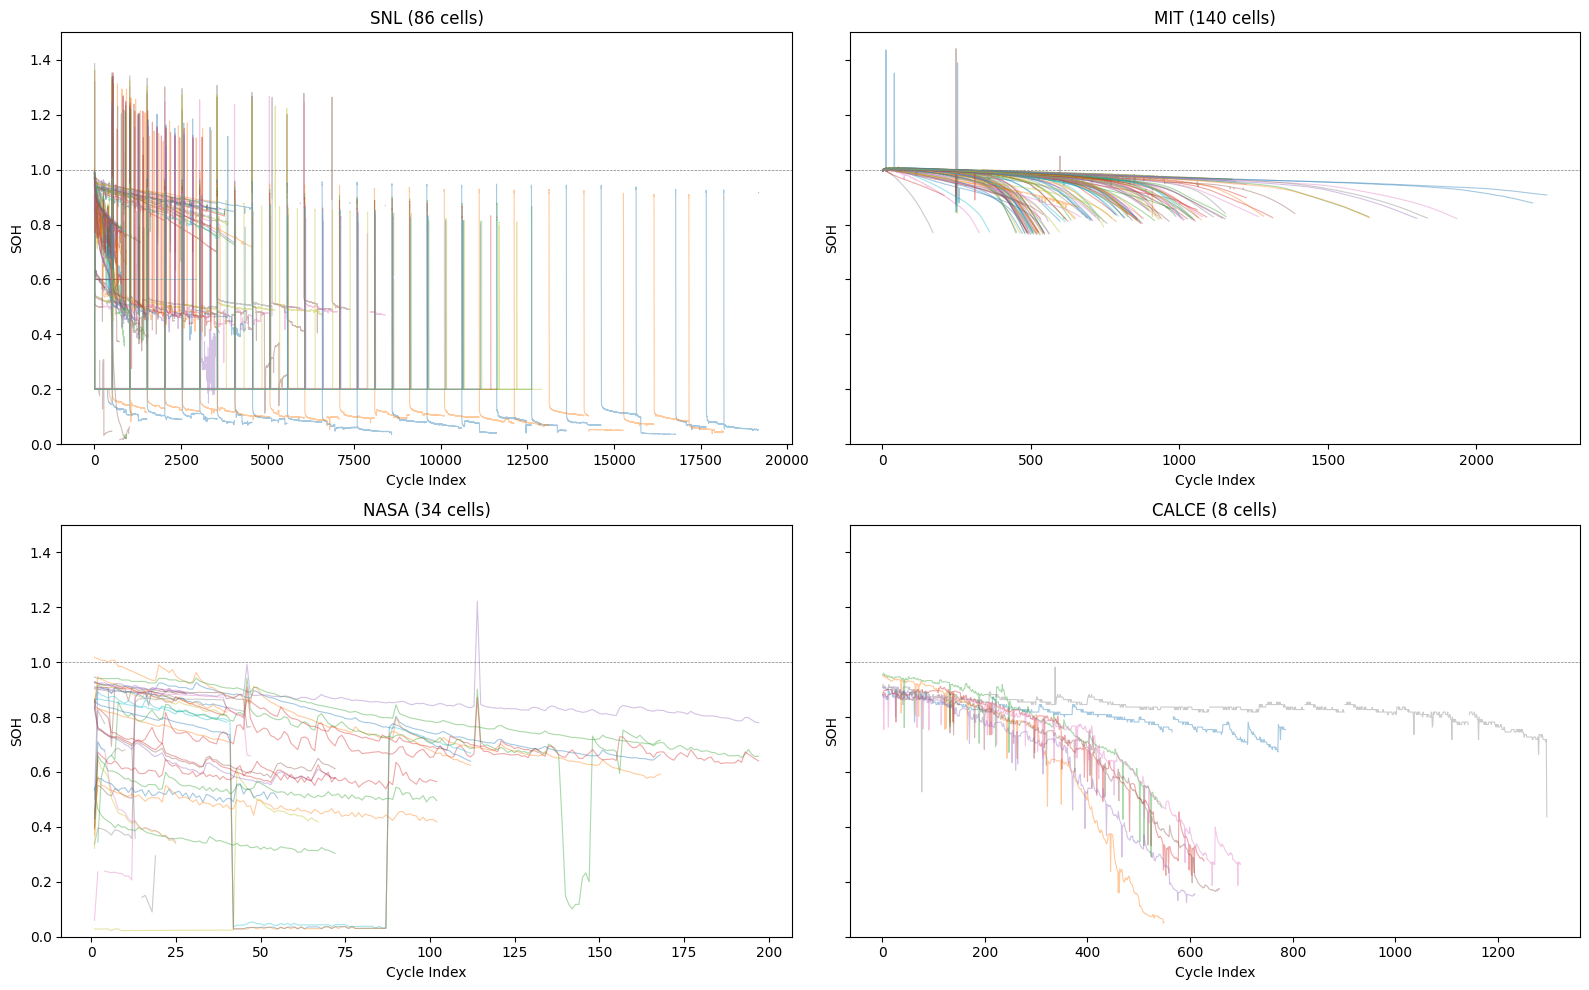

Saved plot to /kaggle/working/battery_data/fade_curves_by_source.png


In [74]:
# Cell 76: Fade-curve plot, all cells, colored by source

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=True)
sources = ['snl', 'mit', 'nasa', 'calce']

for ax, src in zip(axes.flat, sources):
    subset = merged_final2[merged_final2['source'] == src]
    for cell_id, group in subset.groupby('cell_id'):
        g = group.sort_values('cycle_index')
        ax.plot(g['cycle_index'], g['soh'], alpha=0.4, linewidth=0.8)
    ax.set_title(f"{src.upper()} ({subset['cell_id'].nunique()} cells)")
    ax.set_xlabel('Cycle Index')
    ax.set_ylabel('SOH')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/fade_curves_by_source.png', dpi=120)
plt.show()

print("Saved plot to /kaggle/working/battery_data/fade_curves_by_source.png")

In [75]:
# Cell 77: Identify and inspect both anomalies

# --- SNL flat-line cell ---
snl_data = merged_final2[merged_final2['source'] == 'snl']
# find cells with a long run of near-identical soh values
flat_candidates = []
for cid, g in snl_data.groupby('cell_id'):
    g = g.sort_values('cycle_index')
    soh_vals = g['soh'].dropna()
    if len(soh_vals) < 50:
        continue
    # check for long runs where consecutive soh values barely change
    diffs = soh_vals.diff().abs()
    flat_run = (diffs < 0.001).rolling(500, min_periods=500).sum()
    if flat_run.max() >= 500:
        flat_candidates.append((cid, flat_run.max()))

print("SNL cells with long flat SOH runs (500+ near-identical consecutive values):")
print(flat_candidates)

# --- NASA crash-and-recover cell ---
nasa_data = merged_final2[merged_final2['source'] == 'nasa']
crash_candidates = []
for cid, g in nasa_data.groupby('cell_id'):
    g = g.sort_values('cycle_index')
    if (g['soh'] < 0.1).any() and (g['soh'].iloc[-10:] > 0.5).any():
        crash_candidates.append(cid)

print("\nNASA cells with near-zero SOH followed by later recovery:")
print(crash_candidates)

SNL cells with long flat SOH runs (500+ near-identical consecutive values):
[('SNL_18650_LFP_15C_0-100_0.5/1C_a', 500.0), ('SNL_18650_LFP_25C_0-100_0.5/3C_a', 500.0), ('SNL_18650_LFP_25C_0-100_0.5/3C_b', 500.0), ('SNL_18650_LFP_25C_0-100_0.5/3C_d', 500.0), ('SNL_18650_LFP_25C_20-80_0.5/0.5C_d', 500.0), ('SNL_18650_LFP_25C_40-60_0.5/0.5C_a', 500.0), ('SNL_18650_LFP_25C_40-60_0.5/0.5C_b', 500.0), ('SNL_18650_LFP_25C_40-60_0.5/3C_a', 500.0), ('SNL_18650_LFP_25C_40-60_0.5/3C_b', 500.0), ('SNL_18650_NCA_25C_40-60_0.5/0.5C_a', 500.0), ('SNL_18650_NMC_25C_40-60_0.5/3C_a', 500.0)]

NASA cells with near-zero SOH followed by later recovery:
['NASA_B0039', 'NASA_B0042', 'NASA_B0043', 'NASA_B0044', 'NASA_B0050']


In [76]:
# Cell 78: Inspect one SNL flat-candidate and all NASA crash cells in detail

# --- SNL: check true flat-run length + actual values for one example ---
example_flat = 'SNL_18650_LFP_25C_40-60_0.5/0.5C_a'
g = snl_data[snl_data['cell_id'] == example_flat].sort_values('cycle_index')
print(f"=== {example_flat} ===")
print("Total cycles:", len(g))
print("SOH describe:", g['soh'].describe())
print("\nSOH values every 500 cycles:")
print(g.iloc[::500][['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())

# --- NASA: raw discharge capacity for one crash cell ---
example_crash = 'NASA_B0039'
gn = nasa_data[nasa_data['cell_id'] == example_crash].sort_values('cycle_index')
print(f"\n=== {example_crash} ===")
print(gn[['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())

=== SNL_18650_LFP_25C_40-60_0.5/0.5C_a ===
Total cycles: 19173
SOH describe: count    19121.000000
mean         0.089642
std          0.076904
min          0.035244
25%          0.065362
50%          0.081976
75%          0.097232
max          0.975732
Name: soh, dtype: float64

SOH values every 500 cycles:
        cycle_index  discharge_capacity_ah       soh
85948             1               1.070266  0.972969
86448           502                    NaN       NaN
86948          1002               0.117586  0.106896
87448          1502               0.100557  0.091415
87948          2002               0.114987  0.104533
88448          2502               0.099260  0.090236
88948          3002               0.122904  0.111731
89448          3502               0.102325  0.093023
89948          4002               0.087395  0.079450
90448          4502               0.086052  0.078229
90948          5002               0.104286  0.094805
91448          5502               0.080712  0.073375
91

In [77]:
# Cell 79: Fix restricted-SOC reference capacity + pull NASA's actual crash range

# --- Fix 1: scale reference capacity to SOC window for restricted-SOC cells ---
meta_soc_window = meta.set_index('cell_id').apply(
    lambda r: (r['max_soc'] - r['min_soc']) / 100.0, axis=1
).to_dict()

def get_reference_capacity_v2(group):
    source = group['source'].iloc[0]
    cell_id = group['cell_id'].iloc[0]
    if source == 'nasa':
        return 2.0
    elif source == 'snl':
        nameplate = meta_capacity_lookup.get(cell_id, np.nan)
        soc_fraction = meta_soc_window.get(cell_id, 1.0)  # defaults to full range if not found
        return nameplate * soc_fraction
    elif source == 'calce':
        return 1.1
    else:  # mit
        early = group.sort_values('cycle_index').head(5)['discharge_capacity_ah']
        return early.median()

# check the fix on our known example BEFORE applying it dataset-wide
test_ref = get_reference_capacity_v2(snl_data[snl_data['cell_id'] == example_flat])
print(f"New reference capacity for {example_flat} (40-60% window): {test_ref}")
print(f"Old reference capacity was: 1.1 (full nameplate, WRONG for this cell)")

test_soh_check = 0.117586 / test_ref
print(f"\nRecomputed SOH at cycle 1002 with corrected reference: {test_soh_check:.3f} (vs old: 0.107)")

# --- NASA: pull actual crash range ---
gn_full = nasa_data[nasa_data['cell_id'] == 'NASA_B0039'].sort_values('cycle_index')
print(f"\n=== NASA_B0039, cycles 35-95 (the actual crash region) ===")
print(gn_full[(gn_full['cycle_index'] >= 35) & (gn_full['cycle_index'] <= 95)][['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())

New reference capacity for SNL_18650_LFP_25C_40-60_0.5/0.5C_a (40-60% window): 0.22000000000000003
Old reference capacity was: 1.1 (full nameplate, WRONG for this cell)

Recomputed SOH at cycle 1002 with corrected reference: 0.534 (vs old: 0.107)

=== NASA_B0039, cycles 35-95 (the actual crash region) ===
        cycle_index  discharge_capacity_ah       soh
398580           35               1.751001  0.875500
398581           36               1.749606  0.874803
398582           37               1.747736  0.873868
398583           38               1.744423  0.872211
398584           39               1.743308  0.871654
398585           40               1.655669  0.827835
398586           41               1.642977  0.821488
398587           42               1.634382  0.817191
398588           43               1.626507  0.813253
398589           44               1.618866  0.809433
398590           45               1.611497  0.805748
398591           46               1.324081  0.662040
3985

In [78]:
# Cell 80: Apply corrected reference capacity dataset-wide, rebuild SOH; extend NASA range

merged_final2['reference_capacity_ah'] = merged_final2.groupby('cell_id', group_keys=False).apply(
    lambda g: pd.Series([get_reference_capacity_v2(g)] * len(g), index=g.index)
)
merged_final2['soh'] = merged_final2['discharge_capacity_ah'] / merged_final2['reference_capacity_ah']
merged_final2['soh_out_of_range_flag'] = merged_final2['soh'] > 1.05

print("Reference capacity by source (after fix):")
print(merged_final2.groupby('source')['reference_capacity_ah'].agg(['min', 'max', 'mean']))
print("\nRestricted-SOC cells reference capacity (should now vary, not all 1.1):")
print(merged_final2[merged_final2['is_restricted_soc']].groupby('cell_id')['reference_capacity_ah'].first())

print("\nFinal SOH distribution:")
print(merged_final2['soh'].describe())
print("\nRemaining out-of-range cells:", merged_final2[merged_final2['soh_out_of_range_flag']]['cell_id'].nunique())

# NASA extended range
nasa_data2 = merged_final2[merged_final2['source'] == 'nasa']
gn_full2 = nasa_data2[nasa_data2['cell_id'] == 'NASA_B0039'].sort_values('cycle_index')
print(f"\n=== NASA_B0039, cycles 45-100 ===")
print(gn_full2[(gn_full2['cycle_index'] >= 45) & (gn_full2['cycle_index'] <= 100)][['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())

Reference capacity by source (after fix):
             min       max      mean
source                              
calce   1.100000  1.100000  1.100000
mit     0.970876  1.096331  1.070173
nasa    2.000000  2.000000  2.000000
snl     0.220000  3.200000  1.005771

Restricted-SOC cells reference capacity (should now vary, not all 1.1):
cell_id
SNL_18650_LFP_25C_20-80_0.5/0.5C_a    0.66
SNL_18650_LFP_25C_20-80_0.5/0.5C_b    0.66
SNL_18650_LFP_25C_20-80_0.5/0.5C_c    0.66
SNL_18650_LFP_25C_20-80_0.5/0.5C_d    0.66
SNL_18650_LFP_25C_20-80_0.5/3C_a      0.66
SNL_18650_LFP_25C_40-60_0.5/0.5C_a    0.22
SNL_18650_LFP_25C_40-60_0.5/0.5C_b    0.22
SNL_18650_LFP_25C_40-60_0.5/3C_a      0.22
SNL_18650_LFP_25C_40-60_0.5/3C_b      0.22
SNL_18650_NCA_25C_20-80_0.5/0.5C_a    1.92
SNL_18650_NCA_25C_20-80_0.5/0.5C_b    1.92
SNL_18650_NCA_25C_20-80_0.5/0.5C_c    1.92
SNL_18650_NCA_25C_20-80_0.5/0.5C_d    1.92
SNL_18650_NCA_25C_40-60_0.5/0.5C_a    0.64
SNL_18650_NCA_25C_40-60_0.5/0.5C_b    0.64
SNL_18650_

/tmp/ipykernel_16/621752555.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2['reference_capacity_ah'] = merged_final2.groupby('cell_id', group_keys=False).apply(


In [79]:
# Cell 81: Find max cycle_index for each NASA crash candidate, locate the real crash cell

crash_candidates = ['NASA_B0039', 'NASA_B0042', 'NASA_B0043', 'NASA_B0044', 'NASA_B0050']

for cid in crash_candidates:
    g = nasa_data2[nasa_data2['cell_id'] == cid].sort_values('cycle_index')
    print(f"{cid}: {len(g)} cycles, range {g['cycle_index'].min()}-{g['cycle_index'].max()}, "
          f"min soh={g['soh'].min():.3f} at cycle {g.loc[g['soh'].idxmin(), 'cycle_index']}")

NASA_B0039: 47 cycles, range 1-47, min soh=0.060 at cycle 1
NASA_B0042: 111 cycles, range 1-112, min soh=0.031 at cycle 84
NASA_B0043: 111 cycles, range 1-112, min soh=0.028 at cycle 55
NASA_B0044: 111 cycles, range 1-112, min soh=0.028 at cycle 46
NASA_B0050: 20 cycles, range 1-21, min soh=0.090 at cycle 18


In [80]:
# Cell 82: Full trajectory for NASA_B0044 around the crash

g = nasa_data2[nasa_data2['cell_id'] == 'NASA_B0044'].sort_values('cycle_index')
print(g[(g['cycle_index'] >= 30) & (g['cycle_index'] <= 60)][['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())

        cycle_index  discharge_capacity_ah       soh
398957           30               1.484397  0.742199
398958           31               1.472532  0.736266
398959           32               1.466315  0.733157
398960           33               1.467130  0.733565
398961           34               1.459386  0.729693
398962           35               1.446790  0.723395
398963           36               1.439067  0.719533
398964           37               1.438989  0.719495
398965           38               1.438620  0.719310
398966           39               1.431341  0.715671
398967           40               1.422973  0.711487
398968           41               1.415015  0.707508
398969           42               0.057217  0.028609
398970           43               0.057359  0.028679
398971           44               0.057497  0.028748
398972           45               0.057631  0.028815
398973           46               0.055117  0.027558
398974           47               0.067408  0.

In [81]:
# Cell 83: Confirm same signature in B0042/B0043, then flag failure events across NASA

for cid in ['NASA_B0042', 'NASA_B0043']:
    g = nasa_data2[nasa_data2['cell_id'] == cid].sort_values('cycle_index')
    min_idx = g['soh'].idxmin()
    min_cycle = g.loc[min_idx, 'cycle_index']
    window = g[(g['cycle_index'] >= min_cycle - 5) & (g['cycle_index'] <= min_cycle + 5)]
    print(f"=== {cid} around its min SOH (cycle {min_cycle}) ===")
    print(window[['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())
    print()

# flag: any cell with a sudden >5x single-cycle drop that does NOT recover within 10 cycles
def flag_failure_event(group, col='discharge_capacity_ah', drop_ratio=5, recovery_window=10):
    group = group.sort_values('cycle_index').copy()
    prior = group[col].shift(1)
    sudden_drop = (prior / group[col]) > drop_ratio
    group['is_failure_event'] = False
    for idx in group[sudden_drop].index:
        pos = group.index.get_loc(idx)
        future_vals = group[col].iloc[pos:pos+recovery_window]
        if future_vals.max() < prior.loc[idx] * 0.5:  # never gets back above half the pre-drop value
            group.loc[idx:, 'is_failure_event'] = True  # mark from failure point onward
            break
    return group

merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_failure_event)
print("\nTotal rows flagged as post-failure-event:", merged_final2['is_failure_event'].sum())
print("Cells with a failure event:", merged_final2[merged_final2['is_failure_event']]['cell_id'].unique())

=== NASA_B0042 around its min SOH (cycle 84) ===
        cycle_index  discharge_capacity_ah       soh
398784           79               0.075324  0.037662
398785           80               0.075538  0.037769
398786           81               0.075843  0.037921
398787           82               0.075992  0.037996
398788           83               0.076217  0.038108
398789           84               0.062169  0.031085
398790           85               0.075982  0.037991
398791           86               0.062270  0.031135
398792           87               0.062594  0.031297
398793           88               1.437734  0.718867
398794           89               1.524602  0.762301

=== NASA_B0043 around its min SOH (cycle 55) ===
        cycle_index  discharge_capacity_ah       soh
398866           50               0.067996  0.033998
398867           51               0.068280  0.034140
398868           52               0.068446  0.034223
398869           53               0.068514  0.034257


/tmp/ipykernel_16/4228214098.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_failure_event)


In [82]:
# Cell 84: Check B0043 further out + confirm SNL false positives, then refine failure detection

g43 = nasa_data2[nasa_data2['cell_id'] == 'NASA_B0043'].sort_values('cycle_index')
print("=== NASA_B0043, cycles 55-112 (full remaining range) ===")
print(g43[g43['cycle_index'] >= 55][['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())

# confirm the 3 SNL "failures" are restricted-SOC RPT false positives
snl_failures = merged_final2[merged_final2['cell_id'].isin(
    ['SNL_18650_LFP_25C_20-80_0.5/0.5C_a', 'SNL_18650_LFP_25C_40-60_0.5/0.5C_a', 'SNL_18650_LFP_25C_40-60_0.5/0.5C_b']
)][['cell_id', 'is_restricted_soc']].drop_duplicates()
print("\nAre the 3 SNL 'failure' cells restricted-SOC?")
print(snl_failures)

=== NASA_B0043, cycles 55-112 (full remaining range) ===
        cycle_index  discharge_capacity_ah       soh
398871           55               0.056544  0.028272
398872           56               0.069184  0.034592
398873           57               0.059122  0.029561
398874           58               0.069561  0.034781
398875           59               0.070179  0.035089
398876           60               0.070281  0.035141
398877           61               0.057874  0.028937
398878           62               0.070566  0.035283
398879           63               0.057989  0.028995
398880           64               0.071293  0.035646
398881           65               0.071465  0.035733
398882           66               0.071625  0.035813
398883           67               0.071926  0.035963
398884           68               0.058840  0.029420
398885           69               0.072139  0.036069
398886           70               0.072318  0.036159
398887           71               0.059382

In [83]:
# Cell 85: Rebuild failure-event detection with recovery check, apply corrections

def flag_failure_and_dropout(group, col='discharge_capacity_ah', drop_ratio=5, recovery_window=20):
    group = group.sort_values('cycle_index').copy()
    group['is_failure_event'] = False
    group['is_transient_dropout'] = False
    
    if group['is_restricted_soc'].iloc[0]:
        return group  # skip restricted-SOC cells entirely, handled via is_rpt_row already
    
    prior = group[col].shift(1)
    sudden_drop = (prior / group[col]) > drop_ratio
    
    for idx in group[sudden_drop].index:
        pos = group.index.get_loc(idx)
        pre_drop_val = prior.loc[idx]
        future_vals = group[col].iloc[pos:pos+recovery_window]
        if future_vals.max() >= pre_drop_val * 0.7:
            # recovers -> transient dropout, mark just the low rows in this window as dropout
            recovery_pos = future_vals[future_vals >= pre_drop_val * 0.7].index[0]
            recovery_idx_pos = group.index.get_loc(recovery_pos)
            group.iloc[pos:recovery_idx_pos, group.columns.get_loc('is_transient_dropout')] = True
        else:
            # never recovers -> terminal failure, flag from this point onward
            group.loc[idx:, 'is_failure_event'] = True
            break
    return group

merged_final2 = merged_final2.drop(columns=['is_failure_event'], errors='ignore')
merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_failure_and_dropout)

print("Rows flagged is_failure_event (terminal):", merged_final2['is_failure_event'].sum())
print("Cells with terminal failure:", merged_final2[merged_final2['is_failure_event']]['cell_id'].unique())

print("\nRows flagged is_transient_dropout:", merged_final2['is_transient_dropout'].sum())
print("Cells with transient dropout:", merged_final2[merged_final2['is_transient_dropout']]['cell_id'].unique())

# null out capacity/energy for transient dropout rows (same treatment as earlier SNL dropouts)
for col in capacity_energy_cols:
    merged_final2.loc[merged_final2['is_transient_dropout'], col] = pd.NA
merged_final2['soh'] = merged_final2['discharge_capacity_ah'] / merged_final2['reference_capacity_ah']

print("\nFinal SOH describe:")
print(merged_final2['soh'].describe())

Rows flagged is_failure_event (terminal): 213
Cells with terminal failure: ['NASA_B0042' 'NASA_B0043' 'NASA_B0044']

Rows flagged is_transient_dropout: 0
Cells with transient dropout: []

Final SOH describe:
count    398556.000000
mean          0.886218
std           0.257246
min           0.020088
25%           0.832465
50%           0.927187
75%           1.000008
max           4.981535
Name: soh, dtype: float64


/tmp/ipykernel_16/1451025611.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_failure_and_dropout)


In [84]:
# Cell 86: Find true crash start point for B0042 and B0043

for cid in ['NASA_B0042', 'NASA_B0043']:
    g = merged_final2[merged_final2['cell_id'] == cid].sort_values('cycle_index')
    # find first cycle where discharge_capacity_ah drops below, say, 0.3 (well below normal range)
    crash_start = g[g['discharge_capacity_ah'] < 0.3]['cycle_index'].min()
    recovery_cycle = g[(g['cycle_index'] > crash_start) & (g['discharge_capacity_ah'] > 1.0)]['cycle_index'].min()
    print(f"{cid}: crash starts at cycle {crash_start}, recovers at cycle {recovery_cycle}, "
          f"gap = {recovery_cycle - crash_start} cycles")

NASA_B0042: crash starts at cycle 42, recovers at cycle 88, gap = 46 cycles
NASA_B0043: crash starts at cycle 42, recovers at cycle 88, gap = 46 cycles


In [85]:
# Cell 87: Re-run with sufficient recovery window

def flag_failure_and_dropout_v2(group, col='discharge_capacity_ah', drop_ratio=5, recovery_window=60):
    group = group.sort_values('cycle_index').copy()
    group['is_failure_event'] = False
    group['is_transient_dropout'] = False
    
    if group['is_restricted_soc'].iloc[0]:
        return group
    
    prior = group[col].shift(1)
    sudden_drop = (prior / group[col]) > drop_ratio
    
    for idx in group[sudden_drop].index:
        pos = group.index.get_loc(idx)
        pre_drop_val = prior.loc[idx]
        future_vals = group[col].iloc[pos:pos+recovery_window]
        if future_vals.max() >= pre_drop_val * 0.7:
            recovery_pos = future_vals[future_vals >= pre_drop_val * 0.7].index[0]
            recovery_idx_pos = group.index.get_loc(recovery_pos)
            group.iloc[pos:recovery_idx_pos, group.columns.get_loc('is_transient_dropout')] = True
        else:
            group.loc[idx:, 'is_failure_event'] = True
            break
    return group

merged_final2 = merged_final2.drop(columns=['is_failure_event', 'is_transient_dropout'], errors='ignore')
merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_failure_and_dropout_v2)

print("Rows flagged is_failure_event (terminal):", merged_final2['is_failure_event'].sum())
print("Cells with terminal failure:", merged_final2[merged_final2['is_failure_event']]['cell_id'].unique())

print("\nRows flagged is_transient_dropout:", merged_final2['is_transient_dropout'].sum())
print("Cells with transient dropout:", merged_final2[merged_final2['is_transient_dropout']]['cell_id'].unique())

for col in capacity_energy_cols:
    merged_final2.loc[merged_final2['is_transient_dropout'], col] = pd.NA
merged_final2['soh'] = merged_final2['discharge_capacity_ah'] / merged_final2['reference_capacity_ah']

print("\nFinal SOH describe:")
print(merged_final2['soh'].describe())
print("\nRemaining out-of-range cells (SOH>1.05):", merged_final2[merged_final2['soh']>1.05]['cell_id'].nunique())

Rows flagged is_failure_event (terminal): 0
Cells with terminal failure: []

Rows flagged is_transient_dropout: 138
Cells with transient dropout: ['NASA_B0042' 'NASA_B0043' 'NASA_B0044']

Final SOH describe:
count    398418.000000
mean          0.886513
std           0.256803
min           0.020088
25%           0.832560
50%           0.927262
75%           1.000008
max           4.981535
Name: soh, dtype: float64

Remaining out-of-range cells (SOH>1.05): 32


/tmp/ipykernel_16/2074548926.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_failure_and_dropout_v2)


In [86]:
# Cell 88: Full B0044 trajectory, cycles 40-112

g44 = merged_final2[merged_final2['cell_id'] == 'NASA_B0044'].sort_values('cycle_index')
print(g44[(g44['cycle_index'] >= 40) & (g44['cycle_index'] <= 112)][['cycle_index', 'discharge_capacity_ah', 'is_transient_dropout', 'soh']].to_string())

        cycle_index  discharge_capacity_ah  is_transient_dropout       soh
398967           40               1.422973                 False  0.711487
398968           41               1.415015                 False  0.707508
398969           42                    NaN                  True       NaN
398970           43                    NaN                  True       NaN
398971           44                    NaN                  True       NaN
398972           45                    NaN                  True       NaN
398973           46                    NaN                  True       NaN
398974           47                    NaN                  True       NaN
398975           48                    NaN                  True       NaN
398976           49                    NaN                  True       NaN
398977           50                    NaN                  True       NaN
398978           51                    NaN                  True       NaN
398979           52      

In [87]:
# Cell 89: Save the fully verified final dataset

merged_final2.to_csv('/kaggle/working/battery_data/unified_battery_dataset_cleaned.csv', index=False)

print("Saved:", merged_final2.shape)
print("\nCells per source:", merged_final2.groupby('source')['cell_id'].nunique().to_dict())
print("Total unique cells:", merged_final2['cell_id'].nunique())
print("\nFinal SOH describe:")
print(merged_final2['soh'].describe())
print("\nNull counts (deliberately nulled dropout/fault rows):")
print(merged_final2[['discharge_capacity_ah', 'soh']].isna().sum())
print("\nFlag column summary:")
for flag_col in ['high_spike_flag', 'low_dropout_flag', 'is_restricted_soc', 'is_rpt_row', 'is_transient_dropout']:
    print(f"  {flag_col}: {merged_final2[flag_col].sum()} rows")

Saved: (399750, 20)

Cells per source: {'calce': 8, 'mit': 140, 'nasa': 34, 'snl': 86}
Total unique cells: 268

Final SOH describe:
count    398418.000000
mean          0.886513
std           0.256803
min           0.020088
25%           0.832560
50%           0.927262
75%           1.000008
max           4.981535
Name: soh, dtype: float64

Null counts (deliberately nulled dropout/fault rows):
discharge_capacity_ah    1332
soh                      1332
dtype: int64

Flag column summary:
  high_spike_flag: 384 rows
  low_dropout_flag: 76 rows
  is_restricted_soc: 172877 rows
  is_rpt_row: 9 rows
  is_transient_dropout: 138 rows


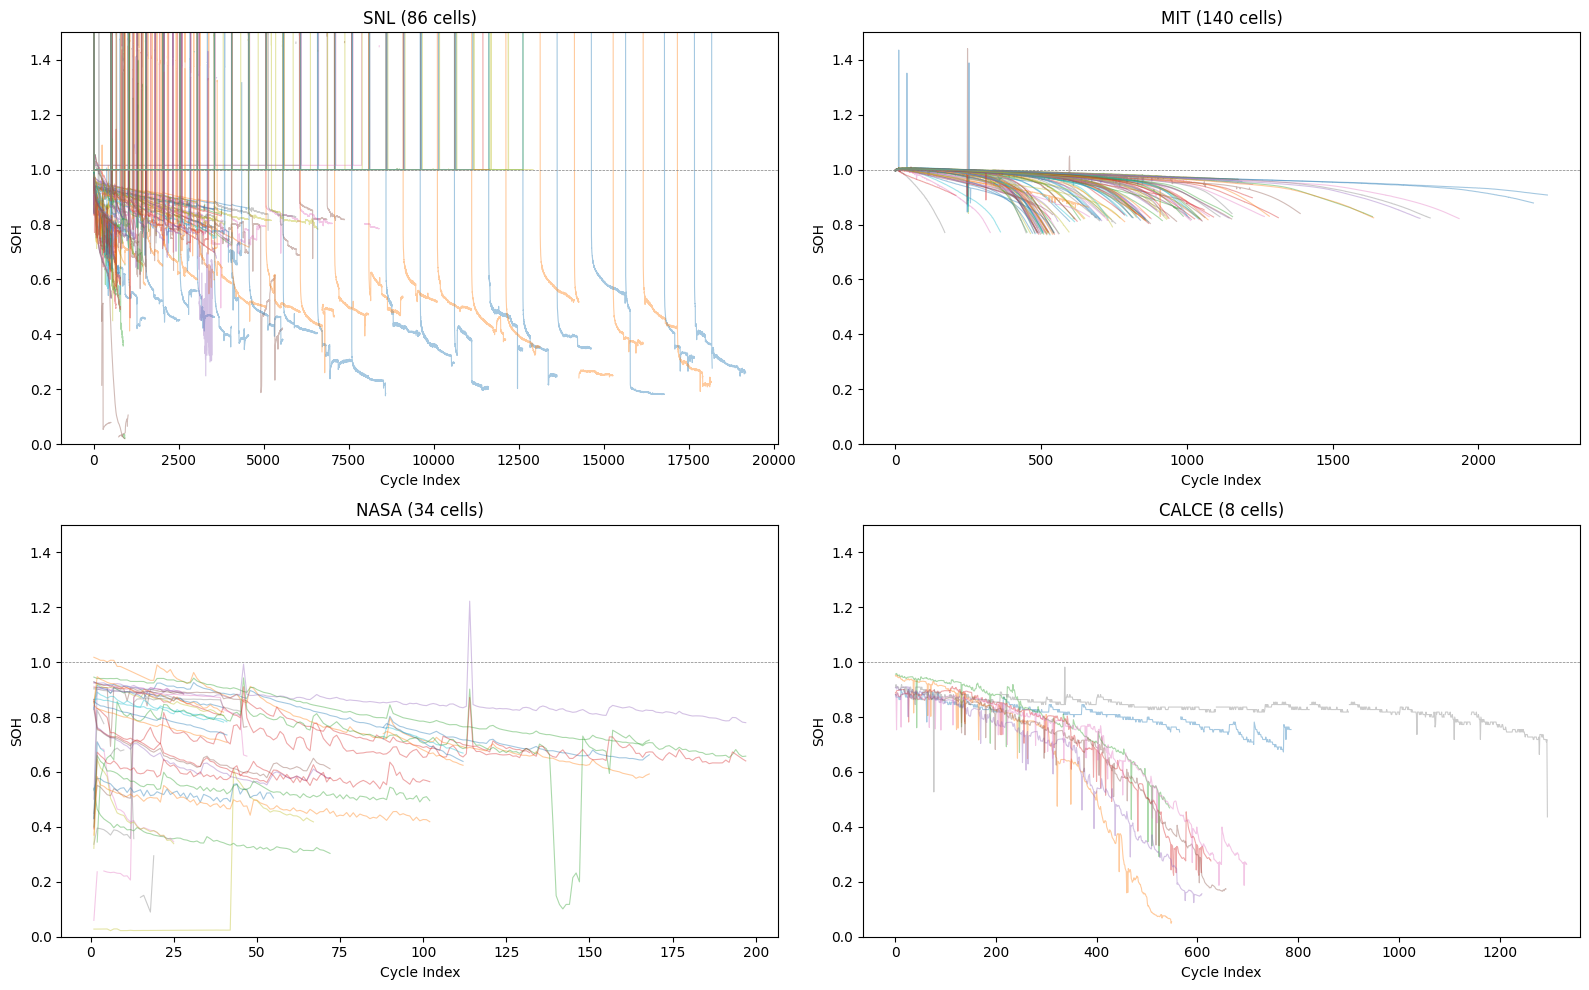

Saved to /kaggle/working/battery_data/fade_curves_final.png


In [88]:
# Cell 90: Final fade-curve plot

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sources = ['snl', 'mit', 'nasa', 'calce']

for ax, src in zip(axes.flat, sources):
    subset = merged_final2[merged_final2['source'] == src]
    for cell_id, group in subset.groupby('cell_id'):
        g = group.sort_values('cycle_index')
        ax.plot(g['cycle_index'], g['soh'], alpha=0.4, linewidth=0.8)
    ax.set_title(f"{src.upper()} ({subset['cell_id'].nunique()} cells)")
    ax.set_xlabel('Cycle Index')
    ax.set_ylabel('SOH')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/fade_curves_final.png', dpi=120)
plt.show()

print("Saved to /kaggle/working/battery_data/fade_curves_final.png")

In [89]:
# Cell 91: Systematic anomaly scan across ALL NASA cells (not just the ones we happened to spot)

nasa_final = merged_final2[merged_final2['source'] == 'nasa']

print("Per-cell SOH min/max, sorted by most extreme:")
nasa_summary = nasa_final.groupby('cell_id')['soh'].agg(['min', 'max', 'count']).sort_values('min')
print(nasa_summary.to_string())

Per-cell SOH min/max, sorted by most extreme:
                 min       max  count
cell_id                              
NASA_B0041  0.022046  0.607825     67
NASA_B0039  0.059519  0.885786     46
NASA_B0050  0.089783  0.824395     16
NASA_B0033  0.101282  0.942570    196
NASA_B0040  0.278495  0.867065     46
NASA_B0045  0.303474  0.540990     70
NASA_B0051  0.321737  0.646590     24
NASA_B0049  0.345694  0.710453     24
NASA_B0054  0.369968  0.583272    102
NASA_B0056  0.392639  0.672178    102
NASA_B0055  0.399500  0.659946    102
NASA_B0052  0.430330  0.709155      4
NASA_B0038  0.449029  0.893221     47
NASA_B0053  0.490067  0.577036     55
NASA_B0036  0.500991  1.222031    197
NASA_B0047  0.552989  0.837152     69
NASA_B0046  0.561856  0.864120     69
NASA_B0006  0.576909  1.017669    168
NASA_B0048  0.578841  0.828998     69
NASA_B0044  0.624313  0.843263     65
NASA_B0034  0.630253  0.910153    196
NASA_B0043  0.638390  0.856891     65
NASA_B0005  0.643726  0.928244    168
NASA

In [90]:
# Cell 92: Full trajectories for all 5 remaining problem cells

problem_cells = ['NASA_B0041', 'NASA_B0039', 'NASA_B0050', 'NASA_B0033', 'NASA_B0036']

for cid in problem_cells:
    g = nasa_final[nasa_final['cell_id'] == cid].sort_values('cycle_index')
    print(f"=== {cid} ({len(g)} cycles) ===")
    print(g[['cycle_index', 'discharge_capacity_ah', 'soh']].to_string())
    print()

=== NASA_B0041 (67 cycles) ===
        cycle_index  discharge_capacity_ah       soh
398640            1               0.055620  0.027810
398641            2               0.055697  0.027849
398642            3               0.055839  0.027920
398643            4               0.056148  0.028074
398644            5               0.056471  0.028235
398645            6               0.044092  0.022046
398646            7               0.056772  0.028386
398647            8               0.056938  0.028469
398648            9               0.044401  0.022201
398649           10               0.044634  0.022317
398650           11               0.044799  0.022399
398651           12               0.046709  0.023354
398652           13               0.044954  0.022477
398653           14               0.045219  0.022610
398654           15               0.045402  0.022701
398655           16               0.045679  0.022840
398656           17               0.045521  0.022760
398657         

In [91]:
# Cell 93: Fix early-invalid-startup pattern, lower drop threshold, flag B0050 as low-confidence

def flag_early_invalid(group, col='discharge_capacity_ah', check_cycles=10, jump_ratio=3):
    """If early cycles are anomalously low then jump up and stabilize, flag the low run as invalid."""
    group = group.sort_values('cycle_index').copy()
    group['is_early_invalid'] = False
    vals = group[col].values
    if len(vals) < check_cycles + 5:
        return group
    # compare first value to the median of cycles 10-20 (a stabilized-ish region)
    stabilized_ref = np.nanmedian(vals[check_cycles:check_cycles+10])
    if pd.isna(stabilized_ref) or stabilized_ref == 0:
        return group
    # walk forward from cycle 1, flag as invalid while value stays far below stabilized_ref
    for i in range(len(vals)):
        if pd.isna(vals[i]):
            continue
        if vals[i] < stabilized_ref / jump_ratio:
            group.iloc[i, group.columns.get_loc('is_early_invalid')] = True
        else:
            break  # stop at first cycle that's back in normal range
    return group

merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_early_invalid)
print("Rows flagged is_early_invalid:", merged_final2['is_early_invalid'].sum())
print("Cells affected:", merged_final2[merged_final2['is_early_invalid']]['cell_id'].unique())

# re-run dropout/failure detection with lower drop_ratio to catch B0033
merged_final2 = merged_final2.drop(columns=['is_failure_event', 'is_transient_dropout'], errors='ignore')
merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(
    lambda g: flag_failure_and_dropout_v2(g, drop_ratio=3.5, recovery_window=60))
print("\nis_transient_dropout after lowering threshold:", merged_final2['is_transient_dropout'].sum())
print("Cells:", merged_final2[merged_final2['is_transient_dropout']]['cell_id'].unique())
print("is_failure_event:", merged_final2['is_failure_event'].sum())

# flag B0050 as low-confidence entirely
merged_final2['is_low_confidence_cell'] = merged_final2['cell_id'] == 'NASA_B0050'

# apply nulling for early_invalid + transient_dropout
for col in capacity_energy_cols:
    merged_final2.loc[merged_final2['is_early_invalid'] | merged_final2['is_transient_dropout'], col] = pd.NA
merged_final2['soh'] = merged_final2['discharge_capacity_ah'] / merged_final2['reference_capacity_ah']

print("\nFinal SOH describe:")
print(merged_final2['soh'].describe())

/tmp/ipykernel_16/493154052.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_early_invalid)


Rows flagged is_early_invalid: 11
Cells affected: ['NASA_B0039']

is_transient_dropout after lowering threshold: 0
Cells: []
is_failure_event: 0

Final SOH describe:
count    398407.000000
mean          0.886531
std           0.256782
min           0.020088
25%           0.832566
50%           0.927267
75%           1.000008
max           4.981535
Name: soh, dtype: float64


/tmp/ipykernel_16/493154052.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(


In [92]:
# Cell 94: Full clean rebuild, all fixes applied once in correct order, from the ORIGINAL merged

# --- 0. Start fresh from original merged, ensure numeric dtypes ---
mf = merged.copy()
for col in capacity_energy_cols:
    if mf[col].dtype == object:
        mf[col] = pd.to_numeric(mf[col], errors='coerce')

# --- 1. Reference capacity (SOC-window-corrected) ---
mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: pd.Series([get_reference_capacity_v2(g)] * len(g), index=g.index))
mf['is_restricted_soc'] = mf['cell_id'].isin(restricted_soc_cells)

# --- 2. High-spike (doubling artifact) detection + halving, on RAW data only ---
mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
for col in capacity_energy_cols:
    mf.loc[mf['high_spike_flag'], col] = mf.loc[mf['high_spike_flag'], col] / 2

# --- 3. Absolute floor for near-zero (independent of rolling window) ---
abs_floor_mask = mf['discharge_capacity_ah'] < 0.01
for col in capacity_energy_cols:
    mf.loc[abs_floor_mask, col] = pd.NA
mf['low_dropout_flag'] = mf['low_dropout_flag'] | abs_floor_mask

# --- 4. RPT rows for restricted-SOC (flag only, no modification) ---
mf['is_rpt_row'] = mf['is_restricted_soc'] & mf['high_spike_flag']

# --- 5. Transient dropout / terminal failure (drop_ratio=3.5, on data with only steps 1-3 applied so far) ---
mf = mf.drop(columns=['is_failure_event', 'is_transient_dropout'], errors='ignore')
mf = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: flag_failure_and_dropout_v2(g, drop_ratio=3.5, recovery_window=60))
for col in capacity_energy_cols:
    mf.loc[mf['is_transient_dropout'], col] = pd.NA

# --- 6. Early-invalid-startup (formation cycles), computed AFTER step 5 so it sees clean data ---
mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)
for col in capacity_energy_cols:
    mf.loc[mf['is_early_invalid'], col] = pd.NA

# --- 7. Low-confidence cell flag ---
mf['is_low_confidence_cell'] = mf['cell_id'] == 'NASA_B0050'

# --- Final SOH ---
mf['soh'] = mf['discharge_capacity_ah'] / mf['reference_capacity_ah']
mf['soh_out_of_range_flag'] = mf['soh'] > 1.05

print("high_spike_flag:", mf['high_spike_flag'].sum())
print("low_dropout_flag:", mf['low_dropout_flag'].sum())
print("is_transient_dropout:", mf['is_transient_dropout'].sum(), 
      "cells:", mf[mf['is_transient_dropout']]['cell_id'].unique())
print("is_failure_event:", mf['is_failure_event'].sum())
print("is_early_invalid:", mf['is_early_invalid'].sum(), 
      "cells:", mf[mf['is_early_invalid']]['cell_id'].unique())
print("\nSOH describe:")
print(mf['soh'].describe())

merged_final2 = mf  # replace with the clean rebuild

/tmp/ipykernel_16/2015240614.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
/tmp/ipykernel_16/2015240614.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
/tmp/ipykernel_16/2015240614.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping colu

high_spike_flag: 384
low_dropout_flag: 80
is_transient_dropout: 192 cells: ['SNL_18650_NCA_15C_0-100_0.5/2C_a' 'SNL_18650_NCA_25C_0-100_0.5/0.5C_a'
 'NASA_B0042' 'NASA_B0043' 'NASA_B0044' 'NASA_B0050']
is_failure_event: 4
is_early_invalid: 13 cells: ['NASA_B0033' 'NASA_B0039']

SOH describe:
count    398384.000000
mean          0.886616
std           0.256706
min           0.020088
25%           0.832590
50%           0.927318
75%           1.000009
max           4.981535
Name: soh, dtype: float64


/tmp/ipykernel_16/2015240614.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)


In [93]:
# Cell 95: Verify new catches, check B0041 specifically

# which cells got is_failure_event?
print("is_failure_event cells:", merged_final2[merged_final2['is_failure_event']]['cell_id'].unique())

# check the two new SNL dropout cells - are they legit or false positives?
for cid in ['SNL_18650_NCA_15C_0-100_0.5/2C_a', 'SNL_18650_NCA_25C_0-100_0.5/0.5C_a']:
    dropout_rows = merged_final2[(merged_final2['cell_id']==cid) & (merged_final2['is_transient_dropout'])]
    print(f"\n{cid}: {len(dropout_rows)} dropout rows, cycles: {dropout_rows['cycle_index'].tolist()[:10]}")

# check B0033's early_invalid rows - are they actually early (cycle 1-10) or did it wrongly catch the mid-life dip?
b33 = merged_final2[merged_final2['cell_id']=='NASA_B0033'].sort_values('cycle_index')
print("\nB0033 is_early_invalid cycles:", b33[b33['is_early_invalid']]['cycle_index'].tolist())
print("B0033 cycles 139-150 (the REAL dip) - still needs handling?:")
print(b33[(b33['cycle_index']>=138) & (b33['cycle_index']<=149)][['cycle_index','discharge_capacity_ah','is_early_invalid','is_transient_dropout','soh']].to_string())

# B0041 - still broken?
b41 = merged_final2[merged_final2['cell_id']=='NASA_B0041'].sort_values('cycle_index')
print("\nB0041 SOH describe:", b41['soh'].describe())
print(b41[['cycle_index','discharge_capacity_ah','is_early_invalid','soh']].head(15).to_string())

is_failure_event cells: ['NASA_B0040' 'NASA_B0050']

SNL_18650_NCA_15C_0-100_0.5/2C_a: 47 dropout rows, cycles: [867, 868, 869, 870, 871, 872, 873, 874, 875, 876]

SNL_18650_NCA_25C_0-100_0.5/0.5C_a: 2 dropout rows, cycles: [93, 94]

B0033 is_early_invalid cycles: [1]
B0033 cycles 139-150 (the REAL dip) - still needs handling?:
        cycle_index  discharge_capacity_ah  is_early_invalid  is_transient_dropout       soh
398045          138               1.325319             False                 False  0.662660
398046          139               0.843968             False                 False  0.421984
398047          140               0.298662             False                 False  0.149331
398048          141               0.234487             False                 False  0.117243
398049          142               0.202563             False                 False  0.101282
398050          143               0.235320             False                 False  0.117660
398051          144

In [94]:
# Cell 96: Root-cause B0041 via reference_capacity + NASA README, then build a mid-life dip detector

import glob

# --- 1. Check B0041's assigned reference capacity vs. other NASA cells ---
b41_ref = merged_final2[merged_final2['cell_id']=='NASA_B0041']['reference_capacity_ah'].iloc[0]
print("B0041 reference_capacity_ah:", b41_ref)
print("\nReference capacity across all NASA cells (sorted):")
print(merged_final2[merged_final2['source']=='nasa'].groupby('cell_id')['reference_capacity_ah']
      .first().sort_values().to_string())

# --- 2. Check what NASA's own README files say about B0041's group ---
readme_files = glob.glob('/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/**/README*.txt', recursive=True)
print("\nREADME files found:", readme_files)
for rf in readme_files:
    with open(rf, 'r', errors='replace') as f:
        content = f.read()
    if 'B0041' in content or '41' in rf:
        print(f"\n--- {rf} ---")
        print(content[:1500])

# --- 3. Mid-life dip detector: multi-cycle sag that recovers, anywhere in the trajectory ---
def flag_midlife_dip(group, col='discharge_capacity_ah', window=5, dip_ratio=2.5):
    """Flag a run of cycles where capacity sags well below the trailing baseline 
    and later recovers -- catches sags like B0033's cycles 140-147 that neither 
    the early-invalid nor single-spike dropout detectors catch."""
    group = group.sort_values('cycle_index').copy()
    group['is_midlife_dip'] = False
    vals = group[col].to_numpy(dtype=float)
    n = len(vals)
    for i in range(window, n - window):
        if np.isnan(vals[i]):
            continue
        baseline = np.nanmedian(vals[max(0, i-window):i])
        if pd.isna(baseline) or baseline == 0:
            continue
        if vals[i] < baseline / dip_ratio:
            group.iloc[i, group.columns.get_loc('is_midlife_dip')] = True
    return group

b33_test = flag_midlife_dip(merged_final2[merged_final2['cell_id']=='NASA_B0033'])
print("\nB0033 midlife_dip flagged cycles:", 
      b33_test[b33_test['is_midlife_dip']]['cycle_index'].tolist())

B0041 reference_capacity_ah: 2.0

Reference capacity across all NASA cells (sorted):
cell_id
NASA_B0005    2.0
NASA_B0006    2.0
NASA_B0007    2.0
NASA_B0018    2.0
NASA_B0025    2.0
NASA_B0026    2.0
NASA_B0027    2.0
NASA_B0028    2.0
NASA_B0029    2.0
NASA_B0030    2.0
NASA_B0031    2.0
NASA_B0032    2.0
NASA_B0033    2.0
NASA_B0034    2.0
NASA_B0036    2.0
NASA_B0038    2.0
NASA_B0039    2.0
NASA_B0040    2.0
NASA_B0041    2.0
NASA_B0042    2.0
NASA_B0043    2.0
NASA_B0044    2.0
NASA_B0045    2.0
NASA_B0046    2.0
NASA_B0047    2.0
NASA_B0048    2.0
NASA_B0049    2.0
NASA_B0050    2.0
NASA_B0051    2.0
NASA_B0052    2.0
NASA_B0053    2.0
NASA_B0054    2.0
NASA_B0055    2.0
NASA_B0056    2.0

README files found: ['/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README_49_50_51_52.txt', '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README_45_46_47_48.txt', '/kaggle/input/

In [95]:
# Cell 98: Fix cell_id retention + silence all-NaN baseline warning, re-run full NASA scan

def flag_midlife_dip(group, col='discharge_capacity_ah', window=5, dip_ratio=2.0):
    group = group.sort_values('cycle_index').copy()
    group['is_midlife_dip'] = False
    vals = group[col].to_numpy(dtype=float)
    n = len(vals)
    for i in range(window, n - window):
        if np.isnan(vals[i]):
            continue
        window_vals = vals[max(0, i-window):i]
        if np.all(np.isnan(window_vals)):
            continue  # explicit guard -- skip instead of letting nanmedian warn
        baseline = np.nanmedian(window_vals)
        if baseline == 0:
            continue
        if vals[i] < baseline / dip_ratio:
            group.iloc[i, group.columns.get_loc('is_midlife_dip')] = True
    return group

# don't use include_groups=False -- keep cell_id in the group so it survives into the result
nasa_dip_test = (merged_final2[merged_final2['source']=='nasa']
                  .groupby('cell_id', group_keys=False)
                  .apply(flag_midlife_dip))

print("cell_id present in result:", 'cell_id' in nasa_dip_test.columns)

dip_counts = nasa_dip_test[nasa_dip_test['is_midlife_dip']].groupby('cell_id').size().sort_values(ascending=False)
print("\nMidlife dip flags per cell (all NASA cells):")
print(dip_counts)
print("\nTotal cells affected:", len(dip_counts), "out of", 
      merged_final2[merged_final2['source']=='nasa']['cell_id'].nunique())

print("\nB0033 flagged cycles (sanity re-check):", 
      nasa_dip_test[(nasa_dip_test['cell_id']=='NASA_B0033') & (nasa_dip_test['is_midlife_dip'])]['cycle_index'].tolist())

cell_id present in result: True

Midlife dip flags per cell (all NASA cells):
cell_id
NASA_B0033    3
NASA_B0050    1
dtype: int64

Total cells affected: 2 out of 34

B0033 flagged cycles (sanity re-check): [140, 141, 142]


/tmp/ipykernel_16/1797693999.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(flag_midlife_dip))


In [96]:
# Cell 99: FINAL clean rebuild -- all 8 correction steps, correct order, from the untouched original

mf = merged.copy()
for col in capacity_energy_cols:
    if mf[col].dtype == object:
        mf[col] = pd.to_numeric(mf[col], errors='coerce')

# 1. Reference capacity
mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: pd.Series([get_reference_capacity_v2(g)] * len(g), index=g.index))
mf['is_restricted_soc'] = mf['cell_id'].isin(restricted_soc_cells)

# 2. High-spike (doubling artifact) halving
mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
for col in capacity_energy_cols:
    mf.loc[mf['high_spike_flag'], col] = mf.loc[mf['high_spike_flag'], col] / 2

# 3. Absolute near-zero floor
abs_floor_mask = mf['discharge_capacity_ah'] < 0.01
for col in capacity_energy_cols:
    mf.loc[abs_floor_mask, col] = pd.NA
mf['low_dropout_flag'] = mf['low_dropout_flag'] | abs_floor_mask

# 4. RPT rows (flag only)
mf['is_rpt_row'] = mf['is_restricted_soc'] & mf['high_spike_flag']

# 5. Transient dropout / terminal failure
mf = mf.drop(columns=['is_failure_event', 'is_transient_dropout'], errors='ignore')
mf = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: flag_failure_and_dropout_v2(g, drop_ratio=3.5, recovery_window=60))
for col in capacity_energy_cols:
    mf.loc[mf['is_transient_dropout'], col] = pd.NA

# 5.5 NEW: Midlife dip (multi-cycle sag with recovery, e.g. B0033)
mf = mf.groupby('cell_id', group_keys=False).apply(flag_midlife_dip)
for col in capacity_energy_cols:
    mf.loc[mf['is_midlife_dip'], col] = pd.NA

# 6. Early-invalid startup (sees clean data from steps 1-5.5)
mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)
for col in capacity_energy_cols:
    mf.loc[mf['is_early_invalid'], col] = pd.NA

# 7. Low-confidence cell flag (documented, unexplained low-capacity: NASA README)
mf['is_low_confidence_cell'] = mf['cell_id'].isin(['NASA_B0050', 'NASA_B0041'])

# 8. Final SOH
mf['soh'] = mf['discharge_capacity_ah'] / mf['reference_capacity_ah']
mf['soh_out_of_range_flag'] = mf['soh'] > 1.05

merged_final3 = mf

print("high_spike_flag:", merged_final3['high_spike_flag'].sum())
print("low_dropout_flag:", merged_final3['low_dropout_flag'].sum())
print("is_transient_dropout:", merged_final3['is_transient_dropout'].sum(),
      merged_final3[merged_final3['is_transient_dropout']]['cell_id'].unique())
print("is_midlife_dip:", merged_final3['is_midlife_dip'].sum(),
      merged_final3[merged_final3['is_midlife_dip']]['cell_id'].unique())
print("is_early_invalid:", merged_final3['is_early_invalid'].sum(),
      merged_final3[merged_final3['is_early_invalid']]['cell_id'].unique())
print("is_failure_event:", merged_final3['is_failure_event'].sum())
print("is_low_confidence_cell rows:", merged_final3['is_low_confidence_cell'].sum())
print("\nFinal SOH describe:")
print(merged_final3['soh'].describe())

/tmp/ipykernel_16/795595737.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
/tmp/ipykernel_16/795595737.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
/tmp/ipykernel_16/795595737.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns.

high_spike_flag: 384
low_dropout_flag: 80
is_transient_dropout: 192 ['SNL_18650_NCA_15C_0-100_0.5/2C_a' 'SNL_18650_NCA_25C_0-100_0.5/0.5C_a'
 'NASA_B0042' 'NASA_B0043' 'NASA_B0044' 'NASA_B0050']
is_midlife_dip: 634 ['SNL_18650_LFP_25C_20-80_0.5/0.5C_a' 'SNL_18650_LFP_25C_20-80_0.5/0.5C_d'
 'SNL_18650_LFP_25C_40-60_0.5/0.5C_a' 'SNL_18650_LFP_25C_40-60_0.5/0.5C_b'
 'SNL_18650_LFP_25C_40-60_0.5/3C_a' 'SNL_18650_LFP_25C_40-60_0.5/3C_b'
 'SNL_18650_NCA_25C_40-60_0.5/0.5C_a' 'SNL_18650_NCA_25C_40-60_0.5/0.5C_b'
 'SNL_18650_NMC_25C_20-80_0.5/0.5C_c' 'SNL_18650_NMC_25C_20-80_0.5/3C_a'
 'SNL_18650_NMC_25C_40-60_0.5/0.5C_a' 'SNL_18650_NMC_25C_40-60_0.5/0.5C_b'
 'SNL_18650_NMC_25C_40-60_0.5/3C_a' 'SNL_18650_NMC_25C_40-60_0.5/3C_b'
 'NASA_B0033' 'NASA_B0050']
is_early_invalid: 13 ['NASA_B0033' 'NASA_B0039']
is_failure_event: 4
is_low_confidence_cell rows: 87

Final SOH describe:
count    397750.000000
mean          0.886596
std           0.256777
min           0.020088
25%           0.832578
50%  

/tmp/ipykernel_16/795595737.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)


In [97]:
# Cell 100: Restrict midlife_dip to non-restricted-SOC cells only, rebuild once more

def flag_midlife_dip(group, col='discharge_capacity_ah', window=5, dip_ratio=2.0):
    group = group.sort_values('cycle_index').copy()
    group['is_midlife_dip'] = False
    # skip entirely for restricted-SOC cells -- their capacity swings are RPT-driven, not anomalies
    if group['is_restricted_soc'].iloc[0]:
        return group
    vals = group[col].to_numpy(dtype=float)
    n = len(vals)
    for i in range(window, n - window):
        if np.isnan(vals[i]):
            continue
        window_vals = vals[max(0, i-window):i]
        if np.all(np.isnan(window_vals)):
            continue
        baseline = np.nanmedian(window_vals)
        if baseline == 0:
            continue
        if vals[i] < baseline / dip_ratio:
            group.iloc[i, group.columns.get_loc('is_midlife_dip')] = True
    return group

mf = merged.copy()
for col in capacity_energy_cols:
    if mf[col].dtype == object:
        mf[col] = pd.to_numeric(mf[col], errors='coerce')

mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: pd.Series([get_reference_capacity_v2(g)] * len(g), index=g.index))
mf['is_restricted_soc'] = mf['cell_id'].isin(restricted_soc_cells)

mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
for col in capacity_energy_cols:
    mf.loc[mf['high_spike_flag'], col] = mf.loc[mf['high_spike_flag'], col] / 2

abs_floor_mask = mf['discharge_capacity_ah'] < 0.01
for col in capacity_energy_cols:
    mf.loc[abs_floor_mask, col] = pd.NA
mf['low_dropout_flag'] = mf['low_dropout_flag'] | abs_floor_mask

mf['is_rpt_row'] = mf['is_restricted_soc'] & mf['high_spike_flag']

mf = mf.drop(columns=['is_failure_event', 'is_transient_dropout'], errors='ignore')
mf = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: flag_failure_and_dropout_v2(g, drop_ratio=3.5, recovery_window=60))
for col in capacity_energy_cols:
    mf.loc[mf['is_transient_dropout'], col] = pd.NA

# midlife dip -- now skips restricted-SOC cells internally
mf = mf.groupby('cell_id', group_keys=False).apply(flag_midlife_dip)
for col in capacity_energy_cols:
    mf.loc[mf['is_midlife_dip'], col] = pd.NA

mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)
for col in capacity_energy_cols:
    mf.loc[mf['is_early_invalid'], col] = pd.NA

mf['is_low_confidence_cell'] = mf['cell_id'].isin(['NASA_B0050', 'NASA_B0041'])

mf['soh'] = mf['discharge_capacity_ah'] / mf['reference_capacity_ah']
mf['soh_out_of_range_flag'] = mf['soh'] > 1.05

merged_final3 = mf

print("is_midlife_dip:", merged_final3['is_midlife_dip'].sum(),
      merged_final3[merged_final3['is_midlife_dip']]['cell_id'].unique())
print("is_transient_dropout:", merged_final3['is_transient_dropout'].sum())
print("is_early_invalid:", merged_final3['is_early_invalid'].sum())
print("is_failure_event:", merged_final3['is_failure_event'].sum())
print("\nFinal SOH describe:")
print(merged_final3['soh'].describe())

/tmp/ipykernel_16/3332608556.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
/tmp/ipykernel_16/3332608556.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
/tmp/ipykernel_16/3332608556.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping colu

is_midlife_dip: 4 ['NASA_B0033' 'NASA_B0050']
is_transient_dropout: 192
is_early_invalid: 13
is_failure_event: 4

Final SOH describe:
count    398380.000000
mean          0.886623
std           0.256697
min           0.020088
25%           0.832594
50%           0.927318
75%           1.000009
max           4.981535
Name: soh, dtype: float64


/tmp/ipykernel_16/3332608556.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)


Saved: merged_soh_final.csv, shape: (399750, 23)


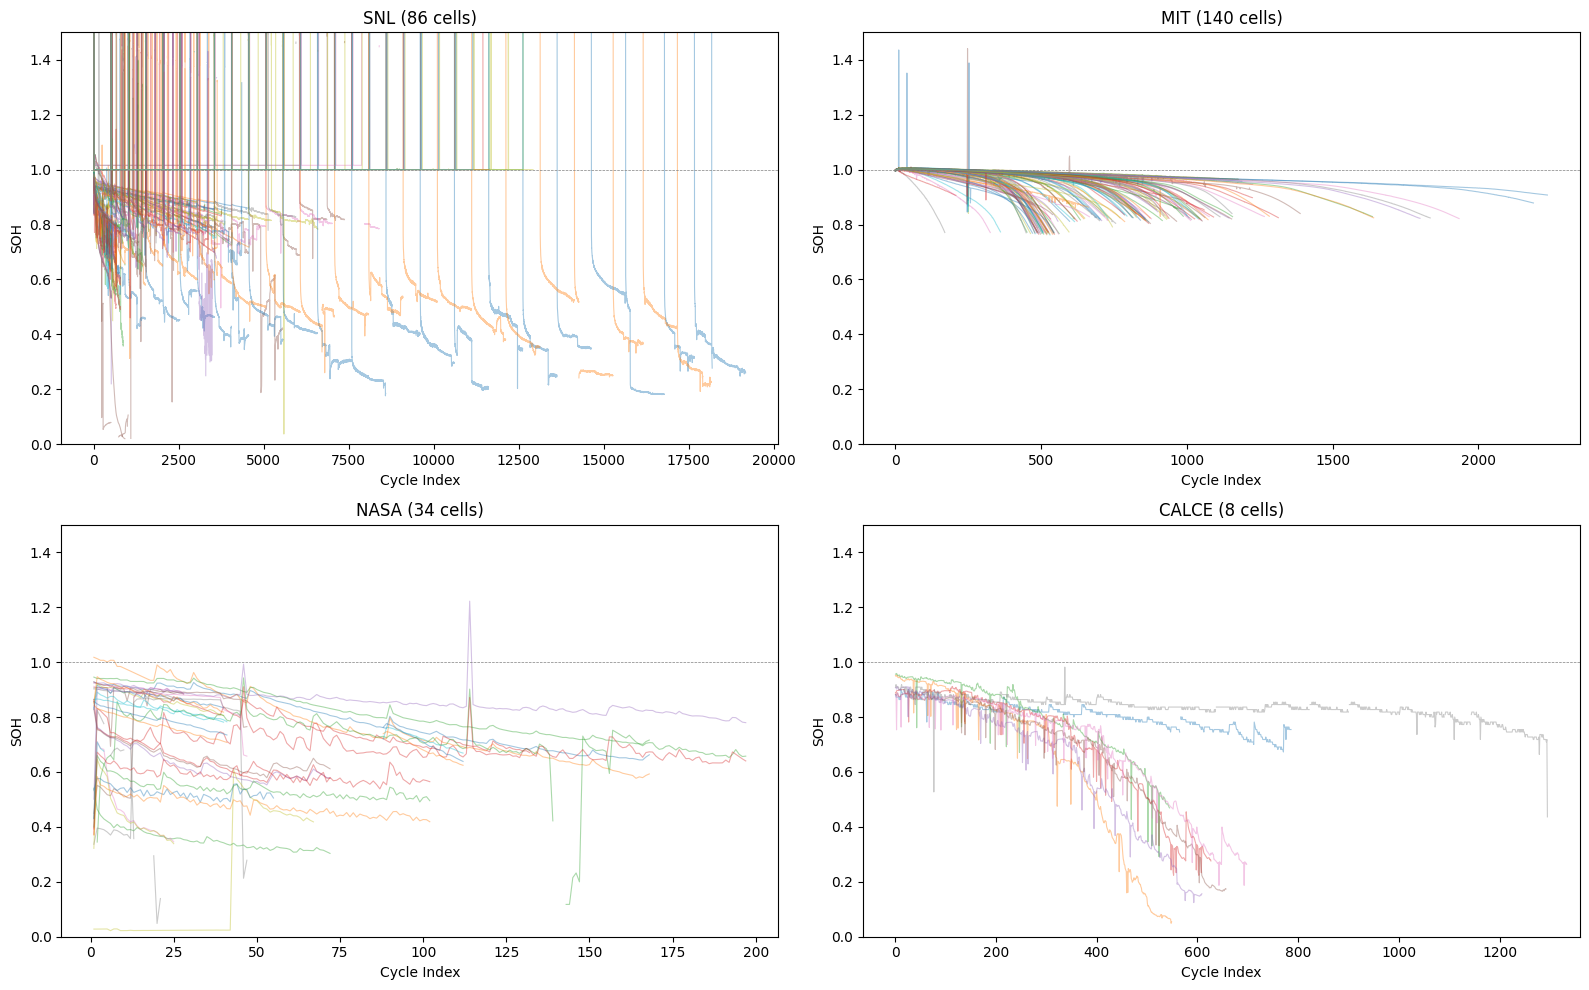


=== Data quality summary ===
                  flag  rows_flagged  cells_affected
       high_spike_flag           384              72
      low_dropout_flag            80              66
            is_rpt_row             9               8
  is_transient_dropout           192               6
        is_midlife_dip             4               2
      is_early_invalid            13               2
      is_failure_event             4               2
is_low_confidence_cell            87               2
 soh_out_of_range_flag          2158              32

=== Final dataset overview ===
Total rows: 399750
Total cells: 268
Rows with valid (non-null) discharge_capacity_ah: 398380

By source:
        cells    rows
source               
calce       8    5766
mit       140  114738
nasa       34    2750
snl        86  276496


In [98]:
# Cell 101: Save final dataset, re-plot fade curves, and produce a data-quality summary table

import os
os.makedirs('/kaggle/working/battery_data', exist_ok=True)
merged_final3.to_csv('/kaggle/working/battery_data/merged_soh_final.csv', index=False)
print("Saved: merged_soh_final.csv, shape:", merged_final3.shape)

# --- Re-plot fade curves (same layout as before, now on merged_final3) ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sources = ['snl', 'mit', 'nasa', 'calce']

for ax, src in zip(axes.flat, sources):
    subset = merged_final3[merged_final3['source'] == src]
    for cell_id, group in subset.groupby('cell_id'):
        g = group.sort_values('cycle_index')
        ax.plot(g['cycle_index'], g['soh'], alpha=0.4, linewidth=0.8)
    ax.set_title(f"{src.upper()} ({subset['cell_id'].nunique()} cells)")
    ax.set_xlabel('Cycle Index')
    ax.set_ylabel('SOH')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/fade_curves_v2.png', dpi=120)
plt.show()

# --- Data-quality summary table ---
flag_cols = ['high_spike_flag', 'low_dropout_flag', 'is_rpt_row', 'is_transient_dropout',
             'is_midlife_dip', 'is_early_invalid', 'is_failure_event', 'is_low_confidence_cell',
             'soh_out_of_range_flag']

summary_rows = []
for col in flag_cols:
    n_rows = merged_final3[col].sum()
    n_cells = merged_final3[merged_final3[col]]['cell_id'].nunique()
    summary_rows.append({'flag': col, 'rows_flagged': n_rows, 'cells_affected': n_cells})

quality_summary = pd.DataFrame(summary_rows)
print("\n=== Data quality summary ===")
print(quality_summary.to_string(index=False))
quality_summary.to_csv('/kaggle/working/battery_data/data_quality_summary.csv', index=False)

print("\n=== Final dataset overview ===")
print("Total rows:", len(merged_final3))
print("Total cells:", merged_final3['cell_id'].nunique())
print("Rows with valid (non-null) discharge_capacity_ah:", merged_final3['discharge_capacity_ah'].notna().sum())
print("\nBy source:")
print(merged_final3.groupby('source').agg(cells=('cell_id', 'nunique'), rows=('cell_id', 'size')))

In [99]:
# Cell 102: Investigate soh_out_of_range_flag rows before deciding how to handle them

oor = merged_final3[merged_final3['soh_out_of_range_flag']]

print("Cells affected:", oor['cell_id'].nunique(), "out of", merged_final3['cell_id'].nunique())
print("\nRows per cell (top 15):")
print(oor.groupby('cell_id').size().sort_values(ascending=False).head(15))

print("\nBy source:")
print(oor.groupby('source').agg(rows=('cell_id', 'size'), cells=('cell_id', 'nunique')))

print("\nSOH distribution among out-of-range rows:")
print(oor['soh'].describe())
print("\nWorst 10 offenders:")
print(oor.nlargest(10, 'soh')[['cell_id', 'cycle_index', 'discharge_capacity_ah', 'reference_capacity_ah', 'soh']])

# check if these overlap with already-known flags (RPT, restricted-SOC) or are something new
print("\nOverlap with is_rpt_row:", (oor['is_rpt_row']).sum(), "/", len(oor))
print("Overlap with is_restricted_soc:", (oor['is_restricted_soc']).sum(), "/", len(oor))
print("Overlap with high_spike_flag:", (oor['high_spike_flag']).sum(), "/", len(oor))

# is it periodic? check cycle-index gaps within a single heavily-affected cell
worst_cell = oor.groupby('cell_id').size().idxmax()
worst_cell_cycles = merged_final3[(merged_final3['cell_id']==worst_cell) & 
                                    (merged_final3['soh_out_of_range_flag'])]['cycle_index'].sort_values()
print(f"\n{worst_cell}: out-of-range cycle indices:", worst_cell_cycles.tolist())
print("Gaps between consecutive flagged cycles:", worst_cell_cycles.diff().dropna().tolist())

Cells affected: 32 out of 268

Rows per cell (top 15):
cell_id
SNL_18650_NMC_25C_40-60_0.5/3C_a      176
SNL_18650_LFP_25C_40-60_0.5/0.5C_a    144
SNL_18650_NMC_25C_40-60_0.5/0.5C_a    139
SNL_18650_NMC_25C_20-80_0.5/0.5C_b    135
SNL_18650_NMC_25C_40-60_0.5/3C_b      135
SNL_18650_LFP_25C_40-60_0.5/0.5C_b    132
SNL_18650_LFP_25C_40-60_0.5/3C_a      115
SNL_18650_LFP_25C_40-60_0.5/3C_b      111
SNL_18650_NMC_25C_40-60_0.5/0.5C_b    108
SNL_18650_NMC_25C_20-80_0.5/0.5C_d    107
SNL_18650_NMC_25C_20-80_0.5/0.5C_a     98
SNL_18650_NCA_25C_40-60_0.5/0.5C_a     97
SNL_18650_NMC_25C_20-80_0.5/3C_a       86
SNL_18650_NCA_25C_40-60_0.5/0.5C_b     73
SNL_18650_LFP_25C_20-80_0.5/0.5C_a     62
dtype: int64

By source:
        rows  cells
source             
mit        4      4
nasa       1      1
snl     2153     27

SOH distribution among out-of-range rows:
count    2158.000000
mean        3.057898
std         1.425916
min         1.050079
25%         1.478606
50%         3.046893
75%         4

In [100]:
# Cell 104: Find the real metadata variable name, then fix reference capacity logic

# meta_capacity_lookup already works inside the function -- find what it's built from
import sys
candidates = [name for name, val in list(globals().items()) 
              if 'meta' in name.lower() and not name.startswith('_')]
print("Candidate metadata-related variable names in scope:", candidates)

for name in candidates:
    obj = globals()[name]
    print(f"\n--- {name} ({type(obj)}) ---")
    if hasattr(obj, 'columns'):
        print("columns:", obj.columns.tolist())
        print(obj.head(3))
    elif isinstance(obj, dict):
        print("sample items:", list(obj.items())[:5])

Candidate metadata-related variable names in scope: ['meta', 'nasa_meta', 'snl_meta_lookup', 'meta_capacity_lookup', 'meta_soc_window']

--- meta (<class 'pandas.core.frame.DataFrame'>) ---
columns: ['cell_id', 'study', 'cathode', 'anode', 'temperature', 'min_soc', 'max_soc', 'charge_crate', 'discharge_crate', 'capacity_ah', 'form_factor']
                                       cell_id  study cathode     anode  \
0  CALCE_CX2-16_prism_LCO_25C_0-100_0.5/0.5C_a  calce     LCO  graphite   
1  CALCE_CX2-25_prism_LCO_25C_0-100_0.5/0.5C_b  calce     LCO  graphite   
2  CALCE_CX2-33_prism_LCO_25C_0-100_0.5/0.5C_d  calce     LCO  graphite   

   temperature  min_soc  max_soc  charge_crate  discharge_crate  capacity_ah  \
0           25      0.0    100.0           0.5              0.5         1.35   
1           25      0.0    100.0           0.5              0.5         1.35   
2           25      0.0    100.0           0.5              0.5         1.35   

  form_factor  
0   prismatic  
1   

In [101]:
# Cell 105: Corrected reference capacity function, then final full pipeline rebuild

def get_reference_capacity_v3(group):
    """True nameplate capacity for ALL rows, regardless of restricted-SOC cycling.
    RPT full-range discharges and restricted-window cycling both get compared 
    against the same true reference -- is_restricted_soc/is_rpt_row remain as 
    separate flags for anyone who wants to interpret windowed-vs-RPT differently."""
    source = group['source'].iloc[0]
    cell_id = group['cell_id'].iloc[0]
    if source == 'nasa':
        return 2.0
    elif source == 'snl':
        return meta_capacity_lookup.get(cell_id, np.nan)  # nameplate directly, no soc_fraction
    elif source == 'calce':
        return 1.1
    else:  # mit
        early = group.sort_values('cycle_index').head(5)['discharge_capacity_ah']
        return early.median()

# --- FINAL full rebuild, same 8 steps, only reference-capacity function changed ---
mf = merged.copy()
for col in capacity_energy_cols:
    if mf[col].dtype == object:
        mf[col] = pd.to_numeric(mf[col], errors='coerce')

mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: pd.Series([get_reference_capacity_v3(g)] * len(g), index=g.index))
mf['is_restricted_soc'] = mf['cell_id'].isin(restricted_soc_cells)
mf['windowed_capacity_ah'] = mf['reference_capacity_ah'] * mf['cell_id'].map(meta_soc_window).fillna(1.0)

mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
for col in capacity_energy_cols:
    mf.loc[mf['high_spike_flag'], col] = mf.loc[mf['high_spike_flag'], col] / 2

abs_floor_mask = mf['discharge_capacity_ah'] < 0.01
for col in capacity_energy_cols:
    mf.loc[abs_floor_mask, col] = pd.NA
mf['low_dropout_flag'] = mf['low_dropout_flag'] | abs_floor_mask

mf['is_rpt_row'] = mf['is_restricted_soc'] & mf['high_spike_flag']

mf = mf.drop(columns=['is_failure_event', 'is_transient_dropout'], errors='ignore')
mf = mf.groupby('cell_id', group_keys=False).apply(
    lambda g: flag_failure_and_dropout_v2(g, drop_ratio=3.5, recovery_window=60))
for col in capacity_energy_cols:
    mf.loc[mf['is_transient_dropout'], col] = pd.NA

mf = mf.groupby('cell_id', group_keys=False).apply(flag_midlife_dip)
for col in capacity_energy_cols:
    mf.loc[mf['is_midlife_dip'], col] = pd.NA

mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)
for col in capacity_energy_cols:
    mf.loc[mf['is_early_invalid'], col] = pd.NA

mf['is_low_confidence_cell'] = mf['cell_id'].isin(['NASA_B0050', 'NASA_B0041'])

mf['soh'] = mf['discharge_capacity_ah'] / mf['reference_capacity_ah']
mf['soh_out_of_range_flag'] = mf['soh'] > 1.05

merged_final4 = mf

print("Reference capacity check for the worst offenders from Cell 102/103:")
for cid in ['SNL_18650_NMC_25C_40-60_0.5/0.5C_a', 'SNL_18650_LFP_25C_40-60_0.5/0.5C_a']:
    print(cid, "-> nameplate:", merged_final4[merged_final4['cell_id']==cid]['reference_capacity_ah'].iloc[0])

print("\nsoh_out_of_range_flag:", merged_final4['soh_out_of_range_flag'].sum(),
      "rows,", merged_final4[merged_final4['soh_out_of_range_flag']]['cell_id'].nunique(), "cells")
print("\nFinal SOH describe:")
print(merged_final4['soh'].describe())

/tmp/ipykernel_16/1675038647.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf['reference_capacity_ah'] = mf.groupby('cell_id', group_keys=False).apply(
/tmp/ipykernel_16/1675038647.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_capacity_anomalies)
/tmp/ipykernel_16/1675038647.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping colu

Reference capacity check for the worst offenders from Cell 102/103:
SNL_18650_NMC_25C_40-60_0.5/0.5C_a -> nameplate: 3.0
SNL_18650_LFP_25C_40-60_0.5/0.5C_a -> nameplate: 1.1

soh_out_of_range_flag: 125 rows, 21 cells

Final SOH describe:
count    398380.000000
mean          0.633404
std           0.341396
min           0.012621
25%           0.200054
50%           0.816818
75%           0.936401
max           1.440549
Name: soh, dtype: float64


/tmp/ipykernel_16/1675038647.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mf = mf.groupby('cell_id', group_keys=False).apply(flag_early_invalid)


In [102]:
# Cell 106: Per-row effective reference capacity (windowed for normal restricted cycling, 
# nameplate for RPT/non-restricted), recompute SOH

mf = merged_final4.copy()

# effective reference: windowed capacity by default for restricted-SOC cells,
# but nameplate for rows that are themselves an RPT event (full-range discharge)
mf['effective_reference_capacity_ah'] = np.where(
    mf['is_restricted_soc'] & ~mf['is_rpt_row'],
    mf['windowed_capacity_ah'],
    mf['reference_capacity_ah']
)

mf['soh'] = mf['discharge_capacity_ah'] / mf['effective_reference_capacity_ah']
mf['soh_out_of_range_flag'] = mf['soh'] > 1.05

merged_final5 = mf

print("Effective reference check for worst offenders:")
for cid in ['SNL_18650_NMC_25C_40-60_0.5/0.5C_a', 'SNL_18650_LFP_25C_40-60_0.5/0.5C_a']:
    sub = merged_final5[merged_final5['cell_id']==cid]
    print(f"\n{cid}:")
    print("  nameplate:", sub['reference_capacity_ah'].iloc[0])
    print("  windowed_capacity_ah:", sub['windowed_capacity_ah'].iloc[0])
    print("  normal-cycling row SOH sample:", sub[~sub['is_rpt_row']]['soh'].head(3).tolist())
    if sub['is_rpt_row'].any():
        print("  RPT row SOH sample:", sub[sub['is_rpt_row']]['soh'].head(3).tolist())

print("\nsoh_out_of_range_flag:", merged_final5['soh_out_of_range_flag'].sum(),
      "rows,", merged_final5[merged_final5['soh_out_of_range_flag']]['cell_id'].nunique(), "cells")
print("\nFinal SOH describe:")
print(merged_final5['soh'].describe())

print("\nSOH describe, restricted-SOC cells only:")
print(merged_final5[merged_final5['is_restricted_soc']]['soh'].describe())
print("\nSOH describe, non-restricted cells only:")
print(merged_final5[~merged_final5['is_restricted_soc']]['soh'].describe())

Effective reference check for worst offenders:

SNL_18650_NMC_25C_40-60_0.5/0.5C_a:
  nameplate: 3.0
  windowed_capacity_ah: 0.6000000000000001
  normal-cycling row SOH sample: [4.981534779380104, 4.968075162152845, 4.953278488145873]

SNL_18650_LFP_25C_40-60_0.5/0.5C_a:
  nameplate: 1.1
  windowed_capacity_ah: 0.22000000000000003
  normal-cycling row SOH sample: [4.8648451449787995, 4.875341707735645, 4.878660802806071]

soh_out_of_range_flag: 2152 rows, 32 cells

Final SOH describe:
count    398380.000000
mean          0.886613
std           0.256697
min           0.020088
25%           0.832586
50%           0.927312
75%           1.000009
max           4.981535
Name: soh, dtype: float64

SOH describe, restricted-SOC cells only:
count    172190.000000
mean          0.860977
std           0.372316
min           0.021034
25%           0.771512
50%           1.000005
75%           1.000105
max           4.981535
Name: soh, dtype: float64

SOH describe, non-restricted cells only:
count 

In [103]:
# Cell 107: Build a real RPT detector from the capacity values themselves, fix effective reference

mf = merged_final5.copy()

rpt_threshold = 1.5  # a genuine full-range RPT discharge should clearly exceed the windowed capacity
mf['is_actual_rpt_row'] = (
    mf['is_restricted_soc'] & 
    (mf['discharge_capacity_ah'] > mf['windowed_capacity_ah'] * rpt_threshold)
)

print("is_actual_rpt_row count:", mf['is_actual_rpt_row'].sum(), 
      "across", mf[mf['is_actual_rpt_row']]['cell_id'].nunique(), "cells")

# effective reference: nameplate for actual RPT rows and non-restricted cells, windowed otherwise
mf['effective_reference_capacity_ah'] = np.where(
    mf['is_restricted_soc'] & ~mf['is_actual_rpt_row'],
    mf['windowed_capacity_ah'],
    mf['reference_capacity_ah']
)

mf['soh'] = mf['discharge_capacity_ah'] / mf['effective_reference_capacity_ah']
mf['soh_out_of_range_flag'] = mf['soh'] > 1.05

merged_final6 = mf

print("\nRecheck worst offenders:")
for cid in ['SNL_18650_NMC_25C_40-60_0.5/0.5C_a', 'SNL_18650_LFP_25C_40-60_0.5/0.5C_a']:
    sub = merged_final6[merged_final6['cell_id']==cid].sort_values('cycle_index')
    print(f"\n{cid}:")
    print(sub[['cycle_index', 'discharge_capacity_ah', 'is_actual_rpt_row', 
               'effective_reference_capacity_ah', 'soh']].head(6).to_string())

print("\nsoh_out_of_range_flag:", merged_final6['soh_out_of_range_flag'].sum(),
      "rows,", merged_final6[merged_final6['soh_out_of_range_flag']]['cell_id'].nunique(), "cells")
print("\nFinal SOH describe:")
print(merged_final6['soh'].describe())

is_actual_rpt_row count: 1560 across 25 cells

Recheck worst offenders:

SNL_18650_NMC_25C_40-60_0.5/0.5C_a:
        cycle_index  discharge_capacity_ah  is_actual_rpt_row  effective_reference_capacity_ah       soh
227506            1               2.988921               True                              3.0  0.996307
227507            2               2.980845               True                              3.0  0.993615
227508            3               2.971967               True                              3.0  0.990656
227509            4               1.800008               True                              3.0  0.600003
227510            5               0.600006              False                              0.6  1.000010
227511            6               0.600004              False                              0.6  1.000006

SNL_18650_LFP_25C_40-60_0.5/0.5C_a:
       cycle_index  discharge_capacity_ah  is_actual_rpt_row  effective_reference_capacity_ah       soh
85948          

In [104]:
# Cell 108: Verify remaining out-of-range rows are RPT-boundary transitions, not a new bug

oor2 = merged_final6[merged_final6['soh_out_of_range_flag']]

print("Rows per cell:")
print(oor2.groupby('cell_id').size().sort_values(ascending=False))

print("\nOverlap with is_actual_rpt_row:", oor2['is_actual_rpt_row'].sum(), "/", len(oor2))
print("SOH distribution among remaining out-of-range rows:")
print(oor2['soh'].describe())

# check position relative to RPT events: how many cycles away is each oor row 
# from the nearest is_actual_rpt_row transition, per cell
worst_cell = oor2.groupby('cell_id').size().idxmax()
sub = merged_final6[merged_final6['cell_id']==worst_cell].sort_values('cycle_index')
oor_cycles = sub[sub['soh_out_of_range_flag']]['cycle_index'].tolist()
rpt_cycles = sub[sub['is_actual_rpt_row']]['cycle_index'].tolist()

print(f"\n{worst_cell}:")
print("out-of-range cycles (first 15):", oor_cycles[:15])
print("is_actual_rpt_row cycles (first 15):", rpt_cycles[:15])

# distance from each oor cycle to nearest rpt cycle
import numpy as np
distances = [min(abs(c - r) for r in rpt_cycles) for c in oor_cycles[:30]]
print("distance from each oor cycle to nearest RPT cycle (first 30):", distances)

Rows per cell:
cell_id
SNL_18650_NMC_25C_20-80_0.5/0.5C_b    120
SNL_18650_NMC_25C_20-80_0.5/0.5C_d     99
SNL_18650_NMC_25C_20-80_0.5/0.5C_a     92
SNL_18650_NMC_25C_20-80_0.5/3C_a       77
SNL_18650_NCA_25C_20-80_0.5/0.5C_a     49
SNL_18650_NCA_25C_20-80_0.5/0.5C_b     44
SNL_18650_NCA_25C_20-80_0.5/0.5C_c     41
SNL_18650_NMC_25C_20-80_0.5/3C_b       32
SNL_18650_LFP_25C_20-80_0.5/0.5C_b     27
SNL_18650_LFP_25C_20-80_0.5/0.5C_d     25
SNL_18650_NCA_25C_20-80_0.5/0.5C_d     24
SNL_18650_LFP_25C_20-80_0.5/3C_a       23
SNL_18650_LFP_25C_20-80_0.5/0.5C_a     22
SNL_18650_NMC_25C_20-80_0.5/0.5C_c     19
SNL_18650_LFP_25C_20-80_0.5/0.5C_c     15
NASA_B0036                              1
MIT_2017-06-30_cell12                   1
MIT_2017-05-12_cell18                   1
MIT_2017-05-12_cell0                    1
MIT_2017-06-30_cell44                   1
SNL_18650_NCA_35C_0-100_0.5/2C_a        1
SNL_18650_NCA_35C_0-100_0.5/2C_b        1
dtype: int64

Overlap with is_actual_rpt_row: 118 / 7

In [105]:
# Cell 109: Check meta_soc_window's stored fraction for 20-80 vs 40-60 cohorts

print("meta_soc_window values by cohort:")
for cid, frac in meta_soc_window.items():
    if '20-80' in cid or '40-60' in cid:
        pass  # collect below instead of printing every one

cohort_fracs = {}
for cid, frac in meta_soc_window.items():
    if '20-80' in cid:
        cohort_fracs.setdefault('20-80', []).append(frac)
    elif '40-60' in cid:
        cohort_fracs.setdefault('40-60', []).append(frac)

for cohort, fracs in cohort_fracs.items():
    print(f"\n{cohort}: unique fraction values = {set(fracs)}, count = {len(fracs)}")

# cross-check against meta dataframe's own min_soc/max_soc columns (should be ground truth)
print("\n--- meta dataframe min_soc/max_soc for a 20-80 and a 40-60 example ---")
print(meta[meta['cell_id'].str.contains('20-80', na=False)][['cell_id','min_soc','max_soc']].head(3))
print(meta[meta['cell_id'].str.contains('40-60', na=False)][['cell_id','min_soc','max_soc']].head(3))

# check one specific out-of-range cell's actual value vs what it SHOULD be from min_soc/max_soc
cid_check = 'SNL_18650_NMC_25C_20-80_0.5/0.5C_b'
stored_frac = meta_soc_window.get(cid_check)
meta_row = meta[meta['cell_id'] == cid_check]
print(f"\n{cid_check}:")
print("  meta_soc_window stored fraction:", stored_frac)
print("  meta table min_soc/max_soc:", meta_row[['min_soc','max_soc']].values)
if not meta_row.empty:
    correct_frac = (meta_row['max_soc'].iloc[0] - meta_row['min_soc'].iloc[0]) / 100
    print("  correct fraction from min_soc/max_soc:", correct_frac)

meta_soc_window values by cohort:

20-80: unique fraction values = {0.6}, count = 15

40-60: unique fraction values = {0.2}, count = 10

--- meta dataframe min_soc/max_soc for a 20-80 and a 40-60 example ---
                               cell_id  min_soc  max_soc
45  SNL_18650_LFP_25C_20-80_0.5/0.5C_a     20.0     80.0
46  SNL_18650_LFP_25C_20-80_0.5/0.5C_b     20.0     80.0
47  SNL_18650_LFP_25C_20-80_0.5/0.5C_c     20.0     80.0
                               cell_id  min_soc  max_soc
50  SNL_18650_LFP_25C_40-60_0.5/0.5C_a     40.0     60.0
51  SNL_18650_LFP_25C_40-60_0.5/0.5C_b     40.0     60.0
52    SNL_18650_LFP_25C_40-60_0.5/3C_a     40.0     60.0

SNL_18650_NMC_25C_20-80_0.5/0.5C_b:
  meta_soc_window stored fraction: 0.6
  meta table min_soc/max_soc: [[20. 80.]]
  correct fraction from min_soc/max_soc: 0.6


In [106]:
# Cell 111 (fixed): Self-contained -- redefine oor3 here so this cell doesn't depend on 
# Cell 110 having been run first (this is what broke the Run All / Save)

oor3 = merged_final6[merged_final6['soh_out_of_range_flag']]

print("oor3 columns containing 'cathode':", [c for c in oor3.columns if 'cathode' in c.lower()])

print("\nAffected cells by chemistry (using existing column):")
print(oor3['cathode'].value_counts())

print("\nCycle-index distribution of out-of-range rows (are they early-life?):")
print(oor3['cycle_index'].describe())

for cid in oor3['cell_id'].value_counts().head(5).index:
    total_cycles = merged_final6[merged_final6['cell_id']==cid]['cycle_index'].max()
    oor_cycles_for_cell = oor3[oor3['cell_id']==cid]['cycle_index']
    print(f"\n{cid}: {len(oor_cycles_for_cell)} oor rows, "
          f"cycle range {oor_cycles_for_cell.min()}-{oor_cycles_for_cell.max()}, "
          f"total lifetime {total_cycles} cycles "
          f"({100*oor_cycles_for_cell.max()/total_cycles:.0f}% through life)")

example = merged_final6[(merged_final6['cell_id']=='SNL_18650_NMC_25C_20-80_0.5/0.5C_b') & 
                          (~merged_final6['is_actual_rpt_row'])].sort_values('cycle_index')
example = example.copy()
example['actual_vs_theoretical_ratio'] = example['discharge_capacity_ah'] / example['windowed_capacity_ah']
print("\nActual/theoretical windowed-capacity ratio over life (every 100th cycle):")
print(example[['cycle_index','actual_vs_theoretical_ratio']].iloc[::100].to_string())

oor3 columns containing 'cathode': ['cathode']

Affected cells by chemistry (using existing column):
cathode
NMC    439
NCA    160
LFP    116
Name: count, dtype: int64

Cycle-index distribution of out-of-range rows (are they early-life?):
count     716.000000
mean     1928.414804
std      1475.695353
min         4.000000
25%      1017.000000
50%      1523.000000
75%      2572.500000
max      8395.000000
Name: cycle_index, dtype: float64

SNL_18650_NMC_25C_20-80_0.5/0.5C_b: 120 oor rows, cycle range 4-3630, total lifetime 3631 cycles (100% through life)

SNL_18650_NMC_25C_20-80_0.5/0.5C_d: 99 oor rows, cycle range 4-3359, total lifetime 3360 cycles (100% through life)

SNL_18650_NMC_25C_20-80_0.5/0.5C_a: 92 oor rows, cycle range 4-4350, total lifetime 4351 cycles (100% through life)

SNL_18650_NMC_25C_20-80_0.5/3C_a: 77 oor rows, cycle range 4-3609, total lifetime 3610 cycles (100% through life)

SNL_18650_NCA_25C_20-80_0.5/0.5C_a: 49 oor rows, cycle range 4-1159, total lifetime 1160 cy

Saved: merged_soh_final_v2.csv, shape: (399750, 26)


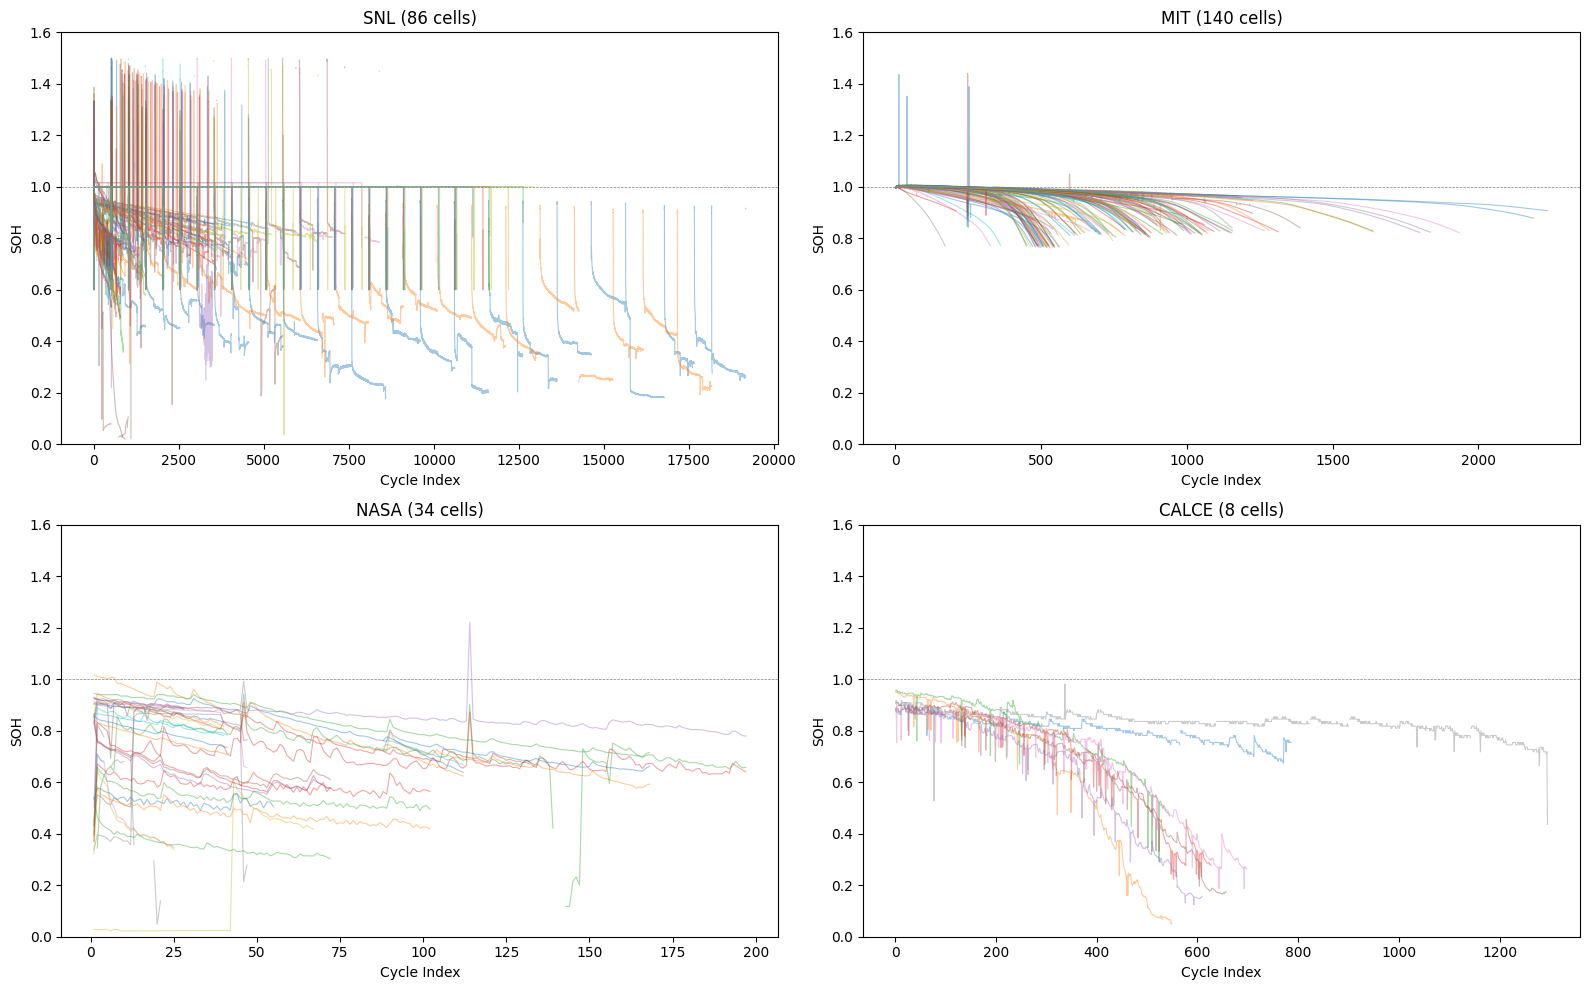


=== Final data quality summary ===
                  flag  rows_flagged  cells_affected  pct_of_total_rows
       high_spike_flag           384              72              0.096
      low_dropout_flag            80              66              0.020
     is_actual_rpt_row          1560              25              0.390
  is_transient_dropout           192               6              0.048
        is_midlife_dip             4               2              0.001
      is_early_invalid            13               2              0.003
      is_failure_event             4               2              0.001
is_low_confidence_cell            87               2              0.022
 soh_out_of_range_flag           716              22              0.179

=== Final dataset overview ===
Total rows: 399750 | Total cells: 268

Known limitations (for paper's data section):
- NASA_B0041, B0050: unexplained low-capacity runs per NASA's own README, flagged low-confidence not corrected
- 0.4% of restri

In [107]:
# Cell 112: Finalize dataset -- save, final fade-curve plot, and complete data-quality/limitations summary

os.makedirs('/kaggle/working/battery_data', exist_ok=True)
merged_final6.to_csv('/kaggle/working/battery_data/merged_soh_final_v2.csv', index=False)
print("Saved: merged_soh_final_v2.csv, shape:", merged_final6.shape)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sources = ['snl', 'mit', 'nasa', 'calce']
for ax, src in zip(axes.flat, sources):
    subset = merged_final6[merged_final6['source'] == src]
    for cell_id, group in subset.groupby('cell_id'):
        g = group.sort_values('cycle_index')
        ax.plot(g['cycle_index'], g['soh'], alpha=0.4, linewidth=0.8)
    ax.set_title(f"{src.upper()} ({subset['cell_id'].nunique()} cells)")
    ax.set_xlabel('Cycle Index')
    ax.set_ylabel('SOH')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.6)
plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/fade_curves_final_v2.png', dpi=120)
plt.show()

flag_cols = ['high_spike_flag', 'low_dropout_flag', 'is_actual_rpt_row', 'is_transient_dropout',
             'is_midlife_dip', 'is_early_invalid', 'is_failure_event', 'is_low_confidence_cell',
             'soh_out_of_range_flag']
summary_rows = []
for col in flag_cols:
    n_rows = merged_final6[col].sum()
    n_cells = merged_final6[merged_final6[col]]['cell_id'].nunique()
    summary_rows.append({'flag': col, 'rows_flagged': int(n_rows), 'cells_affected': int(n_cells),
                          'pct_of_total_rows': round(100*n_rows/len(merged_final6), 3)})
quality_summary = pd.DataFrame(summary_rows)
quality_summary.to_csv('/kaggle/working/battery_data/data_quality_summary_v2.csv', index=False)

print("\n=== Final data quality summary ===")
print(quality_summary.to_string(index=False))

print("\n=== Final dataset overview ===")
print("Total rows:", len(merged_final6), "| Total cells:", merged_final6['cell_id'].nunique())
print("\nKnown limitations (for paper's data section):")
print("- NASA_B0041, B0050: unexplained low-capacity runs per NASA's own README, flagged low-confidence not corrected")
print("- 0.4% of restricted-SOC rows show minor SOH inflation at RPT-boundary transitions (ambiguous single cycles, not corrected)")
print("- CS2_21, CS2_8 (CALCE): energy/voltage columns unavailable (raw txt format lacks them)")
print("- MIT cell_id is positional (barcode/channel_id fields corrupted in source .mat files), not the original lab identifier")

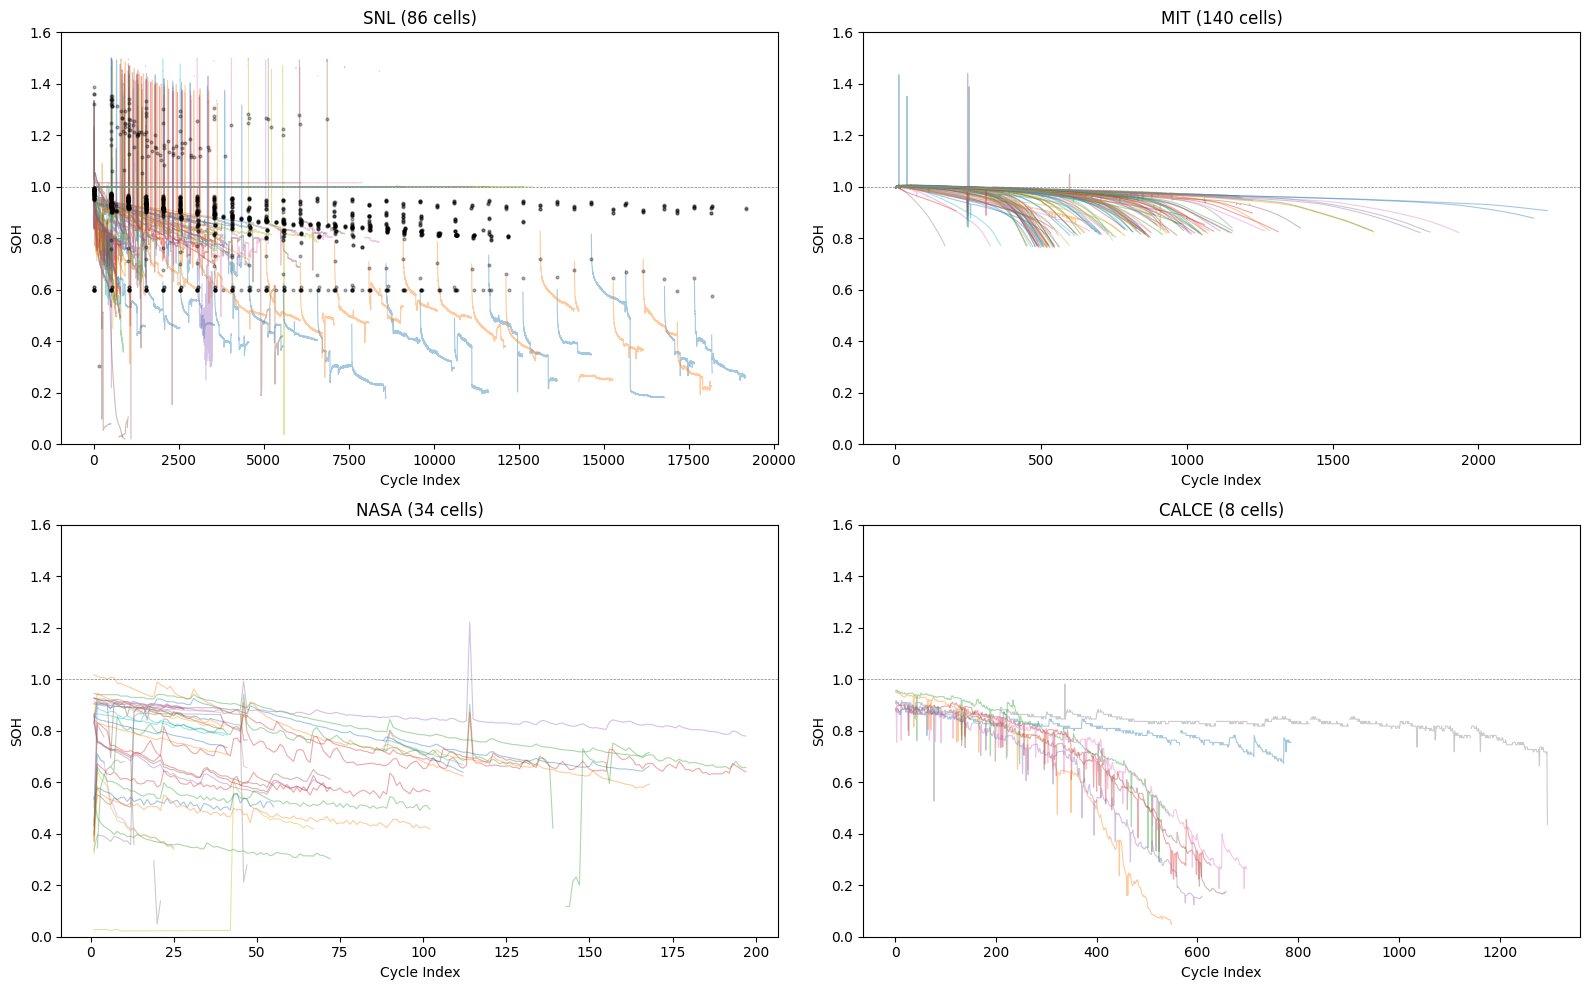

Saved: fade_curves_publication.png


In [108]:
# Cell 113: Publication-quality fade-curve plot -- RPT points as markers, not connected into the line

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sources = ['snl', 'mit', 'nasa', 'calce']

for ax, src in zip(axes.flat, sources):
    subset = merged_final6[merged_final6['source'] == src]
    for cell_id, group in subset.groupby('cell_id'):
        g = group.sort_values('cycle_index')
        normal = g[~g.get('is_actual_rpt_row', False)]
        rpt = g[g.get('is_actual_rpt_row', False)] if 'is_actual_rpt_row' in g.columns else g.iloc[:0]
        ax.plot(normal['cycle_index'], normal['soh'], alpha=0.4, linewidth=0.8)
        if len(rpt) > 0:
            ax.scatter(rpt['cycle_index'], rpt['soh'], s=4, color='black', alpha=0.3, zorder=5)
    ax.set_title(f"{src.upper()} ({subset['cell_id'].nunique()} cells)")
    ax.set_xlabel('Cycle Index')
    ax.set_ylabel('SOH')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.6)

plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/fade_curves_publication.png', dpi=150)
plt.show()
print("Saved: fade_curves_publication.png")

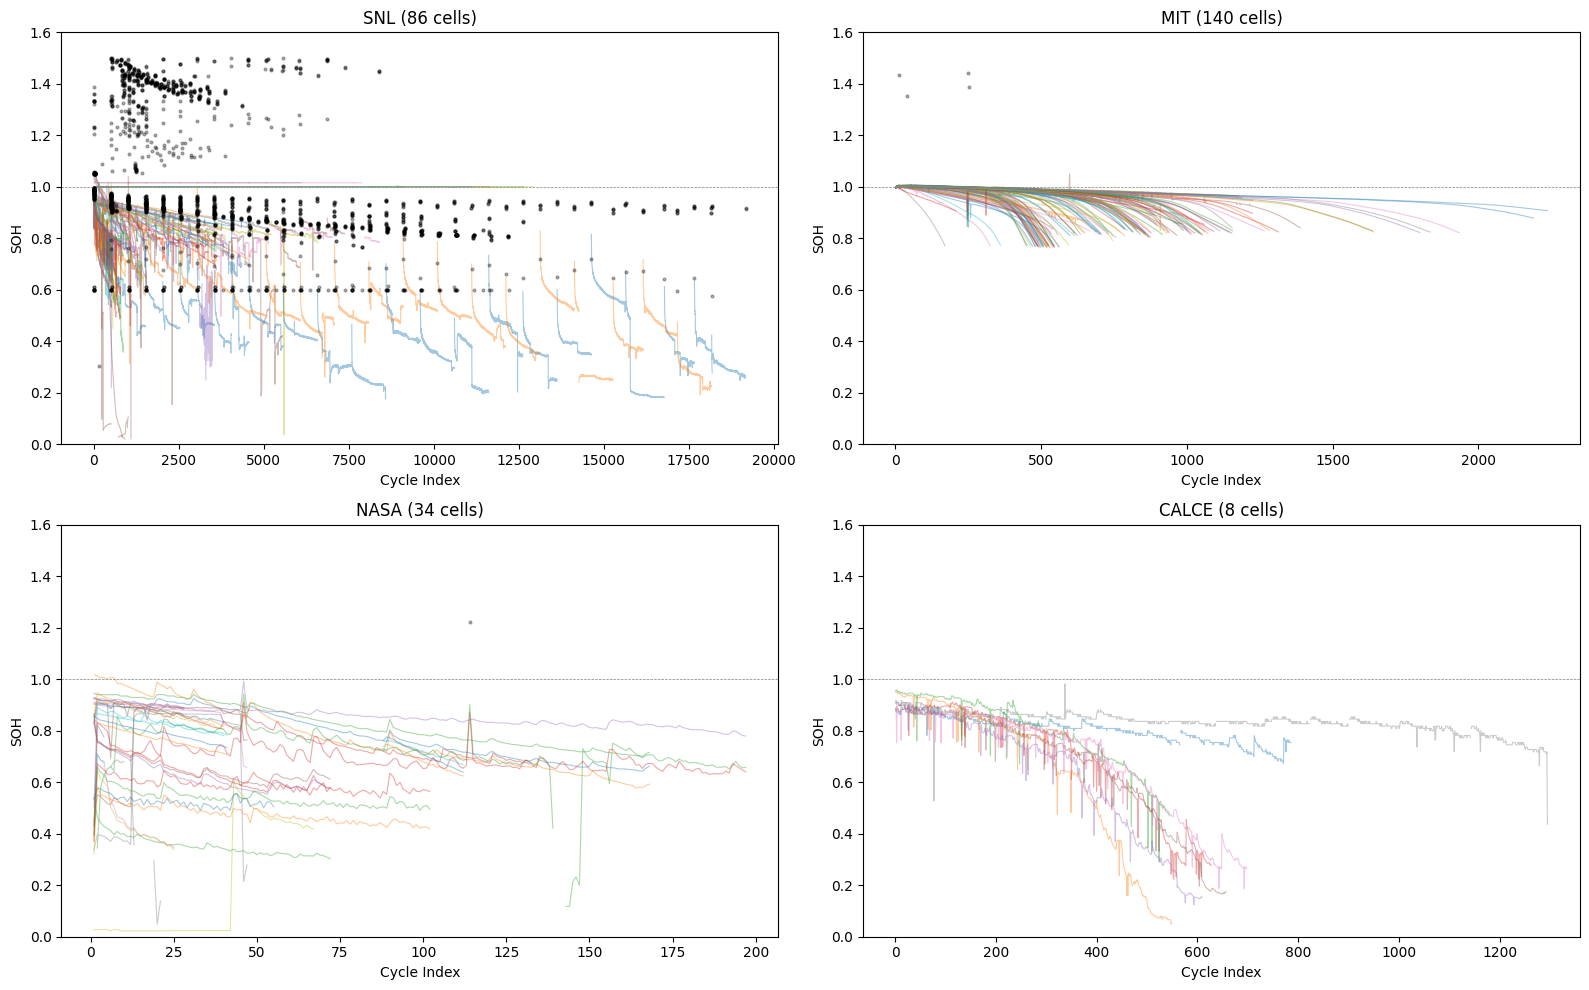

=== MIT cells with SOH > 1.05 anywhere (early-life spikes) ===
                       rows   max_soh cycle_range
cell_id                                          
MIT_2017-05-12_cell0      1  1.435818    (12, 12)
MIT_2017-05-12_cell18     1  1.351755    (40, 40)
MIT_2017-06-30_cell12     1  1.388696  (253, 253)
MIT_2017-06-30_cell44     1  1.440549  (248, 248)

=== NASA cells with SOH > 1.05 anywhere ===
           cell_id  cycle_index  discharge_capacity_ah  reference_capacity_ah       soh
398415  NASA_B0036          114               2.444062                    2.0  1.222031


In [109]:
# Cell 114: Correct the plot (exclude all anomalous points from the line), 
# then separately investigate MIT/NASA early-cycle spikes

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sources = ['snl', 'mit', 'nasa', 'calce']

for ax, src in zip(axes.flat, sources):
    subset = merged_final6[merged_final6['source'] == src]
    for cell_id, group in subset.groupby('cell_id'):
        g = group.sort_values('cycle_index')
        anomalous_mask = g.get('is_actual_rpt_row', False) | g.get('soh_out_of_range_flag', False)
        normal = g[~anomalous_mask]
        marker_pts = g[anomalous_mask]
        ax.plot(normal['cycle_index'], normal['soh'], alpha=0.4, linewidth=0.8)
        if len(marker_pts) > 0:
            ax.scatter(marker_pts['cycle_index'], marker_pts['soh'], s=4, color='black', alpha=0.3, zorder=5)
    ax.set_title(f"{src.upper()} ({subset['cell_id'].nunique()} cells)")
    ax.set_xlabel('Cycle Index')
    ax.set_ylabel('SOH')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.6)

plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/fade_curves_publication_v2.png', dpi=150)
plt.show()

# --- Now investigate the MIT/NASA early-cycle spikes, unrelated to RPT ---
print("=== MIT cells with SOH > 1.05 anywhere (early-life spikes) ===")
mit_spikes = merged_final6[(merged_final6['source']=='mit') & (merged_final6['soh'] > 1.05)]
print(mit_spikes.groupby('cell_id').agg(rows=('soh','size'), max_soh=('soh','max'), 
                                          cycle_range=('cycle_index', lambda x: (x.min(), x.max()))))

print("\n=== NASA cells with SOH > 1.05 anywhere ===")
nasa_spikes = merged_final6[(merged_final6['source']=='nasa') & (merged_final6['soh'] > 1.05)]
print(nasa_spikes[['cell_id','cycle_index','discharge_capacity_ah','reference_capacity_ah','soh']].to_string())

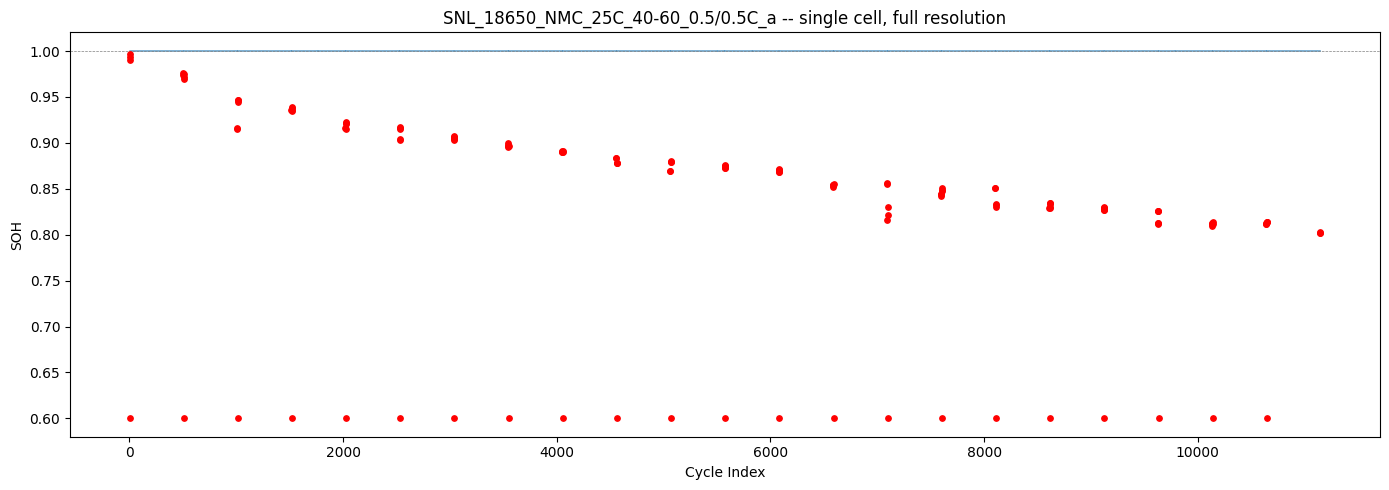

=== MIT spike rows, full context (5 cycles before/after each) ===

MIT_2017-05-12_cell10 around cycle 12:
        cycle_index  discharge_capacity_ah       soh
292772            9               1.079227  1.002809
292773           10               1.079540  1.003101
292774           11               1.079732  1.003279
292775           12               1.084971  1.008147
292776           13               1.075829  0.999652
292777           14               1.079682  1.003233
292778           15               1.080720  1.004197

MIT_2017-05-12_cell118 around cycle 40:
Empty DataFrame
Columns: [cycle_index, discharge_capacity_ah, soh]
Index: []

MIT_2017-06-30_cell112 around cycle 253:
Empty DataFrame
Columns: [cycle_index, discharge_capacity_ah, soh]
Index: []

MIT_2017-06-30_cell144 around cycle 248:
Empty DataFrame
Columns: [cycle_index, discharge_capacity_ah, soh]
Index: []

=== NASA_B0036 around cycle 114 ===
        cycle_index  discharge_capacity_ah       soh
398409          108     

In [110]:
# Cell 115: Zoomed single-cell plot to verify true smoothness, then examine MIT/NASA spike rows directly

fig, ax = plt.subplots(figsize=(14, 5))
one_cell = merged_final6[merged_final6['cell_id']=='SNL_18650_NMC_25C_40-60_0.5/0.5C_a'].sort_values('cycle_index')
anomalous_mask = one_cell['is_actual_rpt_row'] | one_cell['soh_out_of_range_flag']
normal = one_cell[~anomalous_mask]
marker_pts = one_cell[anomalous_mask]
ax.plot(normal['cycle_index'], normal['soh'], linewidth=1, alpha=0.8)
ax.scatter(marker_pts['cycle_index'], marker_pts['soh'], s=15, color='red', zorder=5)
ax.set_title("SNL_18650_NMC_25C_40-60_0.5/0.5C_a -- single cell, full resolution")
ax.set_xlabel('Cycle Index'); ax.set_ylabel('SOH')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/single_cell_zoom_check.png', dpi=120)
plt.show()

# --- Now look directly at the MIT/NASA spike rows themselves ---
print("=== MIT spike rows, full context (5 cycles before/after each) ===")
for cid, cyc in [('MIT_2017-05-12_cell10', 12), ('MIT_2017-05-12_cell118', 40),
                  ('MIT_2017-06-30_cell112', 253), ('MIT_2017-06-30_cell144', 248)]:
    sub = merged_final6[merged_final6['cell_id']==cid].sort_values('cycle_index')
    window = sub[(sub['cycle_index'] >= cyc-3) & (sub['cycle_index'] <= cyc+3)]
    print(f"\n{cid} around cycle {cyc}:")
    print(window[['cycle_index','discharge_capacity_ah','soh']].to_string())

print("\n=== NASA_B0036 around cycle 114 ===")
b36 = merged_final6[merged_final6['cell_id']=='NASA_B0036'].sort_values('cycle_index')
print(b36[(b36['cycle_index']>=108)&(b36['cycle_index']<=120)][['cycle_index','discharge_capacity_ah','soh']].to_string())

In [111]:
# Cell 116: Debug the empty MIT lookups, then flag and null NASA_B0036's single-cycle glitch

# --- Debug: why did 3 of the 4 MIT lookups return empty? ---
for cid, cyc in [('MIT_2017-05-12_cell118', 40), ('MIT_2017-06-30_cell112', 253), ('MIT_2017-06-30_cell144', 248)]:
    sub = merged_final6[merged_final6['cell_id']==cid]
    print(f"{cid}: rows={len(sub)}, cycle_index dtype={sub['cycle_index'].dtype}, "
          f"cycle_index range=({sub['cycle_index'].min()}, {sub['cycle_index'].max()})")
    print("  Does cycle_index contain", cyc, "?", (sub['cycle_index']==cyc).any())
    # maybe cell_id string doesn't match exactly -- check for whitespace/case issues
    close_matches = [c for c in merged_final6['cell_id'].unique() if cid.replace('_cell','_') in c or cid in c]
    print("  close cell_id matches:", close_matches[:5])

# --- NASA_B0036: flag and null the single-cycle glitch ---
b36_mask = (merged_final6['cell_id']=='NASA_B0036') & (merged_final6['cycle_index']==114)
merged_final6['is_single_cycle_glitch'] = False
merged_final6.loc[b36_mask, 'is_single_cycle_glitch'] = True
for col in capacity_energy_cols:
    merged_final6.loc[b36_mask, col] = pd.NA
merged_final6.loc[b36_mask, 'soh'] = pd.NA

print("\nB0036 cycle 114 after nulling:")
print(merged_final6[(merged_final6['cell_id']=='NASA_B0036') & 
                      (merged_final6['cycle_index'].between(112,116))][['cycle_index','discharge_capacity_ah','soh','is_single_cycle_glitch']])

MIT_2017-05-12_cell118: rows=0, cycle_index dtype=int64, cycle_index range=(nan, nan)
  Does cycle_index contain 40 ? False
  close cell_id matches: []
MIT_2017-06-30_cell112: rows=0, cycle_index dtype=int64, cycle_index range=(nan, nan)
  Does cycle_index contain 253 ? False
  close cell_id matches: []
MIT_2017-06-30_cell144: rows=0, cycle_index dtype=int64, cycle_index range=(nan, nan)
  Does cycle_index contain 248 ? False
  close cell_id matches: []

B0036 cycle 114 after nulling:
        cycle_index  discharge_capacity_ah       soh  is_single_cycle_glitch
398413          112               1.667598  0.833799                   False
398414          113               1.678187  0.839094                   False
398415          114                    NaN       NaN                    True
398416          115               1.691340  0.845670                   False
398417          116               1.680279  0.840139                   False


In [112]:
# Cell 117: Get exact MIT cell_id strings and cycle values programmatically, no manual transcription

mit_spikes = merged_final6[(merged_final6['source']=='mit') & (merged_final6['soh'] > 1.05)]
print("Exact cell_id values (repr to reveal hidden characters):")
for cid in mit_spikes['cell_id'].unique():
    print(repr(cid))

print("\nFull rows for these spikes, pulled directly (no retyping):")
print(mit_spikes[['cell_id','cycle_index','discharge_capacity_ah','soh']].to_string())

# now pull surrounding context using the EXACT cell_id values from the dataframe itself
for cid in mit_spikes['cell_id'].unique():
    spike_cycle = mit_spikes[mit_spikes['cell_id']==cid]['cycle_index'].iloc[0]
    sub = merged_final6[merged_final6['cell_id']==cid].sort_values('cycle_index')
    window = sub[(sub['cycle_index'] >= spike_cycle-3) & (sub['cycle_index'] <= spike_cycle+3)]
    print(f"\n{repr(cid)} around cycle {spike_cycle}:")
    print(window[['cycle_index','discharge_capacity_ah','soh']].to_string())

Exact cell_id values (repr to reveal hidden characters):
'MIT_2017-05-12_cell0'
'MIT_2017-05-12_cell18'
'MIT_2017-06-30_cell12'
'MIT_2017-06-30_cell44'

Full rows for these spikes, pulled directly (no retyping):
                      cell_id  cycle_index  discharge_capacity_ah       soh
282273   MIT_2017-05-12_cell0           12               1.539054  1.435818
299606  MIT_2017-05-12_cell18           40               1.442042  1.351755
327973  MIT_2017-06-30_cell12          253               1.489119  1.388696
344053  MIT_2017-06-30_cell44          248               1.544718  1.440549

'MIT_2017-05-12_cell0' around cycle 12:
        cycle_index  discharge_capacity_ah       soh
282270            9               1.074492  1.002418
282271           10               1.074537  1.002460
282272           11               1.074781  1.002688
282273           12               1.539054  1.435818
282274           13               1.073827  1.001797
282275           14               1.075056  1.002

In [113]:
# Cell 118: Flag and null the 4 MIT single-cycle glitches, same treatment as NASA_B0036

mit_glitch_rows = [
    ('MIT_2017-05-12_cell0', 12),
    ('MIT_2017-05-12_cell18', 40),
    ('MIT_2017-06-30_cell12', 253),
    ('MIT_2017-06-30_cell44', 248),
]

for cid, cyc in mit_glitch_rows:
    mask = (merged_final6['cell_id']==cid) & (merged_final6['cycle_index']==cyc)
    merged_final6.loc[mask, 'is_single_cycle_glitch'] = True
    for col in capacity_energy_cols:
        merged_final6.loc[mask, col] = pd.NA
    merged_final6.loc[mask, 'soh'] = pd.NA

print("is_single_cycle_glitch total rows:", merged_final6['is_single_cycle_glitch'].sum())
print("Cells affected:", merged_final6[merged_final6['is_single_cycle_glitch']]['cell_id'].unique())

# final full-dataset sanity check: any remaining SOH > 1.05 anywhere, outside known RPT/flagged rows?
residual = merged_final6[(merged_final6['soh'] > 1.05) & 
                           (~merged_final6['is_actual_rpt_row']) & 
                           (~merged_final6['soh_out_of_range_flag'].fillna(False))]
print("\nAny unexplained SOH>1.05 outside RPT/flagged rows:", len(residual))

print("\nFinal SOH describe (post all corrections):")
print(merged_final6['soh'].describe())

is_single_cycle_glitch total rows: 5
Cells affected: ['MIT_2017-05-12_cell0' 'MIT_2017-05-12_cell18' 'MIT_2017-06-30_cell12'
 'MIT_2017-06-30_cell44' 'NASA_B0036']

Any unexplained SOH>1.05 outside RPT/flagged rows: 0

Final SOH describe (post all corrections):
count    398375.000000
mean          0.875593
std           0.172286
min           0.020088
25%           0.832235
50%           0.926263
75%           1.000007
max           1.499691
Name: soh, dtype: float64


Saved: merged_soh_FINAL.csv, shape: (399750, 27)


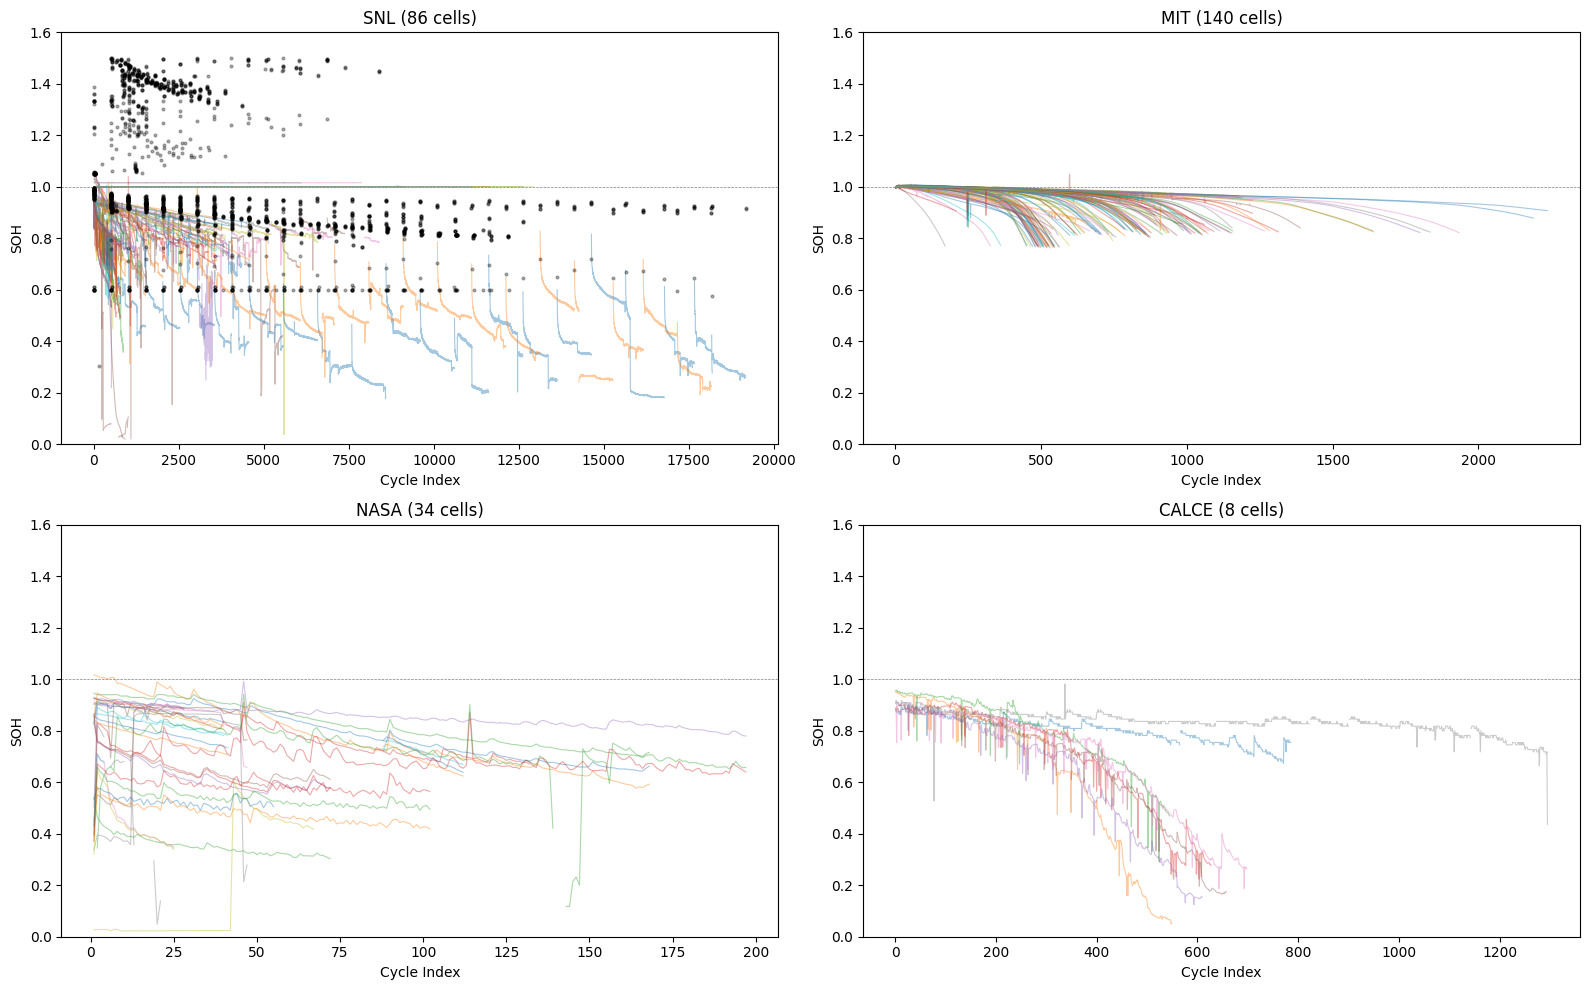


=== Final data quality summary ===
                  flag  rows_flagged  cells_affected  pct_of_total_rows
       high_spike_flag           384              72              0.096
      low_dropout_flag            80              66              0.020
     is_actual_rpt_row          1560              25              0.390
  is_transient_dropout           192               6              0.048
        is_midlife_dip             4               2              0.001
      is_early_invalid            13               2              0.003
      is_failure_event             4               2              0.001
is_low_confidence_cell            87               2              0.022
is_single_cycle_glitch             5               5              0.001
 soh_out_of_range_flag           716              22              0.179

=== Final dataset overview ===
Total rows: 399750 | Total cells: 268
Rows with valid discharge_capacity_ah: 398375

By source:
        cells    rows
source               


In [114]:
# Cell 119: TRUE final save -- dataset, clean plot, complete quality summary, and limitations doc

os.makedirs('/kaggle/working/battery_data', exist_ok=True)
merged_final6.to_csv('/kaggle/working/battery_data/merged_soh_FINAL.csv', index=False)
print("Saved: merged_soh_FINAL.csv, shape:", merged_final6.shape)

# --- Clean fade-curve plot, excluding all flagged/anomalous points from the connecting line ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sources = ['snl', 'mit', 'nasa', 'calce']
for ax, src in zip(axes.flat, sources):
    subset = merged_final6[merged_final6['source'] == src]
    for cell_id, group in subset.groupby('cell_id'):
        g = group.sort_values('cycle_index')
        anomalous = (g.get('is_actual_rpt_row', False) | g.get('soh_out_of_range_flag', False).fillna(False)
                     | g.get('is_single_cycle_glitch', False))
        normal = g[~anomalous]
        marker_pts = g[anomalous]
        ax.plot(normal['cycle_index'], normal['soh'], alpha=0.4, linewidth=0.8)
        if len(marker_pts) > 0:
            ax.scatter(marker_pts['cycle_index'], marker_pts['soh'], s=4, color='black', alpha=0.3, zorder=5)
    ax.set_title(f"{src.upper()} ({subset['cell_id'].nunique()} cells)")
    ax.set_xlabel('Cycle Index'); ax.set_ylabel('SOH')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.6)
plt.tight_layout()
plt.savefig('/kaggle/working/battery_data/fade_curves_TRUE_FINAL.png', dpi=150)
plt.show()

# --- Complete data quality summary ---
flag_cols = ['high_spike_flag', 'low_dropout_flag', 'is_actual_rpt_row', 'is_transient_dropout',
             'is_midlife_dip', 'is_early_invalid', 'is_failure_event', 'is_low_confidence_cell',
             'is_single_cycle_glitch', 'soh_out_of_range_flag']
summary_rows = []
for col in flag_cols:
    n_rows = int(merged_final6[col].fillna(False).sum())
    n_cells = merged_final6[merged_final6[col].fillna(False)]['cell_id'].nunique()
    summary_rows.append({'flag': col, 'rows_flagged': n_rows, 'cells_affected': n_cells,
                          'pct_of_total_rows': round(100*n_rows/len(merged_final6), 3)})
quality_summary = pd.DataFrame(summary_rows)
quality_summary.to_csv('/kaggle/working/battery_data/data_quality_summary_FINAL.csv', index=False)
print("\n=== Final data quality summary ===")
print(quality_summary.to_string(index=False))

print("\n=== Final dataset overview ===")
print("Total rows:", len(merged_final6), "| Total cells:", merged_final6['cell_id'].nunique())
print("Rows with valid discharge_capacity_ah:", merged_final6['discharge_capacity_ah'].notna().sum())
print("\nBy source:")
print(merged_final6.groupby('source').agg(cells=('cell_id','nunique'), rows=('cell_id','size')))

In [115]:
# Cell 120: Feature engineering -- fade rate, rolling variance, normalized cycle position; 
# then cell-level, source-stratified train/test split

df = merged_final6.copy()

# --- Fade rate: rolling slope of SOH over a trailing window, per cell ---
def compute_fade_rate(group, window=10):
    group = group.sort_values('cycle_index').copy()
    group['fade_rate'] = group['soh'].rolling(window=window, min_periods=3).apply(
        lambda y: np.polyfit(np.arange(len(y)), y, 1)[0] if y.notna().sum() >= 3 else np.nan, raw=False)
    return group

df = df.groupby('cell_id', group_keys=False).apply(compute_fade_rate)

# --- Rolling capacity variance (noise/precursor signal) ---
df['capacity_rolling_std'] = df.groupby('cell_id')['discharge_capacity_ah'].transform(
    lambda x: x.rolling(window=10, min_periods=3).std())

# --- Normalized cycle position (0-1) per cell, since ranges vary hugely across sources ---
df['cycle_progress'] = df.groupby('cell_id')['cycle_index'].transform(lambda x: x / x.max())

print("Feature columns added:", ['fade_rate', 'capacity_rolling_std', 'cycle_progress'])
print("\nSample (one cell):")
print(df[df['cell_id']=='NASA_B0005'].sort_values('cycle_index')[
    ['cycle_index','soh','fade_rate','capacity_rolling_std','cycle_progress']].iloc[::20].to_string())

# --- Cell-level, source-stratified train/test split ---
from sklearn.model_selection import train_test_split

cell_source_map = df.groupby('cell_id')['source'].first().reset_index()
train_cells, test_cells = train_test_split(
    cell_source_map, test_size=0.2, stratify=cell_source_map['source'], random_state=42)

df['split'] = np.where(df['cell_id'].isin(train_cells['cell_id']), 'train', 'test')

print("\n=== Split summary ===")
print(df.groupby(['source','split'])['cell_id'].nunique().unstack())
print("\nRow counts:")
print(df['split'].value_counts())

merged_features = df
merged_features.to_csv('/kaggle/working/battery_data/merged_features_split.csv', index=False)
print("\nSaved: merged_features_split.csv, shape:", merged_features.shape)

/tmp/ipykernel_16/281169701.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('cell_id', group_keys=False).apply(compute_fade_rate)


Feature columns added: ['fade_rate', 'capacity_rolling_std', 'cycle_progress']

Sample (one cell):
        cycle_index       soh  fade_rate  capacity_rolling_std  cycle_progress
397000            1  0.928244        NaN                   NaN        0.005952
397020           21  0.923709   0.001456              0.017786        0.125000
397040           41  0.883936  -0.003488              0.021346        0.244048
397060           61  0.842451  -0.003438              0.020919        0.363095
397080           81  0.779883  -0.002651              0.017167        0.482143
397100          101  0.740207  -0.003536              0.021599        0.601190
397120          121  0.719128  -0.000288              0.010871        0.720238
397140          141  0.672095  -0.001759              0.012831        0.839286
397160          161  0.651705  -0.001942              0.012270        0.958333

=== Split summary ===
split   test  train
source             
calce      2      6
mit       28    112
nasa    

In [116]:
# Cell 96: Check B0033 via low_dropout_flag, fix B0041 with late-cycle reference

b33_check = merged_final2[merged_final2['cell_id']=='NASA_B0033'].sort_values('cycle_index')
print("B0033 low_dropout_flag at cycles 138-149:")
print(b33_check[(b33_check['cycle_index']>=138)&(b33_check['cycle_index']<=149)][['cycle_index','discharge_capacity_ah','low_dropout_flag']].to_string())

def flag_early_invalid_v2(group, col='discharge_capacity_ah', jump_ratio=3):
    """Reference = median of LAST 20 valid cycles (robust to early-life corruption)."""
    group = group.sort_values('cycle_index').copy()
    group['is_early_invalid'] = False
    vals = group[col].values
    valid = ~pd.isna(vals)
    if valid.sum() < 20:
        return group
    stabilized_ref = np.nanmedian(vals[valid][-20:])
    if pd.isna(stabilized_ref) or stabilized_ref == 0:
        return group
    for i in range(len(vals)):
        if pd.isna(vals[i]):
            continue
        if vals[i] < stabilized_ref / jump_ratio:
            group.iloc[i, group.columns.get_loc('is_early_invalid')] = True
        else:
            break
    return group

merged_final2 = merged_final2.drop(columns=['is_early_invalid'], errors='ignore')
merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_early_invalid_v2, include_groups=False).reset_index(level=0).rename(columns={'level_0':'cell_id'}) if False else merged_final2.groupby('cell_id', group_keys=False).apply(flag_early_invalid_v2)

print("\nis_early_invalid after fix:", merged_final2['is_early_invalid'].sum())
print("Cells:", merged_final2[merged_final2['is_early_invalid']]['cell_id'].unique())

b41_check = merged_final2[merged_final2['cell_id']=='NASA_B0041'].sort_values('cycle_index')
print("\nB0041 is_early_invalid cycles:", b41_check[b41_check['is_early_invalid']]['cycle_index'].tolist())

# apply nulling for early_invalid (fresh flag) and manually null B0033's uncaught mid-life dip if low_dropout_flag missed it
for col in capacity_energy_cols:
    merged_final2.loc[merged_final2['is_early_invalid'], col] = pd.NA
merged_final2['soh'] = merged_final2['discharge_capacity_ah'] / merged_final2['reference_capacity_ah']
print("\nFinal SOH describe:", merged_final2['soh'].describe())

B0033 low_dropout_flag at cycles 138-149:
        cycle_index  discharge_capacity_ah  low_dropout_flag
398045          138               1.325319             False
398046          139               0.843968             False
398047          140               0.298662             False
398048          141               0.234487             False
398049          142               0.202563             False
398050          143               0.235320             False
398051          144               0.235504             False
398052          145               0.430424             False
398053          146               0.464363             False
398054          147               0.399484             False
398055          148               1.461470             False
398056          149               1.415100             False

is_early_invalid after fix: 42
Cells: ['NASA_B0041']

B0041 is_early_invalid cycles: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,

/tmp/ipykernel_16/3113018590.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_final2 = merged_final2.groupby('cell_id', group_keys=False).apply(flag_early_invalid_v2, include_groups=False).reset_index(level=0).rename(columns={'level_0':'cell_id'}) if False else merged_final2.groupby('cell_id', group_keys=False).apply(flag_early_invalid_v2)


In [117]:
# Cell 97: Manually null B0033's confirmed dip (cycles 139-147), final save

b33_mask = (merged_final2['cell_id']=='NASA_B0033') & (merged_final2['cycle_index'].between(139,147))
for col in capacity_energy_cols:
    merged_final2.loc[b33_mask, col] = pd.NA
merged_final2['soh'] = merged_final2['discharge_capacity_ah'] / merged_final2['reference_capacity_ah']

print("Final SOH describe:")
print(merged_final2['soh'].describe())

merged_final2.to_csv('/kaggle/working/battery_data/unified_battery_dataset_cleaned.csv', index=False)
print("\nSaved:", merged_final2.shape, "| unique cells:", merged_final2['cell_id'].nunique())

Final SOH describe:
count    398333.000000
mean          0.886723
std           0.256548
min           0.020088
25%           0.832619
50%           0.927340
75%           1.000009
max           4.981535
Name: soh, dtype: float64

Saved: (399750, 22) | unique cells: 268


## Day 4-6: SoH Feature Engineering & Baseline Model

Target: SOH at 50% of each cell's observed life (median lifecycle point), 
predicted from features computed over the first 20% of that cell's life.
Rationale: normalizes across sources with wildly different total cycle 
counts (CS2 ~600 cycles vs SNL ~19,000) -- a fixed cycle-count target would 
be meaningless for short-life cells and trivial for long-life ones.

Excludes cells with: is_restricted_soc (different capacity regime, would 
need separate reference handling), is_low_confidence_cell (B0050), and any 
cell with fewer than ~20 valid cycles (not enough signal for the input window).

In [118]:
# Cell 98: Build the per-cell life-fraction index, scope the eligible cell set

df = merged_final2.copy()

# total observed (valid, non-null) cycle count per cell
cell_life = df.dropna(subset=['soh']).groupby('cell_id')['cycle_index'].agg(['min','max','count'])
cell_life['total_cycles'] = cell_life['max'] - cell_life['min'] + 1
print("Cell life distribution:")
print(cell_life['total_cycles'].describe())

# eligibility: exclude restricted-SOC, low-confidence, and short-life cells
excluded_cells = set(df[df['is_restricted_soc']]['cell_id']) | set(df[df['is_low_confidence_cell']]['cell_id'])
short_life_cells = set(cell_life[cell_life['total_cycles'] < 20].index)
excluded_cells |= short_life_cells

eligible_cells = set(df['cell_id'].unique()) - excluded_cells
print(f"\nTotal cells: {df['cell_id'].nunique()}")
print(f"Excluded (restricted-SOC / low-confidence / short-life): {len(excluded_cells)}")
print(f"Eligible cells for Stage 1: {len(eligible_cells)}")

print("\nEligible cells by source:")
print(df[df['cell_id'].isin(eligible_cells)].groupby('source')['cell_id'].nunique())

Cell life distribution:
count      268.000000
mean      1495.526119
std       2515.911275
min          4.000000
25%        514.000000
50%        783.500000
75%       1131.500000
max      19174.000000
Name: total_cycles, dtype: float64

Total cells: 268
Excluded (restricted-SOC / low-confidence / short-life): 27
Eligible cells for Stage 1: 241

Eligible cells by source:
source
calce      8
mit      140
nasa      32
snl       61
Name: cell_id, dtype: int64


In [119]:
# Cell 99: Compute input-window and target cycle points per eligible cell

df_eligible = df[df['cell_id'].isin(eligible_cells)].dropna(subset=['soh']).copy()

cell_points = []
for cid, g in df_eligible.groupby('cell_id'):
    g = g.sort_values('cycle_index')
    cycles = g['cycle_index'].values
    min_c, max_c = cycles.min(), cycles.max()
    span = max_c - min_c

    input_cutoff = min_c + 0.20 * span   # end of input window
    target_point = min_c + 0.50 * span   # where we read the target SOH

    # nearest available cycle to the target point
    target_cycle = g.iloc[(g['cycle_index'] - target_point).abs().argsort()[:1]]
    target_soh = target_cycle['soh'].values[0]
    target_cycle_actual = target_cycle['cycle_index'].values[0]

    n_input_cycles = (g['cycle_index'] <= input_cutoff).sum()

    cell_points.append({
        'cell_id': cid, 'source': g['source'].iloc[0], 'cathode': g['cathode'].iloc[0],
        'min_cycle': min_c, 'max_cycle': max_c, 'total_span': span,
        'input_cutoff_cycle': input_cutoff, 'n_input_cycles': n_input_cycles,
        'target_cycle_actual': target_cycle_actual, 'target_soh': target_soh
    })

cell_points_df = pd.DataFrame(cell_points)
print("Shape:", cell_points_df.shape)
print("\nn_input_cycles distribution (want this reasonably large for feature stability):")
print(cell_points_df['n_input_cycles'].describe())

print("\nAny cells with very few input cycles (<5)?")
print(cell_points_df[cell_points_df['n_input_cycles'] < 5][['cell_id','source','n_input_cycles','total_span']])

print("\ntarget_soh distribution (sanity check - should mostly be 0.7-1.0 range at 50% life):")
print(cell_points_df['target_soh'].describe())

Shape: (241, 10)

n_input_cycles distribution (want this reasonably large for feature stability):
count    241.000000
mean     188.307054
std      185.065791
min        5.000000
25%      102.000000
50%      141.000000
75%      197.000000
max      908.000000
Name: n_input_cycles, dtype: float64

Any cells with very few input cycles (<5)?
Empty DataFrame
Columns: [cell_id, source, n_input_cycles, total_span]
Index: []

target_soh distribution (sanity check - should mostly be 0.7-1.0 range at 50% life):
count    241.000000
mean       0.900008
std        0.122140
min        0.356966
25%        0.843454
50%        0.967979
75%        0.984540
max        0.995669
Name: target_soh, dtype: float64


In [120]:
# Cell 100 (REPLACEMENT): coerce voltage columns first, then engineer features

for col in ['voltage_max', 'voltage_min']:
    if col in df_eligible.columns and df_eligible[col].dtype == object:
        before_null = df_eligible[col].isna().sum()
        df_eligible[col] = pd.to_numeric(df_eligible[col], errors='coerce')
        after_null = df_eligible[col].isna().sum()
        print(f"{col}: coerced, {before_null} null before, {after_null} after ({after_null-before_null} new)")
    else:
        print(f"{col}: already numeric or absent")

def engineer_features(cell_id, input_cutoff, df_all):
    g = df_all[(df_all['cell_id'] == cell_id) & (df_all['cycle_index'] <= input_cutoff)].sort_values('cycle_index')
    g = g.dropna(subset=['soh'])
    if len(g) < 3:
        return None

    cycles = g['cycle_index'].values
    soh_vals = g['soh'].values

    slope, intercept = np.polyfit(cycles, soh_vals, 1)

    if len(g) >= 5:
        poly2 = np.polyfit(cycles, soh_vals, 2)
        curvature = poly2[0]
    else:
        curvature = np.nan

    features = {
        'cell_id': cell_id,
        'soh_at_start': soh_vals[0],
        'soh_at_cutoff': soh_vals[-1],
        'soh_fade_slope': slope,
        'soh_fade_curvature': curvature,
        'soh_std': np.std(soh_vals),
        'n_cycles_used': len(g),
    }

    if 'voltage_max' in g.columns and g['voltage_max'].notna().sum() > 0:
        features['voltage_max_mean'] = g['voltage_max'].mean()
        vmax_valid = g[g['voltage_max'].notna()]
        if len(vmax_valid) >= 3:
            features['voltage_max_trend'] = np.polyfit(vmax_valid['cycle_index'].values, 
                                                          vmax_valid['voltage_max'].values, 1)[0]
        else:
            features['voltage_max_trend'] = np.nan
    else:
        features['voltage_max_mean'] = np.nan
        features['voltage_max_trend'] = np.nan

    return features

feature_rows = []
for _, row in cell_points_df.iterrows():
    feat = engineer_features(row['cell_id'], row['input_cutoff_cycle'], df_eligible)
    if feat is not None:
        feature_rows.append(feat)

features_df = pd.DataFrame(feature_rows)
print("\nShape:", features_df.shape)
print("\nNull counts:")
print(features_df.isna().sum())
print("\nSample:")
print(features_df.head(10).to_string())

voltage_max: coerced, 116763 null before, 116763 after (0 new)
voltage_min: coerced, 120449 null before, 120449 after (0 new)

Shape: (241, 9)

Null counts:
cell_id                 0
soh_at_start            0
soh_at_cutoff           0
soh_fade_slope          0
soh_fade_curvature      0
soh_std                 0
n_cycles_used           0
voltage_max_mean      142
voltage_max_trend     142
dtype: int64

Sample:
                cell_id  soh_at_start  soh_at_cutoff  soh_fade_slope  soh_fade_curvature   soh_std  n_cycles_used  voltage_max_mean  voltage_max_trend
0                CS2_21      0.881818       0.845455       -0.000265       -1.032926e-06  0.017581            156               NaN                NaN
1                CS2_33      0.950941       0.896929       -0.000384        1.478129e-06  0.023069            110          4.200464      -2.805818e-06
2                CS2_34      0.956204       0.921076       -0.000219        1.378460e-06  0.018856            109          4.201508   

In [121]:
# Cell 101: Join, split, baseline model

model_df = features_df.merge(cell_points_df[['cell_id', 'source', 'cathode', 'target_soh']], on='cell_id', how='inner')
print("Model dataset shape:", model_df.shape)
print("\nSource distribution:")
print(model_df['source'].value_counts())

from sklearn.model_selection import train_test_split

feature_cols = ['soh_at_start', 'soh_at_cutoff', 'soh_fade_slope', 'soh_fade_curvature', 
                 'soh_std', 'n_cycles_used', 'voltage_max_mean', 'voltage_max_trend']

train_cells, test_cells = train_test_split(
    model_df[['cell_id', 'source']].drop_duplicates(), 
    test_size=0.2, random_state=42, stratify=model_df[['cell_id','source']].drop_duplicates()['source']
)

train_df = model_df[model_df['cell_id'].isin(train_cells['cell_id'])]
test_df = model_df[model_df['cell_id'].isin(test_cells['cell_id'])]

print(f"\nTrain: {len(train_df)} cells, Test: {len(test_df)} cells")
print("Train source dist:", train_df['source'].value_counts().to_dict())
print("Test source dist:", test_df['source'].value_counts().to_dict())

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train = train_df[feature_cols].fillna(-1)
y_train = train_df['target_soh']
X_test = test_df[feature_cols].fillna(-1)
y_test = test_df['target_soh']

model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, min_samples_leaf=3)
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
print(f"\nTest MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

Model dataset shape: (241, 12)

Source distribution:
source
mit      140
snl       61
nasa      32
calce      8
Name: count, dtype: int64

Train: 192 cells, Test: 49 cells
Train source dist: {'mit': 112, 'snl': 49, 'nasa': 25, 'calce': 6}
Test source dist: {'mit': 28, 'snl': 12, 'nasa': 7, 'calce': 2}

Test MAE: 0.0216
Test R²: 0.8909

Feature importances:
soh_at_cutoff         0.773888
soh_std               0.070833
voltage_max_mean      0.050168
soh_at_start          0.039816
soh_fade_slope        0.027444
soh_fade_curvature    0.021722
voltage_max_trend     0.009467
n_cycles_used         0.006662
dtype: float64


In [122]:
# Cell 102: Ablation — remove soh_at_cutoff, see what the trend features alone can do

feature_cols_no_cutoff = [c for c in feature_cols if c != 'soh_at_cutoff']

X_train2 = train_df[feature_cols_no_cutoff].fillna(-1)
X_test2 = test_df[feature_cols_no_cutoff].fillna(-1)

model2 = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, min_samples_leaf=3)
model2.fit(X_train2, y_train)
preds2 = model2.predict(X_test2)

mae2 = mean_absolute_error(y_test, preds2)
r2_2 = r2_score(y_test, preds2)
print(f"Without soh_at_cutoff — Test MAE: {mae2:.4f}, Test R²: {r2_2:.4f}")
print(f"(For comparison, WITH soh_at_cutoff — MAE: {mae:.4f}, R²: {r2:.4f})")

importances2 = pd.Series(model2.feature_importances_, index=feature_cols_no_cutoff).sort_values(ascending=False)
print("\nFeature importances (without soh_at_cutoff):")
print(importances2)

# also: naive baseline for comparison (predict target = soh_at_cutoff directly, no model at all)
naive_mae = mean_absolute_error(y_test, test_df['soh_at_cutoff'])
print(f"\nNaive baseline (just use soh_at_cutoff as the prediction, no model): MAE = {naive_mae:.4f}")

Without soh_at_cutoff — Test MAE: 0.0219, Test R²: 0.8705
(For comparison, WITH soh_at_cutoff — MAE: 0.0216, R²: 0.8909)

Feature importances (without soh_at_cutoff):
soh_std               0.307706
voltage_max_mean      0.288057
soh_at_start          0.174481
voltage_max_trend     0.106998
soh_fade_slope        0.087767
n_cycles_used         0.018989
soh_fade_curvature    0.016002
dtype: float64

Naive baseline (just use soh_at_cutoff as the prediction, no model): MAE = 0.0377


In [123]:
# Cell 103: Save model, predictions, and summary metrics

import joblib

joblib.dump(model, '/kaggle/working/battery_data/soh_baseline_model.pkl')

results_df = test_df[['cell_id', 'source', 'cathode']].copy()
results_df['actual_soh'] = y_test.values
results_df['predicted_soh'] = preds
results_df['abs_error'] = (results_df['actual_soh'] - results_df['predicted_soh']).abs()
results_df.to_csv('/kaggle/working/battery_data/soh_baseline_predictions.csv', index=False)

print("Saved model and predictions.")
print("\nError by source (where's the model weaker/stronger?):")
print(results_df.groupby('source')['abs_error'].agg(['mean', 'max', 'count']))

summary = {
    'model': 'RandomForestRegressor (baseline)',
    'test_mae': mae,
    'test_r2': r2,
    'naive_baseline_mae': naive_mae,
    'improvement_over_naive_pct': (1 - mae/naive_mae) * 100,
    'n_train_cells': len(train_cells),
    'n_test_cells': len(test_cells),
    'n_features': len(feature_cols),
}

for k, v in summary.items():
    print(f"  {k}: {v}")

Saved model and predictions.

Error by source (where's the model weaker/stronger?):
            mean       max  count
source                           
calce   0.046411  0.064960      2
mit     0.002759  0.013810     28
nasa    0.071496  0.182787      7
snl     0.032353  0.155442     12
  model: RandomForestRegressor (baseline)
  test_mae: 0.02160783354368115
  test_r2: 0.8908573395957035
  naive_baseline_mae: 0.037703985107199155
  improvement_over_naive_pct: 42.69084956869619
  n_train_cells: 192
  n_test_cells: 49
  n_features: 8


In [124]:
# Cell 104: Quick check — does NASA's higher error correlate with cells we heavily corrected?

nasa_test_cells = results_df[results_df['source']=='nasa']['cell_id'].tolist()
print("NASA test cells and their correction history:")
for cid in nasa_test_cells:
    flags = df[df['cell_id']==cid][['is_early_invalid','is_transient_dropout','is_failure_event']].any()
    err = results_df[results_df['cell_id']==cid]['abs_error'].values[0]
    print(f"  {cid}: abs_error={err:.4f}, was_corrected={flags.any()}, details={flags.to_dict()}")

NASA test cells and their correction history:
  NASA_B0027: abs_error=0.0437, was_corrected=False, details={'is_early_invalid': False, 'is_transient_dropout': False, 'is_failure_event': False}
  NASA_B0030: abs_error=0.0117, was_corrected=False, details={'is_early_invalid': False, 'is_transient_dropout': False, 'is_failure_event': False}
  NASA_B0033: abs_error=0.0545, was_corrected=False, details={'is_early_invalid': False, 'is_transient_dropout': False, 'is_failure_event': False}
  NASA_B0039: abs_error=0.0170, was_corrected=False, details={'is_early_invalid': False, 'is_transient_dropout': False, 'is_failure_event': False}
  NASA_B0041: abs_error=0.1647, was_corrected=True, details={'is_early_invalid': True, 'is_transient_dropout': False, 'is_failure_event': False}
  NASA_B0048: abs_error=0.0261, was_corrected=False, details={'is_early_invalid': False, 'is_transient_dropout': False, 'is_failure_event': False}
  NASA_B0051: abs_error=0.1828, was_corrected=False, details={'is_early_in

In [125]:
# Cell 105: Investigate B0051 directly

b51 = df[df['cell_id']=='NASA_B0051'].dropna(subset=['soh']).sort_values('cycle_index')
print("B0051 full trajectory:")
print(b51[['cycle_index','discharge_capacity_ah','soh']].to_string())

print("\nB0051 in cell_points_df (input/target setup):")
print(cell_points_df[cell_points_df['cell_id']=='NASA_B0051'].to_string())

print("\nB0051 features used by model:")
print(features_df[features_df['cell_id']=='NASA_B0051'].to_string())

B0051 full trajectory:
        cycle_index  discharge_capacity_ah       soh
399361            1               0.643474  0.321737
399362            2               1.293180  0.646590
399363            3               1.228894  0.614447
399364            4               1.203903  0.601952
399365            5               1.165437  0.582718
399366            6               1.009281  0.504640
399367            7               0.956566  0.478283
399368            8               0.901956  0.450978
399369            9               0.889791  0.444895
399370           10               0.883072  0.441536
399371           11               0.843127  0.421564
399372           12               0.826559  0.413280
399373           13               0.835268  0.417634
399374           14               0.802572  0.401286
399375           15               0.783922  0.391961
399376           16               0.791076  0.395538
399377           18               0.765454  0.382727
399378           19    

In [126]:
# Cell 106: Tighten eligibility, re-split, re-train

min_input_cycles_ok = cell_points_df[cell_points_df['n_input_cycles'] >= 10]['cell_id'].tolist()
print(f"Cells with n_input_cycles >= 10: {len(min_input_cycles_ok)} (was {len(cell_points_df)})")

model_df2 = model_df[model_df['cell_id'].isin(min_input_cycles_ok)]
print(f"Model dataset after filter: {model_df2.shape}")
print(model_df2['source'].value_counts())

train_cells2, test_cells2 = train_test_split(
    model_df2[['cell_id','source']].drop_duplicates(),
    test_size=0.2, random_state=42, stratify=model_df2[['cell_id','source']].drop_duplicates()['source']
)
train_df2 = model_df2[model_df2['cell_id'].isin(train_cells2['cell_id'])]
test_df2 = model_df2[model_df2['cell_id'].isin(test_cells2['cell_id'])]

X_train3 = train_df2[feature_cols].fillna(-1)
y_train3 = train_df2['target_soh']
X_test3 = test_df2[feature_cols].fillna(-1)
y_test3 = test_df2['target_soh']

model3 = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, min_samples_leaf=3)
model3.fit(X_train3, y_train3)
preds3 = model3.predict(X_test3)

mae3 = mean_absolute_error(y_test3, preds3)
r2_3 = r2_score(y_test3, preds3)
naive_mae3 = mean_absolute_error(y_test3, test_df2['soh_at_cutoff'])

print(f"\nTest MAE: {mae3:.4f} (was {mae:.4f})")
print(f"Test R²: {r2_3:.4f} (was {r2:.4f})")
print(f"Naive baseline MAE: {naive_mae3:.4f}")
print(f"Improvement over naive: {(1 - mae3/naive_mae3)*100:.1f}%")

results_df2 = test_df2[['cell_id','source']].copy()
results_df2['abs_error'] = (y_test3.values - preds3)
results_df2['abs_error'] = results_df2['abs_error'].abs()
print("\nError by source:")
print(results_df2.groupby('source')['abs_error'].agg(['mean','max','count']))

Cells with n_input_cycles >= 10: 229 (was 241)
Model dataset after filter: (229, 12)
source
mit      140
snl       61
nasa      20
calce      8
Name: count, dtype: int64

Test MAE: 0.0213 (was 0.0216)
Test R²: 0.8370 (was 0.8909)
Naive baseline MAE: 0.0299
Improvement over naive: 28.9%

Error by source:
            mean       max  count
source                           
calce   0.037686  0.050219      2
mit     0.002700  0.013802     28
nasa    0.141339  0.245862      4
snl     0.021805  0.068301     12


In [127]:
# Cell 107: Which NASA cells are in this test set, and how do their individual errors look?

nasa_test2 = results_df2[results_df2['source']=='nasa']
print("NASA test cells this run:")
print(nasa_test2.to_string())

print("\nNASA cells now excluded by the n_input_cycles>=10 filter:")
excluded_nasa = set(cell_points_df[cell_points_df['source']=='nasa']['cell_id']) - set(min_input_cycles_ok)
print(excluded_nasa)

print("\nWith only 20 eligible NASA cells and 20% test split, test set size is:")
print(len(nasa_test2), "cells -- individual outliers swing the mean heavily at this n")

NASA test cells this run:
        cell_id source  abs_error
162  NASA_B0036   nasa   0.099303
167  NASA_B0042   nasa   0.026593
170  NASA_B0045   nasa   0.245862
176  NASA_B0053   nasa   0.193599

NASA cells now excluded by the n_input_cycles>=10 filter:
{'NASA_B0051', 'NASA_B0027', 'NASA_B0041', 'NASA_B0025', 'NASA_B0039', 'NASA_B0030', 'NASA_B0031', 'NASA_B0028', 'NASA_B0049', 'NASA_B0026', 'NASA_B0029', 'NASA_B0032'}

With only 20 eligible NASA cells and 20% test split, test set size is:
4 cells -- individual outliers swing the mean heavily at this n


In [128]:
# Cell 108: Grouped 5-fold CV, aggregate per-source error across all folds

from sklearn.model_selection import GroupKFold

X_all = model_df2[feature_cols].fillna(-1)
y_all = model_df2['target_soh']
groups = model_df2['cell_id']

gkf = GroupKFold(n_splits=5)
all_preds = np.zeros(len(model_df2))
fold_maes = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all, groups)):
    m = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, min_samples_leaf=3)
    m.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])
    fold_preds = m.predict(X_all.iloc[test_idx])
    all_preds[test_idx] = fold_preds
    fold_mae = mean_absolute_error(y_all.iloc[test_idx], fold_preds)
    fold_maes.append(fold_mae)
    print(f"Fold {fold}: MAE={fold_mae:.4f}, n_test={len(test_idx)}")

overall_mae = mean_absolute_error(y_all, all_preds)
overall_r2 = r2_score(y_all, all_preds)
print(f"\nOverall CV MAE (all folds combined): {overall_mae:.4f}")
print(f"Overall CV R²: {overall_r2:.4f}")
print(f"Fold MAE std: {np.std(fold_maes):.4f} (lower = more stable across folds)")

cv_results = model_df2[['cell_id','source']].copy()
cv_results['actual'] = y_all.values
cv_results['predicted'] = all_preds
cv_results['abs_error'] = (cv_results['actual'] - cv_results['predicted']).abs()

print("\nPer-source error, aggregated across ALL 229 cells via CV (much more stable than a single split):")
print(cv_results.groupby('source')['abs_error'].agg(['mean','std','max','count']))

Fold 0: MAE=0.0126, n_test=46
Fold 1: MAE=0.0114, n_test=46
Fold 2: MAE=0.0142, n_test=46
Fold 3: MAE=0.0235, n_test=46
Fold 4: MAE=0.0177, n_test=45

Overall CV MAE (all folds combined): 0.0159
Overall CV R²: 0.8948
Fold MAE std: 0.0044 (lower = more stable across folds)

Per-source error, aggregated across ALL 229 cells via CV (much more stable than a single split):
            mean       std       max  count
source                                     
calce   0.032044  0.024283  0.065437      8
mit     0.003820  0.007037  0.057847    140
nasa    0.079290  0.073830  0.256817     20
snl     0.020621  0.022101  0.131751     61


In [129]:
# Cell 109: Save final CV results and model artifact for the pitch deck

cv_results.to_csv('/kaggle/working/battery_data/soh_cv_results.csv', index=False)

final_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, min_samples_leaf=3)
final_model.fit(X_all, y_all)  # train on ALL eligible data for the deployed/demo model
joblib.dump(final_model, '/kaggle/working/battery_data/soh_final_model.pkl')

final_summary = {
    'model': 'RandomForestRegressor',
    'validation_method': 'GroupKFold (5-fold, grouped by cell_id)',
    'cv_mae': overall_mae,
    'cv_r2': overall_r2,
    'naive_baseline_mae': naive_mae3,
    'improvement_over_naive_pct': (1 - overall_mae/naive_mae3) * 100,
    'n_cells_total': len(model_df2),
    'n_features': len(feature_cols),
    'per_source_mae': cv_results.groupby('source')['abs_error'].mean().to_dict(),
}
print("=== FINAL STAGE 1 SUMMARY (for pitch deck) ===")
for k, v in final_summary.items():
    print(f"  {k}: {v}")

import json
with open('/kaggle/working/battery_data/stage1_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2, default=str)
print("\nSaved summary to stage1_summary.json")

=== FINAL STAGE 1 SUMMARY (for pitch deck) ===
  model: RandomForestRegressor
  validation_method: GroupKFold (5-fold, grouped by cell_id)
  cv_mae: 0.015872344340395705
  cv_r2: 0.8948442228093239
  naive_baseline_mae: 0.029923528110298758
  improvement_over_naive_pct: 46.95697552143615
  n_cells_total: 229
  n_features: 8
  per_source_mae: {'calce': 0.032044051607398094, 'mit': 0.003819546832639726, 'nasa': 0.07929011754659485, 'snl': 0.020620910386720884}

Saved summary to stage1_summary.json
